# utility functions

In [1]:
import wandb
import pandas as pd
from tqdm import tqdm
import numpy as np

def get_dataframe_from_records(records, add_custom_columns=None):
    """Convert records to a DataFrame."""
    
    # Create DataFrame
    df = pd.DataFrame(records)

    if add_custom_columns:
        df = add_custom_columns(df)

    # Group by group and calculate mean and std
    agg_df = df.groupby("group").agg(['mean', 'std'])
    # chech that for each group there are 5 entries

    agg_df_check = df.groupby("group").count()
    if (agg_df_check < 5).any().any():
        print("Warning: Some groups have fewer than 5 entries.")

    # format to mean /pm std
    # Format as 'mean ± std' rounded to 3 decimals
    formatted_df = agg_df.copy()
    for metric in df.columns[1:]:  # Skip 'group' column
        mean_col = (metric, 'mean')
        std_col = (metric, 'std')
        formatted_col_name = f"{metric} (mean ± std)"
        
        #set min value to row[std_col] to 0.001

        formatted_df[formatted_col_name] = agg_df.apply(
            lambda row: f"{row[mean_col]:.3f} ± {row[std_col]:.3f}", axis=1
        )
    # Optional: flatten the column names
    # agg_df.columns = ['_'.join(col) for col in agg_df.columns]
    # remove original colums
    formatted_df = formatted_df.drop(columns=[(col, 'mean') for col in df.columns[1:]] + [(col, 'std') for col in df.columns[1:]])
    return formatted_df

def only_best(run):
    return run.group is not None and run.group.startswith("best_")

def get_records(project, metrics=[], history=[], config=[], get_memory=False, pattern=only_best, verbose=False, regex=None):
    # Authenticate (you must be logged in via wandb.login())
    api = wandb.Api()

    # Replace with your entity/project
    entity = "ecg_ml"

    # Fetch all runs
    if not regex:
        runs = api.runs(f"{entity}/{project}", filters={"state": "finished"}) #, "group":{"$regex": "^best_"}})
    else:
        runs = api.runs(f"{entity}/{project}", filters={"state": "finished", "group": {"$regex": regex}})

    # Collect relevant info
    records = []
    for run in tqdm(runs):
        if run.state != "finished":
            continue

        # add only if group name starts with best_
        if not pattern(run):
            continue

        # Get the group name
        group = run.group or "ungrouped"

        record = {
            "group": group
        }

        # Extract your test metrics — replace with your actual metric names
        if verbose:
            print(f"Processing run {run.id} in group '{group}'")
            # print metrics of the run
            print("Metrics:", [key for key in run.summary.keys() if key.startswith("test_")])

        for metric in metrics:
            if metric not in run.summary:
                print(f"Warning: Metric '{metric}' not found in run {run.id}.")
                continue
            record[metric] = run.summary.get(metric)

        for metric, mode in history:
            if metric not in run.history(keys=[metric]).columns:
                print(f"Warning: Metric '{metric}' not found in history of run {run.id}.")
                continue
            if mode == 'max':
                series = run.history(keys=[metric])[metric]
                clean_series = pd.to_numeric(series, errors='coerce').dropna()
                record[metric] = clean_series.dropna().max()
            elif mode == 'min':
                series = run.history(keys=[metric])[metric]
                clean_series = pd.to_numeric(series, errors='coerce').dropna()
                record[metric] = clean_series.dropna().min()
            else:
                record[metric] = run.history(keys=[metric])[metric].dropna().values[-1]

        for c in config:
            if c not in run.config:
                print(f"Warning: Config '{c}' not found in run {run.id}.")
                continue
            record[c] = run.config[c]

        if get_memory:
            # get the tag
            # print("Getting memory info for run:", run.id)
            tag = run.tags[0]
            assert tag.startswith('CUDA_VISIBLE_DEVICES_')
            cuda_device = tag.split('_')[-1]
            memory_metric_id = f'system.gpu.{cuda_device}.memoryAllocatedBytes'
            record['memory'] = run.system_metrics[memory_metric_id]
            hist = run.history(stream='system')
            # print("System history columns:", hist.columns)
            record['memory2'] = hist[memory_metric_id].max()

        records.append(record)
    return records

def style_mean_column(col):
    # Extract float values from the strings
    mean_vals = col.str.extract(r"^([\d.]+)")[0].astype(float)
    
    # Get indices of highest and second highest
    top2_idx = mean_vals.nlargest(2).index

    # Build styles
    styles = []
    for i in col.index:
        if i == top2_idx[0]:
            styles.append("font-weight: bold")
        elif i == top2_idx[1]:
            styles.append("text-decoration: underline")
        else:
            styles.append("")
    return styles

def style_mean_column_min(col):
    # Extract float values from the strings
    mean_vals = col.str.extract(r"^([\d.]+)")[0].astype(float)
    
    # Get indices of highest and second highest
    # Get indices of smallest and second smallest
    top2_idx = mean_vals.nsmallest(2).index

    # Build styles
    styles = []
    for i in col.index:
        if i == top2_idx[0]:
            styles.append("font-weight: bold")
        elif i == top2_idx[1]:
            styles.append("text-decoration: underline")
        else:
            styles.append("")
    return styles


colors_idxs = {
    "best_stmem_ft": "#636EFAC0",
    "best_stmem_lp": "#636EFAC0",
    "best_jepa_ft": "#EF553BC0",
    "best_jepa_lp": "#EF553BC0",
    "best_ecgfm_ft": "#00CC96C0",
    "best_ecgfm_lp": "#00CC96C0",
    "best_trans_ft": "#AB63FAC0",
    "best_trans_lp": "#AB63FAC0",
    "best_xlstm_ft": "#FFA15AC0",
    "best_xlstm_lp": "#FFA15AC0",
    "best_xlstm_sup": "#19D3F3C0",
    "best_code15_xlstm_ft": "#FF6692C0",
    "best_code15_xlstm_lp": "#FF6692C0",
    "best_dinoecg_xlstm_ft": "#B6E880C0",
    "best_dinoecg_xlstm_lp": "#B6E880C0",
    "best_ecgcpc_ft": "#FFB6C1C0",
    "best_ecgcpc_lp": "#FFB6C1C0"
}

rename_map_latex = {
    "best_stmem_ft": "ST-MEM",
    "best_stmem_lp": "ST-MEM",
    "best_jepa_ft": "ECG-JEPA",
    "best_jepa_lp": "ECG-JEPA",
    "best_ecgfm_ft": "ECGFounder",
    "best_ecgfm_lp": "ECGFounder",
    "best_trans_ft": "\\textbf{SimDINOv2 Transf.}",
    "best_trans_lp": "\\textbf{SimDINOv2 Transf.}",
    "best_xlstm_ft": "\\textbf{xECG}",
    "best_xlstm_lp": "\\textbf{xECG}",
    'best_xlstm_ft_longer_3': "\\textbf{xECG}",
    "best_xlstm_sup": "\\textbf{Supervised xLSTM}",
    'best_code15_xlstm_lp': "\\textbf{xECG (red. pretr.)}",
    'best_code15_xlstm_ft': "\\textbf{xECG (red. pretr.)}",
    'best_code_15_xlstm_ft': "\\textbf{xECG (red. pretr.)}",
    'best_code_15_xlstm_ft_3m': "\\textbf{xECG (red. pretr.)}",
    'best_dinoecg_xlstm_ft': "\\textbf{xECG (signal view)}",
    'best_dinoecg_xlstm_lp': "\\textbf{xECG (signal view)}",
    'best_ecgcpc_ft': "ECG-CPC",
    'best_ecgcpc_lp': "ECG-CPC"
}


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Define the preferred order for the tables
ORDER_PRIORITY = [
    'stmem',   # st-mem
    'jepa',    # ecg-jepa
    'ecgfm',   # ecgFounder
    'ecgcpc',  # ecgcpc
    'trans',   # simdinov2trans
    'code15',  # xecgcode15 
    'dinoecg', # xecg dinoecg
    'xlstm'    # xecg
]

def sort_groups_custom(group_list):
    """Sorts a list of group names based on ORDER_PRIORITY."""
    def get_rank(name):
        for i, key in enumerate(ORDER_PRIORITY):
            if key in name:
                return i
        return len(ORDER_PRIORITY) # Put unknown groups at the end
    
    return sorted(group_list, key=get_rank)

def highlight_groups(df, metric, mode='max'):
    """
    Returns two lists of group names:
    1. bold: The best group + groups statistically similar to it.
    2. underline: The best of the non-bold groups + groups statistically similar to that one.
    """
    if mode not in ['max', 'min']:
        return [], []
    
    # 1. Calculate Means
    means = df.groupby(level=0)[metric].mean()
    groups = means.index.tolist()
    
    if not groups:
        return [], []

    # 2. Identify the Absolute Best Group
    if mode == 'max':
        best_group_name = means.idxmax()
    else:
        best_group_name = means.idxmin()

    # 3. Determine Bold Groups (Best + Similar to Best)
    bold = []
    # Get the raw samples for the best group
    best_samples = df.loc[best_group_name, metric]
    
    for g in groups:
        if g == best_group_name:
            bold.append(g)
            continue
        
        # Welch's t-test (equal_var=False)
        g_samples = df.loc[g, metric]
        try:
            _, p = ttest_ind(best_samples, g_samples, equal_var=False)
            if p > 0.05:
                bold.append(g)
        except Exception:
            # Fallback if sample size is too small or variance is 0
            continue

    if len(bold) > 1:
        return bold, []  # If multiple are bold, we don't underline anyone

    # 4. Determine Underline Groups (Best of the Rest + Similar to that)
    underline = []
    non_bold_groups = [g for g in groups if g not in bold]
    
    if non_bold_groups:
        # Find best among the non-bold
        means_remaining = means[non_bold_groups]
        if mode == 'max':
            second_best_name = means_remaining.idxmax()
        else:
            second_best_name = means_remaining.idxmin()
            
        second_best_samples = df.loc[second_best_name, metric]
        
        for g in non_bold_groups:
            if g == second_best_name:
                underline.append(g)
                continue
            
            g_samples = df.loc[g, metric]
            try:
                _, p = ttest_ind(second_best_samples, g_samples, equal_var=False)
                if p > 0.05:
                    underline.append(g)
            except Exception:
                continue
                
    return bold, underline

def format_val(group, mean, std, bold_list, underline_list):
    val = f"{mean:.3f} $\\pm$ {std:.3f}"
    if group in bold_list:
        val = f"\\textbf{{{val}}}"
    elif group in underline_list:
        val = f"\\underline{{{val}}}"
    return val

def row_to_latex(name, df1, df2=None, rename_map=None, metrics=None, highlights1=None, highlights2=None):
    # Unpack highlights (bold_list, underline_list) for each metric
    if highlights1:
        bold1 = [h[0] for h in highlights1]
        underline1 = [h[1] for h in highlights1]
    else:
        bold1 = [[] for _ in metrics]
        underline1 = [[] for _ in metrics]
        
    if highlights2:
        bold2 = [h[0] for h in highlights2]
        underline2 = [h[1] for h in highlights2]
    else:
        bold2 = [[] for _ in metrics]
        underline2 = [[] for _ in metrics]

    # Handle renaming
    display_name = rename_map.get(name, name) if rename_map else name
    row = [display_name]

    # Process Task 1 Metrics
    # Note: df1 here is a DataFrame (subset of rows for this group). 
    # .mean() and .std() aggregate over the runs.
    row += [format_val(name, df1[col].mean(), df1[col].std(), bold1[i], underline1[i]) 
            for i, (col, _, _) in enumerate(metrics)]
    
    # Process Task 2 Metrics (if exists)
    if df2 is not None:
        row += [format_val(name, df2[col].mean(), df2[col].std(), bold2[i], underline2[i]) 
                for i, (col, _, _) in enumerate(metrics)]
    
    return r"   " + " & ".join(row) + r" \\"

def df_to_latex_table_2_task(
        task1_records, task2_records, name_map, metrics,
        supervised_baselines = [],
        supervised_group = 'best_xlstm_sup',
        groups_lp = ['best_stmem_lp', 'best_jepa_lp', 'best_ecgfm_lp', 'best_trans_lp', 'best_xlstm_lp', 'best_code15_xlstm_lp'],
        groups_ft = ['best_stmem_ft', 'best_jepa_ft', 'best_ecgfm_ft', 'best_trans_ft', 'best_xlstm_ft', 'best_code15_xlstm_ft'],
        task1_name="Task 1",
        task2_name="Task 2",
        caption=None,
        table_id=None,
        format_dataframe=None,
):
    # Apply Sorting
    groups_lp = sort_groups_custom(groups_lp)
    groups_ft = sort_groups_custom(groups_ft)

    df1 = pd.DataFrame(task1_records).set_index("group")
    df2 = pd.DataFrame(task2_records).set_index("group")

    latex = []
    latex.append(r"\begin{table*}[h!]")
    latex.append(r"\resizebox{\textwidth}{!}{")
    ncol = len(metrics)
    cols = "c" * ncol
    latex.append(r"    \begin{tabular}{ll|" + cols + "|" + cols + "}")
    latex.append(r"    \toprule")
    latex.append(r"    \multirow{2}{*}{\textbf{Methods}} & \multirow{2}{*}{} & \multicolumn{"+ str(ncol) + r"}{c|}{\textbf{" + task1_name + r"}} & \multicolumn{"+ str(ncol) + r"}{c}{\textbf{" + task2_name + r"}} \\")
    metrics_row = "& ".join([m for _, m, _ in metrics])
    multicolumns = 2 + ncol * 2
    latex.append(r"    & & " + metrics_row + r" \\")

    if format_dataframe is not None:
        df1, df2 = format_dataframe(df1, df2)

    # Supervised Section
    if (supervised_baselines and len(supervised_baselines) > 0) or (supervised_group and supervised_group.strip() != ''):
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Supervised}} \\")
        latex.append(r"    \midrule")

        for supervised_baseline in supervised_baselines:
            latex.append(supervised_baseline)

        if supervised_group in df1.index:
            row1 = df1.loc[supervised_group]
            row2 = df2.loc[supervised_group]
            latex.append(row_to_latex(supervised_group, row1, row2, name_map, metrics, None, None))

    # Linear Probing Section
    if groups_lp and len(groups_lp) > 0:
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Linear Probing}} \\")
        latex.append(r"    \midrule")

        task1_lp = df1[df1.index.isin(groups_lp)]
        task2_lp = df2[df2.index.isin(groups_lp)]

        highlights_1lp = [highlight_groups(task1_lp, m[0], m[2]) for m in metrics]
        highlights_2lp = [highlight_groups(task2_lp, m[0], m[2]) for m in metrics]
        
        for name in groups_lp:
            if name in task1_lp.index:
                latex.append(row_to_latex(name, task1_lp.loc[name], task2_lp.loc[name], name_map, metrics, highlights_1lp, highlights_2lp))

    # Finetuning Section
    if groups_ft and len(groups_ft) > 0:
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Finetuning}} \\")
        latex.append(r"    \midrule")

        task1_ft = df1[df1.index.isin(groups_ft)]
        task2_ft = df2[df2.index.isin(groups_ft)]

        highlights_1ft = [highlight_groups(task1_ft, m[0], m[2]) for m in metrics]
        highlights_2ft = [highlight_groups(task2_ft, m[0], m[2]) for m in metrics]
        
        for name in groups_ft:
            if name in task1_ft.index:
                latex.append(row_to_latex(name, task1_ft.loc[name], task2_ft.loc[name], name_map, metrics, highlights_1ft, highlights_2ft))

    latex.append(r"    \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(r"}")
    if caption:
        latex.append(r"\caption{" + caption + r"}")
    if table_id:
        latex.append(r"\label{" + table_id + r"}")
    latex.append(r"\end{table*}")

    return "\n".join(latex)

def df_to_latex_table_single_task(
        task_records, name_map, metrics,
        supervised_baselines = [],
        supervised_group = 'best_xlstm_sup',
        groups_lp = ['best_stmem_lp', 'best_jepa_lp', 'best_ecgfm_lp', 'best_trans_lp', 'best_xlstm_lp', 'best_code15_xlstm_lp', 'best_ecgcpc_lp'],
        groups_ft = ['best_stmem_ft', 'best_jepa_ft', 'best_ecgfm_ft', 'best_trans_ft', 'best_xlstm_ft', 'best_code15_xlstm_ft', 'best_ecgcpc_ft'],
        task_name="Task 1",
        subtitle_latex=None,
        caption=None,
        table_id=None,
        format_dataframe=None,
):
    # Apply Sorting
    groups_lp = sort_groups_custom(groups_lp)
    groups_ft = sort_groups_custom(groups_ft)

    df = pd.DataFrame(task_records).set_index("group")

    latex = []
    latex.append(r"\begin{table*}[h!]")
    latex.append(r"\centering")
    latex.append(r"{\footnotesize")
    
    # Handle metrics formatting logic
    cols = ''.join(['|' if mode == 'div' else 'c' for _, _, mode in metrics])
    # Filter out dividers from metrics list for processing
    process_metrics = [(x, y, mode) for x, y, mode in metrics if mode != 'div']
    ncol = len(process_metrics)
    
    latex.append(r"    \begin{tabular}{l|" + cols + r"}")
    latex.append(r"    \toprule")

    n_row = 3 if subtitle_latex and subtitle_latex.strip() != '' else 2
    latex.append(r"    \multirow{" + str(n_row) + r"}{*}{\textbf{Methods}} & \multicolumn{"+ str(ncol) + r"}{c}{\textbf{" + task_name + r"}} \\")

    if subtitle_latex and subtitle_latex.strip() != '':
        latex.append(subtitle_latex)

    metrics_row = "& ".join([m for _, m, _ in process_metrics])
    multicolumns = 1 + ncol
    latex.append(r"    & " + metrics_row + r" \\")

    if format_dataframe is not None:
        df = format_dataframe(df)

    # Supervised
    if (supervised_baselines and len(supervised_baselines) > 0) or (supervised_group and supervised_group.strip() != ''):
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Supervised}} \\")
        latex.append(r"    \midrule")

        for supervised_baseline in supervised_baselines:
            latex.append(supervised_baseline)

        if supervised_group in df.index:
            row1 = df.loc[supervised_group]
            latex.append(row_to_latex(supervised_group, row1, None, name_map, process_metrics))

    # Linear Probing
    if groups_lp and len(groups_lp) > 0:
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Linear Probing}} \\")
        latex.append(r"    \midrule")

        task_lp = df[df.index.isin(groups_lp)]
        highlights_lp = [highlight_groups(task_lp, m[0], m[2]) for m in process_metrics]
        
        for name in groups_lp:
            if name in task_lp.index:
                latex.append(row_to_latex(name, task_lp.loc[name], None, name_map, process_metrics, highlights_lp, None))

    # Finetuning
    if groups_ft and len(groups_ft) > 0:
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Finetuning}} \\")
        latex.append(r"    \midrule")

        task_ft = df[df.index.isin(groups_ft)]
        highlights_ft = [highlight_groups(task_ft, m[0], m[2]) for m in process_metrics]
        
        for name in groups_ft:
            if name in task_ft.index:
                latex.append(row_to_latex(name, task_ft.loc[name], None, name_map, process_metrics, highlights_ft, None))

    latex.append(r"    \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(r"}")
    latex.append(r"\vspace{0.5em}")
    if caption:
        latex.append(r"\caption{" + caption + r"}")
    if table_id:
        latex.append(r"\label{" + table_id + r"}")
    latex.append(r"\end{table*}")

    return "\n".join(latex)

In [3]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

def get_matrix_of_pvalues(df, groups, metric):
    n_groups = len(groups)
    pvals = pd.DataFrame(index=groups, columns=groups, dtype=float)
    # 2. Calculate Pairwise P-values
    for i in range(n_groups):
        for j in range(n_groups):
            g1 = groups[i]
            g2 = groups[j]
            
            if i == j:
                pvals.loc[g1, g2] = np.nan # Diagonal irrelevant
            else:
                s1 = df.loc[g1, metric]
                s2 = df.loc[g2, metric]
                
                # Check if we have enough data to test
                if len(s1) < 2 or len(s2) < 2:
                    pvals.loc[g1, g2] = np.nan
                else:
                    try:
                        # welch's t-test (equal_var=False)
                        _, p = ttest_ind(s1, s2, equal_var=False)
                        pvals.loc[g1, g2] = p
                    except Exception:
                        pvals.loc[g1, g2] = np.nan
    return pvals

def plot_pvalues_heatmap(df, groups_ft, groups_lp, metric, title=None, figsize=(20, 8), save_path=None):
    """
    Plots a heatmap of pairwise Mann-Whitney U test p-values for a specific metric.
    
    Args:
        df: DataFrame with group names as index and a column for the metric.
        metric: The column name to analyze.
        title: Optional title for the plot.
        figsize: Tuple size for the figure.
        save_path: If provided, saves the figure to this path.
    """
    # 1. Get and Sort Groups
    df_ft = df[df.index.isin(groups_ft)]  # Filter to only include specified groups
    df_lp = df[df.index.isin(groups_lp)]  # Filter to only include specified groups

    groups_ft = df_ft.index.unique().tolist()
    groups_lp = df_lp.index.unique().tolist()

    pvals_ft = get_matrix_of_pvalues(df_ft, groups_ft, metric)
    pvals_lp = get_matrix_of_pvalues(df_lp, groups_lp, metric)

    # 2. Setup Figure
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Common settings
    cmap = "RdYlGn" # Red (<0.05) to Green (>0.05)
    
    # --- Plot Left: Linear Probing ---
    if not pvals_lp.empty:
        mask_lp = np.triu(np.ones_like(pvals_lp, dtype=bool)) # Upper triangle mask
        sns.heatmap(
            pvals_lp, 
            ax=axes[0],          # <--- PASS AXIS HERE
            mask=mask_lp,
            annot=True, 
            fmt=".6f", 
            cmap=cmap, 
            vmin=0, vmax=1,
            cbar=True,          # Hide colorbar on left to save space (optional)
            square=True,         # Force square cells
            linewidths=.5
        )
        axes[0].set_title(f"Linear Probing ({metric}), {title}", fontsize=16, fontweight='bold')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_ylabel("")
        axes[0].set_xlabel("")

    # --- Plot Right: Finetuning ---
    if not pvals_ft.empty:
        mask_ft = np.triu(np.ones_like(pvals_ft, dtype=bool))
        sns.heatmap(
            pvals_ft, 
            ax=axes[1],          # <--- PASS AXIS HERE
            mask=mask_ft,
            annot=True, 
            fmt=".6f", 
            cmap=cmap, 
            vmin=0, vmax=1,
            cbar_kws={'label': 'p-value'},
            square=True,
            linewidths=.5
        )
        axes[1].set_title(f"Finetuning ({metric}), {title}", fontsize=14, fontweight='bold')
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
        axes[1].set_ylabel("")
        axes[1].set_xlabel("")

        
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout() 
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()

In [4]:
ft_groups = ['best_xlstm_ft', 'best_ecgfm_ft', 'best_jepa_ft', 'best_stmem_ft', 'best_trans_ft', 'best_xlstm_sup', 'best_code15_xlstm_ft', 'best_dinoecg_xlstm_ft', 'best_ecgcpc_ft']
ft_groups_table = ['best_xlstm_ft', 'best_ecgfm_ft', 'best_jepa_ft', 'best_stmem_ft', 'best_trans_ft', 'best_code15_xlstm_ft', 'best_dinoecg_xlstm_ft', 'best_ecgcpc_ft']
lp_groups = ['best_ecgfm_lp', 'best_jepa_lp', 'best_stmem_lp', 'best_trans_lp', 'best_xlstm_lp', 'best_code15_xlstm_lp', 'best_dinoecg_xlstm_lp', 'best_ecgcpc_lp']

# PTB-XL metrics

In [5]:
metrics = ["test_acc", "test_f1", "test_auroc", "test_auprc", '_runtime']
records_ptb_xl = get_records(
    "train-ptbxl-diagnosis_superclass-multilabel", 
    metrics=metrics,
    # pattern=(lambda run: run.group in ft_groups or run.group in lp_groups),  
    regex="^best_"
)

formatted_df = get_dataframe_from_records(records_ptb_xl)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/q036rl/.netrc.
100%|██████████| 139/139 [01:16<00:00,  1.83it/s]


## Finetuning

In [6]:
# ands with _ft or _sup
ptbxl_ft = formatted_df[formatted_df.index.isin(ft_groups)]
styled_df = ptbxl_ft.style.apply(style_mean_column)
styled_df

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_code15_xlstm_ft,0.880 ± 0.002,0.717 ± 0.004,0.921 ± 0.000,0.802 ± 0.001,369.685 ± 39.609
best_dinoecg_xlstm_ft,0.883 ± 0.001,0.720 ± 0.009,0.924 ± 0.001,0.808 ± 0.001,334.686 ± 61.571
best_ecgcpc_ft,0.889 ± 0.002,0.741 ± 0.008,0.929 ± 0.001,0.825 ± 0.002,1186.202 ± 174.124
best_ecgfm_ft,0.891 ± 0.001,0.734 ± 0.002,0.930 ± 0.000,0.822 ± 0.001,805.316 ± 8.746
best_jepa_ft,0.884 ± 0.001,0.733 ± 0.003,0.923 ± 0.000,0.809 ± 0.000,5650.440 ± 26.342
best_stmem_ft,0.892 ± 0.001,0.739 ± 0.005,0.930 ± 0.001,0.822 ± 0.002,3879.754 ± 15.904
best_trans_ft,0.880 ± 0.002,0.710 ± 0.017,0.925 ± 0.001,0.808 ± 0.001,323.377 ± 16.639
best_xlstm_ft,0.884 ± 0.002,0.718 ± 0.011,0.928 ± 0.001,0.816 ± 0.003,483.656 ± 12.877


## Linear probing

In [7]:
ptbxl_lp = formatted_df[formatted_df.index.str.endswith("_lp")]
styled_df_lp = ptbxl_lp.style.apply(style_mean_column)
styled_df_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_agegender_xlstm_lp,0.880 ± 0.001,0.703 ± 0.005,0.918 ± 0.001,0.798 ± 0.003,335.429 ± 60.058
best_code15_xlstm_lp,0.875 ± 0.000,0.686 ± 0.002,0.909 ± 0.000,0.782 ± 0.001,249.511 ± 6.274
best_dinoecg_xlstm_lp,0.874 ± 0.000,0.681 ± 0.002,0.909 ± 0.000,0.775 ± 0.001,248.433 ± 7.539
best_ecgcpc_lp,0.862 ± 0.001,0.654 ± 0.003,0.890 ± 0.001,0.744 ± 0.002,732.673 ± 19.558
best_ecgfm_lp,0.883 ± 0.001,0.702 ± 0.002,0.917 ± 0.000,0.799 ± 0.000,377.904 ± 4.972
best_jepa_lp,0.864 ± 0.001,0.712 ± 0.002,0.902 ± 0.000,0.769 ± 0.000,2091.479 ± 4.906
best_stmem_lp,0.847 ± 0.001,0.564 ± 0.002,0.867 ± 0.001,0.693 ± 0.001,1493.105 ± 2.861
best_trans_lp,0.875 ± 0.001,0.703 ± 0.002,0.914 ± 0.000,0.782 ± 0.001,228.304 ± 4.401


## latex table

In [8]:
print(df_to_latex_table_single_task(
    records_ptb_xl, rename_map_latex, 
    groups_ft= ft_groups_table,
    groups_lp= lp_groups,
    metrics=[
        ("test_acc", "Accuracy", 'max'),
        ("test_f1", "F1 Score", 'max'),
        ("test_auroc", "AUROC", 'max'),
        ("test_auprc", "AUPRC", 'max'),
    ],
    supervised_baselines=[
        r"     xLSTM-ECG \cite{kang2025xlstm} &  0.875 & - & 0.913 & -\\",
        r"     ASTLNet \cite{10080902}  &  0.629 & - & 0.913 & -\\",
        r"     ECGNet \cite{8438739} & 0.873 & - & 0.901 & -\\"
    ],
    task_name='PTB-XL',
    caption= r"\textbf{PTB-XL.} Individual model performance for the PTB-XL task. Each model is trained $5$ times and we report the mean $\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:ptb_xl_results'
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|cccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{4}{c}{\textbf{PTB-XL}} \\
    & Accuracy& F1 Score& AUROC& AUPRC \\
    \midrule
    \multicolumn{5}{c}{\textbf{Supervised}} \\
    \midrule
     xLSTM-ECG \cite{kang2025xlstm} &  0.875 & - & 0.913 & -\\
     ASTLNet \cite{10080902}  &  0.629 & - & 0.913 & -\\
     ECGNet \cite{8438739} & 0.873 & - & 0.901 & -\\
   \textbf{Supervised xLSTM} & 0.860 $\pm$ 0.005 & 0.667 $\pm$ 0.007 & 0.891 $\pm$ 0.004 & 0.748 $\pm$ 0.006 \\
    \midrule
    \multicolumn{5}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.847 $\pm$ 0.001 & 0.564 $\pm$ 0.002 & 0.867 $\pm$ 0.001 & 0.693 $\pm$ 0.001 \\
   ECG-JEPA & 0.864 $\pm$ 0.001 & \textbf{0.712 $\pm$ 0.002} & 0.902 $\pm$ 0.000 & 0.769 $\pm$ 0.000 \\
   ECGFounder & \textbf{0.883 $\pm$ 0.001} & \underline{0.702 $\pm$ 0.002} & \textbf{0.917 $\pm$ 0.000} & \textbf{0.799 $\pm$ 0.000} \\
   ECG-CPC & 0.862 $\pm$ 

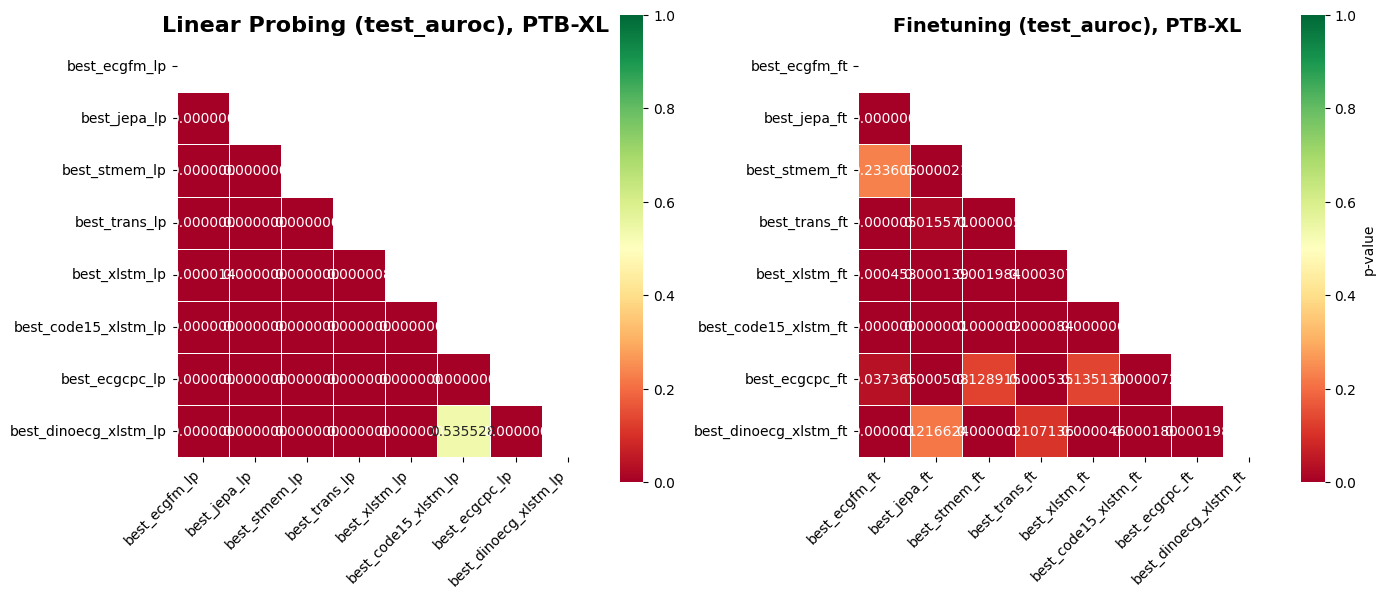

In [9]:
plot_pvalues_heatmap(
    pd.DataFrame(records_ptb_xl).set_index("group"), 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metric="test_auroc", 
    title="PTB-XL", 
    figsize=(14, 6)
)

# CPSC 2018

In [10]:
records_cpsc = get_records("train-cpsc2018-multilabel", metrics=["test_acc", "test_f1", "test_auroc", "test_auprc", '_runtime'], regex="^best_")
formatted_df_cpsc = get_dataframe_from_records(records_cpsc)

100%|██████████| 85/85 [00:43<00:00,  1.96it/s]


## Finetuning

In [11]:
cpsc_ft = formatted_df_cpsc[formatted_df_cpsc.index.isin(ft_groups)]

styled_df_ft = cpsc_ft.style.apply(style_mean_column)
styled_df_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_code15_xlstm_ft,0.967 ± 0.001,0.817 ± 0.011,0.977 ± 0.003,0.878 ± 0.009,753.797 ± 5.855
best_dinoecg_xlstm_ft,0.970 ± 0.001,0.844 ± 0.002,0.981 ± 0.001,0.897 ± 0.003,650.663 ± 55.729
best_ecgcpc_ft,0.960 ± 0.001,0.798 ± 0.009,0.966 ± 0.002,0.840 ± 0.005,683.738 ± 11.121
best_ecgfm_ft,0.964 ± 0.000,0.794 ± 0.005,0.969 ± 0.001,0.854 ± 0.002,406.169 ± 10.301
best_jepa_ft,0.942 ± 0.003,0.749 ± 0.009,0.965 ± 0.001,0.842 ± 0.003,1705.833 ± 44.027
best_stmem_ft,0.963 ± 0.001,0.789 ± 0.012,0.958 ± 0.003,0.835 ± 0.011,1314.123 ± 14.290
best_trans_ft,0.961 ± 0.001,0.796 ± 0.008,0.965 ± 0.003,0.853 ± 0.006,212.527 ± 12.297
best_xlstm_ft,0.968 ± 0.001,0.822 ± 0.008,0.981 ± 0.001,0.888 ± 0.003,731.973 ± 30.716


## Linear probing

In [12]:
formatted_df_cpsc_lp = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_lp")]
styled_df_lp = formatted_df_cpsc_lp.style.apply(style_mean_column)
styled_df_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_code15_xlstm_lp,0.958 ± 0.001,0.757 ± 0.010,0.964 ± 0.001,0.842 ± 0.003,390.338 ± 11.351
best_dinoecg_xlstm_lp,0.958 ± 0.001,0.772 ± 0.003,0.966 ± 0.001,0.857 ± 0.004,327.653 ± 2.345
best_ecgcpc_lp,0.954 ± 0.000,0.743 ± 0.007,0.951 ± 0.001,0.796 ± 0.002,337.651 ± 6.019
best_ecgfm_lp,0.958 ± 0.000,0.750 ± 0.007,0.962 ± 0.000,0.830 ± 0.001,252.192 ± 4.276
best_jepa_lp,0.889 ± 0.002,0.613 ± 0.003,0.961 ± 0.000,0.830 ± 0.001,746.866 ± 3.697
best_stmem_lp,0.935 ± 0.000,0.455 ± 0.005,0.922 ± 0.001,0.722 ± 0.004,604.956 ± 2.832
best_trans_lp,0.953 ± 0.001,0.733 ± 0.008,0.951 ± 0.001,0.787 ± 0.008,248.633 ± 32.202
best_xlstm_lp,0.961 ± 0.002,0.781 ± 0.011,0.968 ± 0.001,0.861 ± 0.004,461.689 ± 6.262


## latex table

In [13]:
print(df_to_latex_table_single_task(
    records_cpsc, rename_map_latex, 
    groups_ft= ft_groups_table,
    groups_lp= lp_groups,
    metrics=[
        ("test_acc", "Accuracy", 'max'),
        ("test_f1", "F1 Score", 'max'),
        ("test_auroc", "AUROC", 'max'),
        ("test_auprc", "AUPRC", 'max'),
    ],
    supervised_baselines=[],
    task_name='CPSC2018',
    caption= r"\textbf{CPSC2018.} Individual model performance for the CPSC2018 task. Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:cpsc2018_results'
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|cccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{4}{c}{\textbf{CPSC2018}} \\
    & Accuracy& F1 Score& AUROC& AUPRC \\
    \midrule
    \multicolumn{5}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.952 $\pm$ 0.001 & 0.719 $\pm$ 0.008 & 0.951 $\pm$ 0.002 & 0.813 $\pm$ 0.006 \\
    \midrule
    \multicolumn{5}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.935 $\pm$ 0.000 & 0.455 $\pm$ 0.005 & 0.922 $\pm$ 0.001 & 0.722 $\pm$ 0.004 \\
   ECG-JEPA & 0.889 $\pm$ 0.002 & 0.613 $\pm$ 0.003 & 0.961 $\pm$ 0.000 & 0.830 $\pm$ 0.001 \\
   ECGFounder & \underline{0.958 $\pm$ 0.000} & 0.750 $\pm$ 0.007 & 0.962 $\pm$ 0.000 & 0.830 $\pm$ 0.001 \\
   ECG-CPC & 0.954 $\pm$ 0.000 & 0.743 $\pm$ 0.007 & 0.951 $\pm$ 0.001 & 0.796 $\pm$ 0.002 \\
   \textbf{SimDINOv2 Transf.} & 0.953 $\pm$ 0.001 & 0.733 $\pm$ 0.008 & 0.951 $\pm$ 0.001 & 0.787 $\pm$ 0.008 \\
   \textbf{xECG (red. pre

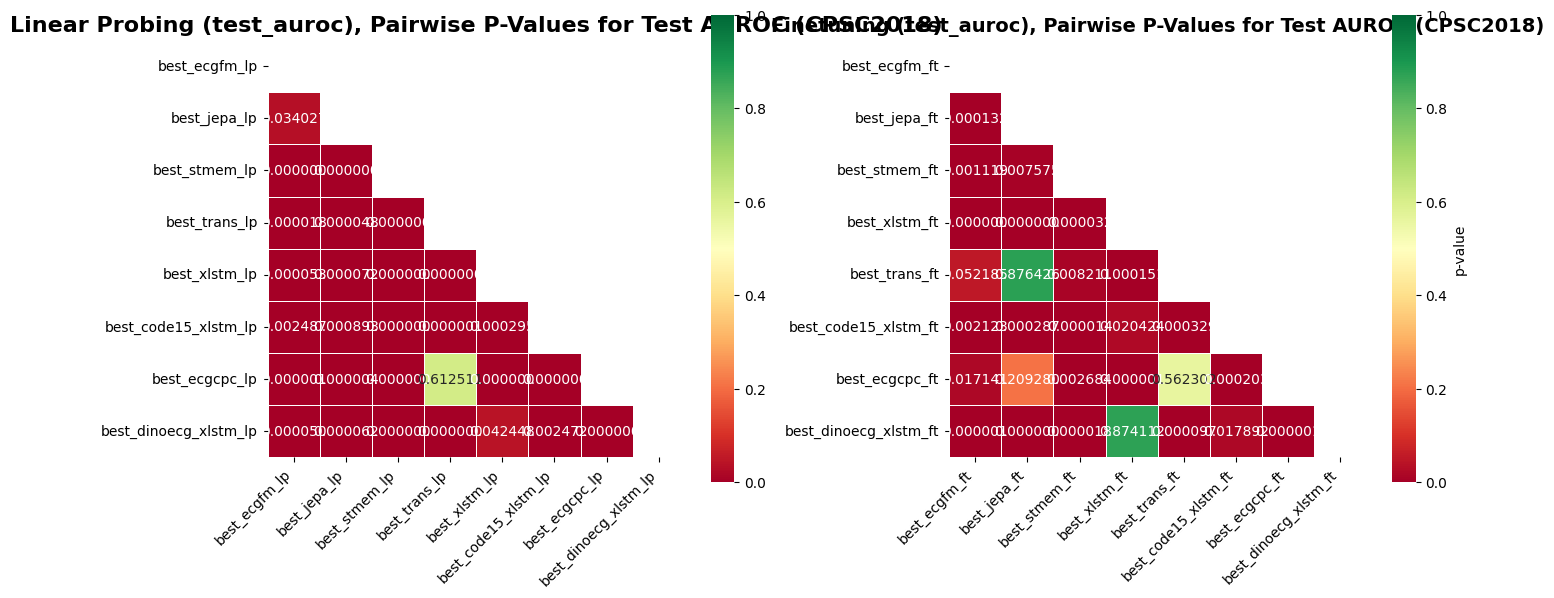

In [14]:
# plot the p-values heatmap for cpsc
plot_pvalues_heatmap(
    pd.DataFrame(records_cpsc).set_index("group"), 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metric="test_auroc", 
    title="Pairwise P-Values for Test AUROC (CPSC2018)", 
    figsize=(14, 6)
)

# MIT-BIH classification

In [15]:
records_mit_cls = get_records("train-mitbih-5", metrics=["test_acc", "test_sensitivity/mean", "test_ppv/mean", "test_specificity/mean", "test_f1/mean", '_runtime'], regex="^best_")
formatted_df_mit_cls = get_dataframe_from_records(records_mit_cls)

100%|██████████| 99/99 [00:40<00:00,  2.47it/s]


## Finetuning

In [16]:
mit_ft = formatted_df_mit_cls[formatted_df_mit_cls.index.isin(ft_groups)]

styled_df_mit_ft = mit_ft.style.apply(style_mean_column)
styled_df_mit_ft

,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std),_runtime (mean ± std)
,,,,,,
group,,,,,,
best_code15_xlstm_ft,0.916 ± 0.008,0.523 ± 0.020,0.480 ± 0.019,0.940 ± 0.003,0.481 ± 0.017,1045.752 ± 3.770
best_dinoecg_xlstm_ft,0.960 ± 0.001,0.545 ± 0.003,0.674 ± 0.005,0.946 ± 0.001,0.588 ± 0.002,668.750 ± 16.745
best_ecgcpc_ft,0.909 ± 0.009,0.574 ± 0.012,0.471 ± 0.005,0.931 ± 0.002,0.466 ± 0.006,748.575 ± 34.096
best_ecgfm_ft,0.863 ± 0.008,0.211 ± 0.002,0.207 ± 0.002,0.809 ± 0.002,0.207 ± 0.002,328.807 ± 9.122
best_jepa_ft,0.954 ± 0.001,0.557 ± 0.006,0.629 ± 0.007,0.951 ± 0.001,0.583 ± 0.007,2252.044 ± 15.465
best_stmem_ft,0.967 ± 0.002,0.625 ± 0.007,0.671 ± 0.013,0.965 ± 0.003,0.644 ± 0.007,1783.386 ± 26.314
best_trans_ft,0.896 ± 0.008,0.475 ± 0.002,0.457 ± 0.005,0.905 ± 0.001,0.425 ± 0.006,216.098 ± 25.243
best_xlstm_ft,0.976 ± 0.007,0.651 ± 0.035,0.721 ± 0.019,0.973 ± 0.010,0.677 ± 0.025,708.598 ± 34.795


## Linear probing

In [17]:
formatted_mit_lp = formatted_df_mit_cls[formatted_df_mit_cls.index.str.endswith("_lp")]
styled_df_mit_lp = formatted_mit_lp.style.apply(style_mean_column)
styled_df_mit_lp


,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std),_runtime (mean ± std)
,,,,,,
group,,,,,,
best_code15_xlstm_lp,0.913 ± 0.009,0.498 ± 0.005,0.448 ± 0.017,0.930 ± 0.002,0.448 ± 0.010,382.368 ± 5.659
best_dinoecg_xlstm_lp,0.958 ± 0.001,0.526 ± 0.015,0.630 ± 0.018,0.945 ± 0.002,0.560 ± 0.012,339.706 ± 2.619
best_ecgcpc_lp,0.895 ± 0.013,0.422 ± 0.019,0.376 ± 0.018,0.906 ± 0.004,0.381 ± 0.012,272.970 ± 25.108
best_ecgfm_lp,0.865 ± 0.012,0.210 ± 0.004,0.209 ± 0.004,0.808 ± 0.003,0.206 ± 0.005,324.685 ± 14.280
best_jepa_lp,0.946 ± 0.000,0.470 ± 0.003,0.574 ± 0.003,0.933 ± 0.000,0.496 ± 0.003,891.782 ± 8.916
best_stmem_lp,0.937 ± 0.003,0.424 ± 0.027,0.507 ± 0.035,0.920 ± 0.003,0.436 ± 0.036,847.626 ± 47.748
best_trans_lp,0.931 ± 0.000,0.381 ± 0.004,0.549 ± 0.012,0.924 ± 0.004,0.395 ± 0.005,108.508 ± 2.805
best_xlstm_lp,0.972 ± 0.002,0.686 ± 0.021,0.669 ± 0.014,0.976 ± 0.003,0.674 ± 0.013,326.174 ± 3.404


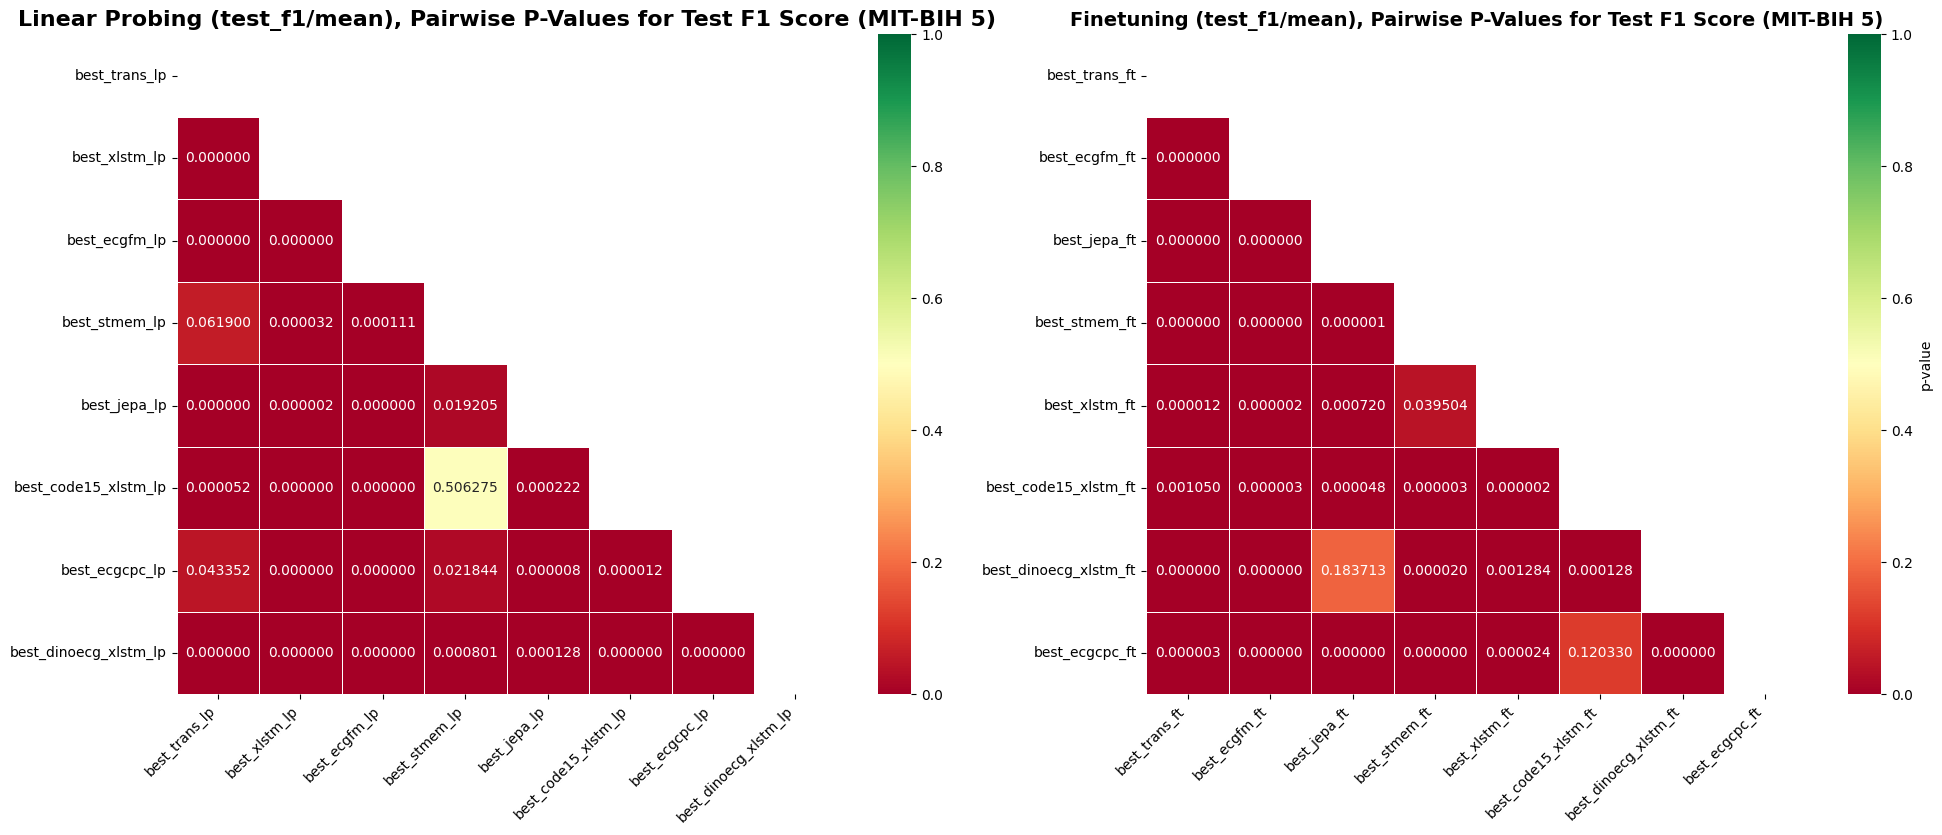

In [18]:
# plot p-values 
plot_pvalues_heatmap(
    pd.DataFrame(records_mit_cls).set_index("group"), 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metric="test_f1/mean", 
    title="Pairwise P-Values for Test F1 Score (MIT-BIH 5)", 
    figsize=(20, 8)
)

## latex table

In [19]:
print(df_to_latex_table_single_task(
    records_mit_cls, rename_map_latex, 
    groups_lp= lp_groups,
    groups_ft= ft_groups_table,
    metrics=[
        ("test_acc", "Accuracy", "max"),
        ("test_sensitivity/mean", "Sensitivity", "max"),
        ("test_ppv/mean", "PPV", "max"),
        ("test_specificity/mean", "Specificity", "max"),
        ("test_f1/mean", "F1 Score", "max")
    ],
    supervised_baselines=[
        r"     Xia et al.\cite{xia2023transformer} & 0.976 & 0.510 & 0.563 & 0.930 & 0.529 \\",
        r"     Sellami et al. \cite{sellami2019robust} & 0.953 & 0.690 & 0.555 & 0.960 & 0.558 \\",
        r"     Li et al.\cite{li2022inter} & 0.889 & 0.521 & 0.568 & 0.947 & 0.533 \\",
        r"     Marinho et al. \cite{marinho2019novel} & 0.943 & 0.478 & - & 0.914 & - \\",
        r"     Li et al. \cite{li2019automated} & 0.914 & 0.616 & 0.489 & 0.950 & 0.539 \\"
    ],
    task_name='MIT-BIH',
    caption= r"\textbf{MIT-BIH.} Individual model performance for the MIT-BIH task. Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:mitbih_results'
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|ccccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{5}{c}{\textbf{MIT-BIH}} \\
    & Accuracy& Sensitivity& PPV& Specificity& F1 Score \\
    \midrule
    \multicolumn{6}{c}{\textbf{Supervised}} \\
    \midrule
     Xia et al.\cite{xia2023transformer} & 0.976 & 0.510 & 0.563 & 0.930 & 0.529 \\
     Sellami et al. \cite{sellami2019robust} & 0.953 & 0.690 & 0.555 & 0.960 & 0.558 \\
     Li et al.\cite{li2022inter} & 0.889 & 0.521 & 0.568 & 0.947 & 0.533 \\
     Marinho et al. \cite{marinho2019novel} & 0.943 & 0.478 & - & 0.914 & - \\
     Li et al. \cite{li2019automated} & 0.914 & 0.616 & 0.489 & 0.950 & 0.539 \\
   \textbf{Supervised xLSTM} & 0.896 $\pm$ 0.013 & 0.448 $\pm$ 0.028 & 0.416 $\pm$ 0.020 & 0.910 $\pm$ 0.004 & 0.402 $\pm$ 0.014 \\
    \midrule
    \multicolumn{6}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.937 $\pm$ 0.003 & 0.424 $\pm$ 0.027 & 0.507 $\pm$ 0.035 & 0.920 $\pm$ 

# MIT-BIH r-peaks

In [20]:
records_mit_r_peaks = get_records("train-mitbih-r_peaks", metrics=["test_f1_150", "test_f1_20", "test_f1_10",  "test_f1_5", "test_avg_distance_rp",  "test_avg_distance", '_runtime'], regex="^best_")
formatted_df_mit_r_peaks = get_dataframe_from_records(records_mit_r_peaks)

100%|██████████| 85/85 [00:43<00:00,  1.95it/s]


## Fine-tuning

In [21]:
mit_r_peaks_ft = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.isin(ft_groups)]
# add sup rows to ft
styled_df_mit_r_peaks_ft = mit_r_peaks_ft.style.apply(style_mean_column)
styled_df_mit_r_peaks_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_f1_10 (mean ± std),test_f1_5 (mean ± std),test_avg_distance_rp (mean ± std),test_avg_distance (mean ± std),_runtime (mean ± std)
,,,,,,,
group,,,,,,,
best_code15_xlstm_ft,0.986 ± 0.001,0.895 ± 0.003,0.708 ± 0.002,0.366 ± 0.001,7.798 ± 0.925,12.074 ± 1.110,258.800 ± 6.496
best_dinoecg_xlstm_ft,0.992 ± 0.002,0.913 ± 0.004,0.725 ± 0.004,0.372 ± 0.003,4.226 ± 0.211,9.171 ± 1.192,260.600 ± 10.968
best_ecgcpc_ft,0.922 ± 0.020,0.879 ± 0.020,0.747 ± 0.042,0.504 ± 0.026,194.523 ± 74.277,5.344 ± 0.662,449.800 ± 3.633
best_ecgfm_ft,0.149 ± 0.003,0.037 ± 0.000,0.020 ± 0.000,0.010 ± 0.000,3182.132 ± 14.397,222.828 ± 0.806,283.000 ± 5.431
best_jepa_ft,0.995 ± 0.001,0.910 ± 0.004,0.875 ± 0.004,0.700 ± 0.004,4.238 ± 0.186,5.767 ± 0.264,1068.200 ± 13.442
best_stmem_ft,0.994 ± 0.001,0.938 ± 0.001,0.930 ± 0.002,0.784 ± 0.004,4.214 ± 0.380,6.841 ± 0.687,918.000 ± 39.414
best_trans_ft,0.986 ± 0.003,0.907 ± 0.002,0.733 ± 0.002,0.380 ± 0.001,6.508 ± 0.768,11.372 ± 0.995,291.800 ± 12.317
best_xlstm_ft,0.995 ± 0.001,0.924 ± 0.002,0.739 ± 0.004,0.379 ± 0.002,4.089 ± 0.142,7.854 ± 0.760,269.000 ± 31.385


## Linear probing

In [22]:
formatted_df_mit_r_peaks_lp = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.str.endswith("_lp")]
styled_df_mit_r_peaks_lp = formatted_df_mit_r_peaks_lp.style.apply(style_mean_column)
styled_df_mit_r_peaks_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_f1_10 (mean ± std),test_f1_5 (mean ± std),test_avg_distance_rp (mean ± std),test_avg_distance (mean ± std),_runtime (mean ± std)
,,,,,,,
group,,,,,,,
best_code15_xlstm_lp,0.969 ± 0.000,0.726 ± 0.003,0.545 ± 0.002,0.281 ± 0.001,36.018 ± 2.335,10.788 ± 0.328,194.200 ± 48.443
best_dinoecg_xlstm_lp,0.969 ± 0.001,0.612 ± 0.004,0.465 ± 0.003,0.239 ± 0.001,10.449 ± 0.418,14.180 ± 0.073,184.000 ± 23.885
best_ecgcpc_lp,0.664 ± 0.027,0.475 ± 0.012,0.381 ± 0.007,0.240 ± 0.004,937.373 ± 81.185,19.817 ± 1.162,232.000 ± 3.937
best_ecgfm_lp,0.146 ± 0.003,0.037 ± 0.000,0.020 ± 0.000,0.010 ± 0.000,3177.251 ± 11.742,223.811 ± 2.254,276.600 ± 21.431
best_jepa_lp,0.976 ± 0.000,0.444 ± 0.002,0.309 ± 0.001,0.251 ± 0.001,8.037 ± 0.259,12.455 ± 0.039,521.400 ± 11.393
best_stmem_lp,0.971 ± 0.000,0.566 ± 0.003,0.390 ± 0.002,0.297 ± 0.001,4.171 ± 0.140,13.942 ± 0.230,494.200 ± 53.148
best_trans_lp,0.749 ± 0.026,0.504 ± 0.010,0.393 ± 0.009,0.204 ± 0.005,246.986 ± 53.340,36.721 ± 2.740,204.600 ± 48.952
best_xlstm_lp,0.946 ± 0.003,0.591 ± 0.007,0.455 ± 0.005,0.234 ± 0.002,17.031 ± 0.903,16.912 ± 0.397,190.400 ± 4.336


## latex table

In [23]:
print(df_to_latex_table_single_task(
    records_mit_r_peaks, rename_map_latex, 
    groups_lp= lp_groups,
    groups_ft= ft_groups_table,
    metrics=[
        ("test_f1_150", "F1 Score (150ms)", "max"),
        ("test_f1_20", "F1 Score (20ms)", "max"),
        ("test_avg_distance", "Avg. Distance (Pred.)", "min"),
        ("test_avg_distance_rp", "Avg. Distance (True)", 'min')
    ],
    task_name='R-peak',
    caption= r"\textbf{R-peak.} Individual model performance for the R-peak detection task (MIT-BIH). " \
    "Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  " \
    "Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. " \
    "Bold results indicate best performance across models and underlined indicates 2nd best. " \
    "Average Dist. (Pred.) is the average distance between every predicted R-Peak to the closest ground truth. " \
    "Average Distance (True) is the average distance between every annotated R-Peak to the closest prediction.",
    table_id='tab:mitbih_r_peak_results'
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|cccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{4}{c}{\textbf{R-peak}} \\
    & F1 Score (150ms)& F1 Score (20ms)& Avg. Distance (Pred.)& Avg. Distance (True) \\
    \midrule
    \multicolumn{5}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.980 $\pm$ 0.004 & 0.888 $\pm$ 0.008 & 11.923 $\pm$ 1.163 & 6.745 $\pm$ 0.564 \\
    \midrule
    \multicolumn{5}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & \underline{0.971 $\pm$ 0.000} & 0.566 $\pm$ 0.003 & 13.942 $\pm$ 0.230 & \textbf{4.171 $\pm$ 0.140} \\
   ECG-JEPA & \textbf{0.976 $\pm$ 0.000} & 0.444 $\pm$ 0.002 & \underline{12.455 $\pm$ 0.039} & \underline{8.037 $\pm$ 0.259} \\
   ECGFounder & 0.146 $\pm$ 0.003 & 0.037 $\pm$ 0.000 & 223.811 $\pm$ 2.254 & 3177.251 $\pm$ 11.742 \\
   ECG-CPC & 0.664 $\pm$ 0.027 & 0.475 $\pm$ 0.012 & 19.817 $\pm$ 1.162 & 937.373 $\pm$ 81.185 \\
   \textbf{SimDINOv2 Transf.} & 0.749 $

# Exercise high intensity r peaks

In [24]:
records_exe_r = get_records("train-exercise-r-peak", metrics=["test_f1_150", "test_f1_20", "test_avg_distance", "test_avg_distance_rp", '_runtime'], regex="^best_")
formatted_df_exe_r = get_dataframe_from_records(records_exe_r)

100%|██████████| 85/85 [00:41<00:00,  2.04it/s]


In [25]:
# print all groups
print("Groups in formatted_df_exe_r:")
print(formatted_df_exe_r.index.tolist())

Groups in formatted_df_exe_r:
['best_code15_xlstm_ft', 'best_code15_xlstm_lp', 'best_dinoecg_xlstm_ft', 'best_dinoecg_xlstm_lp', 'best_ecgcpc_ft', 'best_ecgcpc_lp', 'best_ecgfm_ft', 'best_ecgfm_lp', 'best_jepa_ft', 'best_jepa_lp', 'best_stmem_ft', 'best_stmem_lp', 'best_trans_ft', 'best_trans_lp', 'best_xlstm_ft', 'best_xlstm_lp', 'best_xlstm_sup']


## Finetuning

In [26]:
exe_r_ft = formatted_df_exe_r[formatted_df_exe_r.index.isin(ft_groups)]
# add sup rows to ft
styled_df_exe_r_ft = exe_r_ft.style.apply(style_mean_column)
styled_df_exe_r_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_distance (mean ± std),test_avg_distance_rp (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_code15_xlstm_ft,0.992 ± 0.001,0.962 ± 0.003,4.449 ± 0.161,6.750 ± 0.552,176.800 ± 16.006
best_dinoecg_xlstm_ft,0.995 ± 0.001,0.961 ± 0.002,4.568 ± 0.104,4.855 ± 0.264,197.000 ± 26.391
best_ecgcpc_ft,0.989 ± 0.003,0.967 ± 0.006,4.601 ± 0.544,3.553 ± 0.682,106.000 ± 8.602
best_ecgfm_ft,0.415 ± 0.012,0.082 ± 0.001,88.874 ± 0.405,42.974 ± 3.284,109.200 ± 7.014
best_jepa_ft,0.974 ± 0.003,0.866 ± 0.015,6.034 ± 0.315,4.365 ± 0.647,283.000 ± 33.377
best_stmem_ft,0.986 ± 0.002,0.984 ± 0.002,2.940 ± 0.267,8.410 ± 1.932,263.800 ± 25.636
best_trans_ft,0.815 ± 0.014,0.618 ± 0.014,27.582 ± 2.450,7.912 ± 0.356,169.400 ± 8.385
best_xlstm_ft,0.995 ± 0.000,0.965 ± 0.003,4.433 ± 0.165,4.941 ± 0.540,170.200 ± 21.288


## Linear probing

In [27]:
formatted_exe_r_lp = formatted_df_exe_r[formatted_df_exe_r.index.str.endswith("_lp")]
styled_df_exe_r_lp = formatted_exe_r_lp.style.apply(style_mean_column)
styled_df_exe_r_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_distance (mean ± std),test_avg_distance_rp (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_code15_xlstm_lp,0.964 ± 0.007,0.936 ± 0.004,4.332 ± 0.179,27.451 ± 4.791,121.000 ± 25.593
best_dinoecg_xlstm_lp,0.932 ± 0.003,0.872 ± 0.002,4.828 ± 0.031,50.243 ± 2.245,107.200 ± 3.962
best_ecgcpc_lp,0.869 ± 0.031,0.861 ± 0.030,3.632 ± 0.197,109.644 ± 42.182,114.000 ± 26.029
best_ecgfm_lp,0.412 ± 0.013,0.083 ± 0.002,88.553 ± 0.702,42.628 ± 3.741,164.800 ± 60.969
best_jepa_lp,0.921 ± 0.002,0.526 ± 0.007,12.312 ± 0.193,44.253 ± 1.718,258.400 ± 47.162
best_stmem_lp,0.795 ± 0.020,0.632 ± 0.004,15.638 ± 3.621,130.281 ± 21.707,205.400 ± 28.466
best_trans_lp,0.618 ± 0.006,0.322 ± 0.003,46.634 ± 0.575,16.866 ± 0.387,96.400 ± 6.693
best_xlstm_lp,0.950 ± 0.003,0.892 ± 0.001,4.729 ± 0.103,37.568 ± 2.490,121.200 ± 23.658


## latex table

In [28]:
print(df_to_latex_table_single_task(
    records_exe_r, rename_map_latex, 
    groups_lp= lp_groups,
    groups_ft= ft_groups_table,
    metrics=[
        ("test_f1_150", "F1 Score (150ms)", "max"),
        ("test_f1_20", "F1 Score (20ms)", "max"),
        ("test_avg_distance", "Avg. Distance (Pred.)", "min"),
        ("test_avg_distance_rp", "Avg. Distance (True)", 'min')
        # ("test_avg_total_distance", "Avg. Distance", "min"),
    ],
    task_name='Exercise R-peak',
    caption= r"\textbf{Exercise R-peak.} Individual model performance for the Exercise task (R-peak detection in Exercise-ECG). " \
    "Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  " \
    "Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. " \
    "Bold results indicate best performance across models and underlined indicates 2nd best. " \
    "Average Dist. (Pred.) is the average distance between every predicted R-Peak to the closest ground truth. " \
    "Average Distance (True) is the average distance between every annotated R-Peak to the closest prediction. ",
    table_id='tab:exercise_r_peak_results'
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|cccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{4}{c}{\textbf{Exercise R-peak}} \\
    & F1 Score (150ms)& F1 Score (20ms)& Avg. Distance (Pred.)& Avg. Distance (True) \\
    \midrule
    \multicolumn{5}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.990 $\pm$ 0.002 & 0.966 $\pm$ 0.002 & 4.722 $\pm$ 0.149 & 7.286 $\pm$ 0.841 \\
    \midrule
    \multicolumn{5}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.795 $\pm$ 0.020 & 0.632 $\pm$ 0.004 & 15.638 $\pm$ 3.621 & 130.281 $\pm$ 21.707 \\
   ECG-JEPA & 0.921 $\pm$ 0.002 & 0.526 $\pm$ 0.007 & 12.312 $\pm$ 0.193 & 44.253 $\pm$ 1.718 \\
   ECGFounder & 0.412 $\pm$ 0.013 & 0.083 $\pm$ 0.002 & 88.553 $\pm$ 0.702 & 42.628 $\pm$ 3.741 \\
   ECG-CPC & 0.869 $\pm$ 0.031 & \underline{0.861 $\pm$ 0.030} & \textbf{3.632 $\pm$ 0.197} & 109.644 $\pm$ 42.182 \\
   \textbf{SimDINOv2 Transf.} & 0.618 $\pm$ 0.006 & 0.322 $\pm$ 0

In [29]:
print(df_to_latex_table_2_task(
    task1_records=records_mit_r_peaks,
    task2_records=records_exe_r,
    name_map=rename_map_latex,
    metrics=[
        ("test_f1_150", "F1(150)ms", "max"),
        ("test_f1_20", "F1(20)ms", "max"),
        # ("test_avg_total_distance", "Avg. Distance", "min"),
    ],
    supervised_baselines=[],
    task1_name='MIT-BIH',
    task2_name="Intense Exercise DB",
    caption='Performance comparison on R-peak detection task on MIT-BIH and Intense Exercise datasets under linear evaluation and fine-tuning',
    table_id='r_peaks_results',
))

\begin{table*}[h!]
\resizebox{\textwidth}{!}{
    \begin{tabular}{ll|cc|cc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multirow{2}{*}{} & \multicolumn{2}{c|}{\textbf{MIT-BIH}} & \multicolumn{2}{c}{\textbf{Intense Exercise DB}} \\
    & & F1(150)ms& F1(20)ms \\
    \midrule
    \multicolumn{6}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.980 $\pm$ 0.004 & 0.888 $\pm$ 0.008 & 0.990 $\pm$ 0.002 & 0.966 $\pm$ 0.002 \\
    \midrule
    \multicolumn{6}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & \underline{0.971 $\pm$ 0.000} & 0.566 $\pm$ 0.003 & 0.795 $\pm$ 0.020 & 0.632 $\pm$ 0.004 \\
   ECG-JEPA & \textbf{0.976 $\pm$ 0.000} & 0.444 $\pm$ 0.002 & 0.921 $\pm$ 0.002 & 0.526 $\pm$ 0.007 \\
   ECGFounder & 0.146 $\pm$ 0.003 & 0.037 $\pm$ 0.000 & 0.412 $\pm$ 0.013 & 0.083 $\pm$ 0.002 \\
   \textbf{SimDINOv2 Transf.} & 0.749 $\pm$ 0.026 & 0.504 $\pm$ 0.010 & 0.618 $\pm$ 0.006 & 0.322 $\pm$ 0.003 \\
   \textbf{xECG (red. pretr.)} & 0.969 $\pm$ 0.

# Sleep apnea

In [30]:
records_sleep_apnea_orig = get_records("train-sleep-apnea_bis", metrics=["test_acc", "test_f1", "test_auc", '_runtime'], regex="^best_")
# rename the columns to match other datasets

print(records_sleep_apnea_orig[-1])

100%|██████████| 235/235 [02:18<00:00,  1.70it/s]

{'group': 'best_ecgcpc_ft_9m', 'test_acc': 0.8968576192855835, 'test_f1': 0.8616748452186584, 'test_auc': 0.9579458236694336, '_runtime': 81581.768860292}


In [31]:
# rename best_code_15_xlstm_ft_3m to best_code15_xlstm_ft
for record in records_sleep_apnea_orig:
    if record['group'] == 'best_code_15_xlstm_ft_3m':
        record['group'] = 'best_code15_xlstm_ft_3m'


In [32]:
ft_groups_sa = ['best_stmem_ft_10s', 'best_jepa_ft_1m', 'best_ecgfm_ft_9m', 'best_trans_ft_9m', 'best_xlstm_ft_5m', 'best_xlstm_sup', 'best_code15_xlstm_ft_3m', 'best_dinoecg_xlstm_ft_3m', 'best_ecgcpc_ft_9m']
lp_groups_sa = ['best_stmem_lp', 'best_jepa_lp', 'best_ecgfm_lp', 'best_trans_lp', 'best_xlstm_lp', 'best_code15_xlstm_lp', 'best_dinoecg_xlstm_lp', 'best_ecgcpc_lp']

# keep only idxs in ft_groups_sa
records_sleep_apnea = [record.copy() for record in records_sleep_apnea_orig if record['group'] in ft_groups_sa + lp_groups_sa]
print([record['group'] for record in records_sleep_apnea])
# rename the groups to remove the time suffix

for record in records_sleep_apnea:
    if not record['group'].endswith('sup') and not record['group'].endswith('lp'):
        record['group'] = record['group'].rsplit('_', 1)[0]

# print(records_sleep_apnea)
formatted_df_sleep_apnea = get_dataframe_from_records(records_sleep_apnea)
# print(formatted_df_sleep_apnea)
print(formatted_df_sleep_apnea.index.tolist())

['best_xlstm_ft_5m', 'best_ecgfm_ft_9m', 'best_trans_ft_9m', 'best_jepa_ft_1m', 'best_xlstm_ft_5m', 'best_xlstm_ft_5m', 'best_xlstm_ft_5m', 'best_xlstm_ft_5m', 'best_trans_ft_9m', 'best_trans_ft_9m', 'best_trans_ft_9m', 'best_trans_ft_9m', 'best_ecgfm_ft_9m', 'best_ecgfm_ft_9m', 'best_ecgfm_ft_9m', 'best_ecgfm_ft_9m', 'best_jepa_ft_1m', 'best_jepa_ft_1m', 'best_jepa_ft_1m', 'best_jepa_ft_1m', 'best_stmem_ft_10s', 'best_stmem_ft_10s', 'best_stmem_ft_10s', 'best_stmem_ft_10s', 'best_stmem_ft_10s', 'best_xlstm_lp', 'best_xlstm_lp', 'best_ecgfm_lp', 'best_stmem_lp', 'best_jepa_lp', 'best_xlstm_lp', 'best_xlstm_lp', 'best_xlstm_lp', 'best_stmem_lp', 'best_stmem_lp', 'best_stmem_lp', 'best_stmem_lp', 'best_trans_lp', 'best_trans_lp', 'best_trans_lp', 'best_trans_lp', 'best_trans_lp', 'best_ecgfm_lp', 'best_ecgfm_lp', 'best_ecgfm_lp', 'best_ecgfm_lp', 'best_jepa_lp', 'best_jepa_lp', 'best_jepa_lp', 'best_jepa_lp', 'best_xlstm_sup', 'best_xlstm_sup', 'best_xlstm_sup', 'best_xlstm_sup', 'best_x

## Fine-tuning

In [33]:
sleep_ft = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.isin(ft_groups)]
# add sup rows to ft
styled_df_sleep_ft = sleep_ft.style.apply(style_mean_column)
styled_df_sleep_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,0.797 ± 0.015,0.712 ± 0.030,0.875 ± 0.007,7760.303 ± 18.661
best_dinoecg_xlstm_ft,0.770 ± 0.047,0.665 ± 0.129,0.849 ± 0.037,5507.909 ± 42.209
best_ecgcpc_ft,0.864 ± 0.024,0.808 ± 0.044,0.935 ± 0.024,81708.839 ± 341.429
best_ecgfm_ft,0.726 ± 0.048,0.647 ± 0.035,0.778 ± 0.072,25151.781 ± 199.422
best_jepa_ft,0.643 ± 0.016,0.461 ± 0.071,0.690 ± 0.028,47518.183 ± 356.468
best_stmem_ft,0.587 ± 0.053,0.581 ± 0.061,0.700 ± 0.030,9480.466 ± 59.347
best_trans_ft,0.615 ± 0.053,0.565 ± 0.035,0.681 ± 0.044,23044.163 ± 28.958
best_xlstm_ft,0.854 ± 0.012,0.807 ± 0.025,0.928 ± 0.008,7756.403 ± 37.884


## Linear probing

In [34]:
formatted_sleep_lp = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.str.endswith("_lp")]
styled_df_sleep_lp = formatted_sleep_lp.style.apply(style_mean_column)
styled_df_sleep_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,0.734 ± 0.031,0.641 ± 0.033,0.796 ± 0.034,3617.387 ± 9.267
best_dinoecg_xlstm_lp,0.792 ± 0.021,0.707 ± 0.034,0.861 ± 0.034,2052.216 ± 20.171
best_ecgcpc_lp,0.653 ± 0.069,0.417 ± 0.227,0.734 ± 0.066,15377.524 ± 14.367
best_ecgfm_lp,0.727 ± 0.059,0.666 ± 0.065,0.777 ± 0.071,6870.415 ± 225.842
best_jepa_lp,0.629 ± 0.041,0.464 ± 0.109,0.667 ± 0.051,19997.856 ± 175.868
best_stmem_lp,0.559 ± 0.020,0.554 ± 0.020,0.599 ± 0.032,3977.423 ± 16.073
best_trans_lp,0.668 ± 0.037,0.646 ± 0.043,0.644 ± 0.042,412.091 ± 10.735
best_xlstm_lp,0.812 ± 0.016,0.744 ± 0.032,0.879 ± 0.021,3660.922 ± 14.977


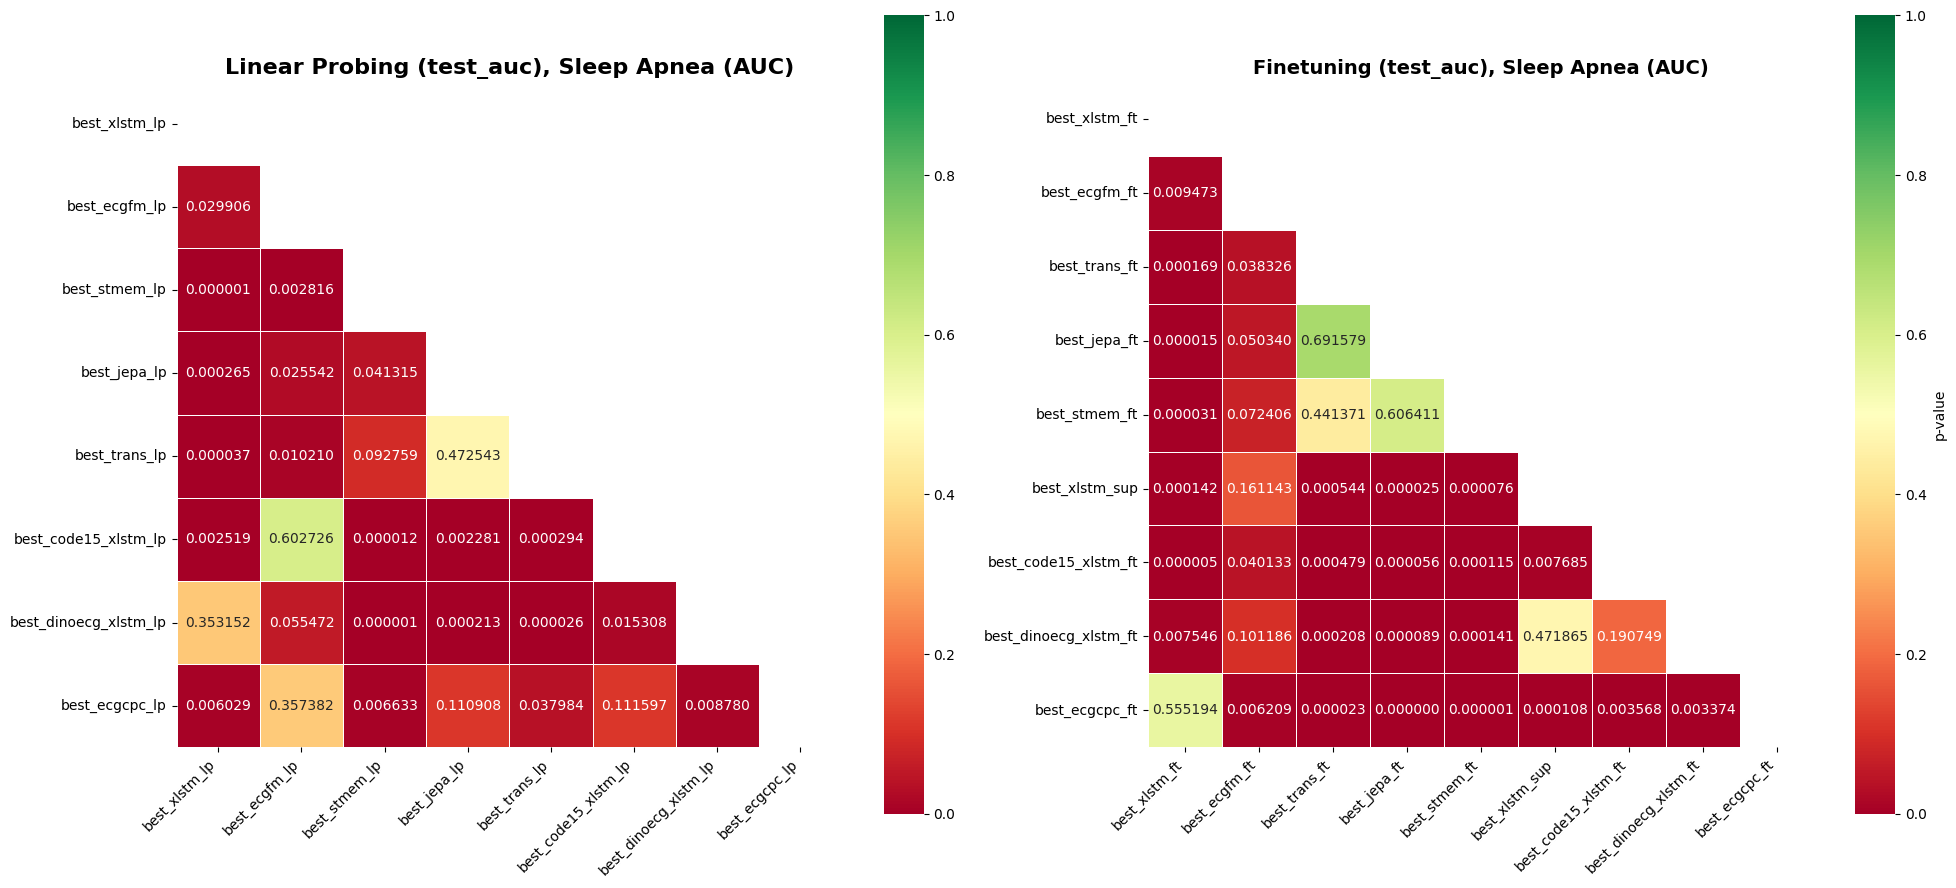

In [35]:
# p values heatmap for sleep apnea
plot_pvalues_heatmap(
    pd.DataFrame(records_sleep_apnea).set_index("group"),
    groups_ft=ft_groups, 
    groups_lp=lp_groups_sa,
    metric="test_auc", 
    title="Sleep Apnea (AUC)", 
    figsize=(20, 9)
)

## latex table

In [36]:

print(df_to_latex_table_single_task(
    records_sleep_apnea, rename_map_latex, 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metrics=[
        ("test_acc", "Accuracy", "max"),
        ("test_f1", "F1 Score", "max"),
        ('test_auc', "AUROC", "max")
    ],
    supervised_baselines=[
        r"     Chang et al.\cite{chang2020sleep} &  0.920 &  0.879 &  0.865 \\",
        r"     Shen et al. \cite{shen2021multiscale} &  0.894 & 0.866 & 0.946 \\",
        r"     Bernardini et al. \cite{Bernardini2021AIOSASleepApnea} & 0.936 &  0.916 & 0.981 \\"
    ],
    task_name='Physionet Sleep Apnea-ECG',
    caption=r"\textbf{Age.} Individual model mean absolute error (MAE) for the Age task (age regression, trained on CODE-15\% and evaluated on MIMIC-IV-ECG, PTB-XL and CPSC2018). Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:sleep_apnea_results',
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|ccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{3}{c}{\textbf{Physionet Sleep Apnea-ECG}} \\
    & Accuracy& F1 Score& AUROC \\
    \midrule
    \multicolumn{4}{c}{\textbf{Supervised}} \\
    \midrule
     Chang et al.\cite{chang2020sleep} &  0.920 &  0.879 &  0.865 \\
     Shen et al. \cite{shen2021multiscale} &  0.894 & 0.866 & 0.946 \\
     Bernardini et al. \cite{Bernardini2021AIOSASleepApnea} & 0.936 &  0.916 & 0.981 \\
   \textbf{Supervised xLSTM} & 0.754 $\pm$ 0.032 & 0.675 $\pm$ 0.050 & 0.834 $\pm$ 0.020 \\
    \midrule
    \multicolumn{4}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.559 $\pm$ 0.020 & 0.554 $\pm$ 0.020 & 0.599 $\pm$ 0.032 \\
   ECG-JEPA & 0.629 $\pm$ 0.041 & 0.464 $\pm$ 0.109 & 0.667 $\pm$ 0.051 \\
   ECGFounder & 0.727 $\pm$ 0.059 & \textbf{0.666 $\pm$ 0.065} & 0.777 $\pm$ 0.071 \\
   ECG-CPC & 0.653 $\pm$ 0.069 & 0.417 $\pm$ 0.227 & 0.734 $\pm$ 0.066 \\
   \

# PPG

In [37]:
records_ppg = get_records("train-deepbeat", metrics=["test_acc", "test_f1", "test_auroc", '_runtime'], regex="^best_")
formatted_df_ppg = get_dataframe_from_records(records_ppg)

100%|██████████| 85/85 [00:38<00:00,  2.21it/s]


## Fine-tuning

In [38]:
ppg_ft = formatted_df_ppg[formatted_df_ppg.index.isin(ft_groups)]
styled_df_ppg_ft = ppg_ft.style.apply(style_mean_column)
styled_df_ppg_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,0.771 ± 0.027,0.731 ± 0.024,0.875 ± 0.010,3530.360 ± 572.245
best_dinoecg_xlstm_ft,0.767 ± 0.061,0.730 ± 0.054,0.880 ± 0.036,1735.788 ± 654.324
best_ecgcpc_ft,0.743 ± 0.044,0.692 ± 0.031,0.832 ± 0.018,6676.586 ± 1018.328
best_ecgfm_ft,0.722 ± 0.048,0.686 ± 0.031,0.846 ± 0.012,1778.022 ± 255.429
best_jepa_ft,0.696 ± 0.020,0.661 ± 0.020,0.818 ± 0.021,34617.513 ± 7599.027
best_stmem_ft,0.616 ± 0.065,0.555 ± 0.030,0.643 ± 0.049,13791.445 ± 2142.318
best_trans_ft,0.660 ± 0.034,0.626 ± 0.020,0.780 ± 0.014,1731.920 ± 453.099
best_xlstm_ft,0.782 ± 0.015,0.740 ± 0.016,0.883 ± 0.019,5369.646 ± 1081.716


## Linear probing

In [39]:
formatted_df_ppg_lp = formatted_df_ppg[formatted_df_ppg.index.str.endswith("_lp")]
styled_df_ppg_lp = formatted_df_ppg_lp.style.apply(style_mean_column)
styled_df_ppg_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,0.548 ± 0.035,0.532 ± 0.028,0.715 ± 0.018,2144.758 ± 153.068
best_dinoecg_xlstm_lp,0.686 ± 0.075,0.621 ± 0.029,0.766 ± 0.010,1950.111 ± 197.174
best_ecgcpc_lp,0.636 ± 0.052,0.551 ± 0.010,0.639 ± 0.017,2822.023 ± 1563.616
best_ecgfm_lp,0.714 ± 0.064,0.491 ± 0.072,0.641 ± 0.019,781.726 ± 197.233
best_jepa_lp,0.529 ± 0.009,0.449 ± 0.004,0.477 ± 0.004,5729.256 ± 1451.867
best_stmem_lp,0.667 ± 0.048,0.560 ± 0.018,0.653 ± 0.006,8258.390 ± 1387.931
best_trans_lp,0.618 ± 0.034,0.562 ± 0.010,0.656 ± 0.003,1084.105 ± 55.174
best_xlstm_lp,0.701 ± 0.061,0.616 ± 0.034,0.751 ± 0.013,4178.340 ± 67.870


## latex table

In [40]:
print(df_to_latex_table_single_task(
    records_ppg, rename_map_latex, 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metrics=[
        ("test_acc", "Accuracy", "max"),
        ("test_f1", "F1 Score", "max"),
        ('test_auroc', "AUROC", "max")
    ],
    task_name='DeepBeat PPG',
    caption= r"\textbf{PPG AF.} Individual model performance for the PPG AF task (AF classification in the PPG dataset DeepBeat). Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:ppg_results'
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|ccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{3}{c}{\textbf{DeepBeat PPG}} \\
    & Accuracy& F1 Score& AUROC \\
    \midrule
    \multicolumn{4}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.771 $\pm$ 0.016 & 0.733 $\pm$ 0.012 & 0.876 $\pm$ 0.006 \\
    \midrule
    \multicolumn{4}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & \textbf{0.667 $\pm$ 0.048} & 0.560 $\pm$ 0.018 & 0.653 $\pm$ 0.006 \\
   ECG-JEPA & 0.529 $\pm$ 0.009 & 0.449 $\pm$ 0.004 & 0.477 $\pm$ 0.004 \\
   ECGFounder & \textbf{0.714 $\pm$ 0.064} & 0.491 $\pm$ 0.072 & 0.641 $\pm$ 0.019 \\
   ECG-CPC & \textbf{0.636 $\pm$ 0.052} & 0.551 $\pm$ 0.010 & 0.639 $\pm$ 0.017 \\
   \textbf{SimDINOv2 Transf.} & 0.618 $\pm$ 0.034 & 0.562 $\pm$ 0.010 & 0.656 $\pm$ 0.003 \\
   \textbf{xECG (red. pretr.)} & 0.548 $\pm$ 0.035 & 0.532 $\pm$ 0.028 & 0.715 $\pm$ 0.018 \\
   \textbf{xECG (signal view)} & \textbf

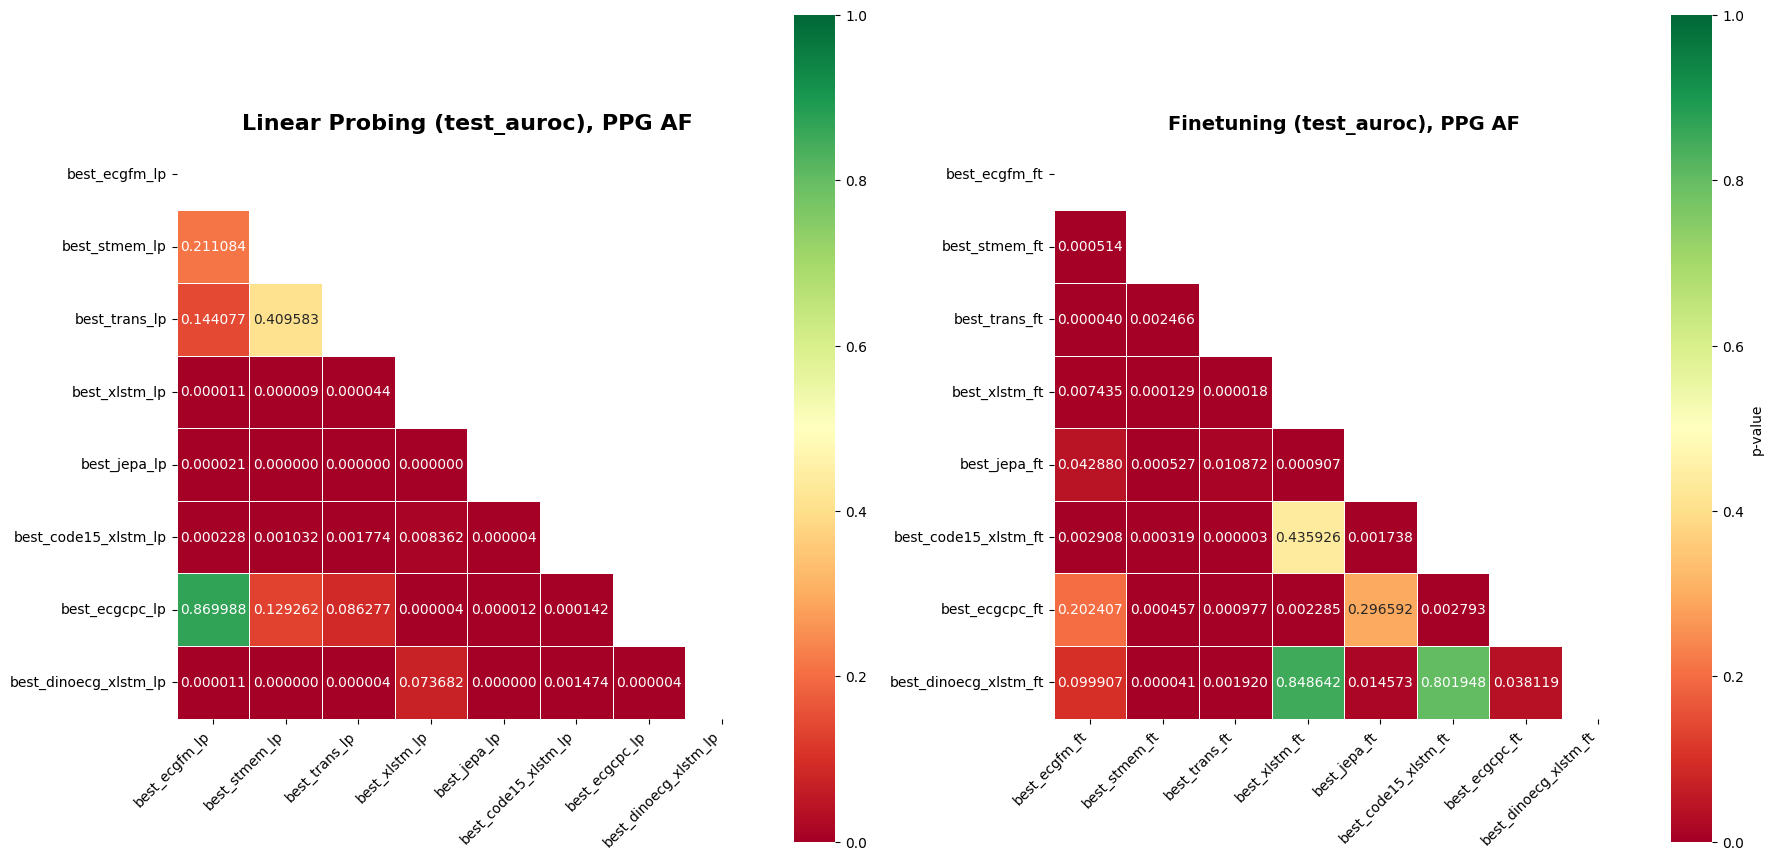

In [41]:
# p-values heatmap for ppg
plot_pvalues_heatmap(
    pd.DataFrame(records_ppg).set_index("group"), 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metric="test_auroc", 
    title="PPG AF", 
    figsize=(18, 9)
)

# AGE prediction

In [42]:
records_age = get_records("train-age", metrics=[
    "ptbxl/test_rsmape/dataloader_idx_0", "ptbxl/test_mae/dataloader_idx_0", "ptbxl/test_r2/dataloader_idx_0", "ptbxl/test_pearson/dataloader_idx_0",
    "mimic/test_rsmape/dataloader_idx_1", "mimic/test_mae/dataloader_idx_1", "mimic/test_r2/dataloader_idx_1", "mimic/test_pearson/dataloader_idx_1",
    "cpsc/test_rsmape/dataloader_idx_2", "cpsc/test_mae/dataloader_idx_2", "cpsc/test_r2/dataloader_idx_2", "cpsc/test_pearson/dataloader_idx_2",
    '_runtime'
], history=[('valid_mae', 'min'), ('valid_r2', 'max'), ('valid_pearson', 'max')])

def add_mean_age(df):
    df['mean_rsmape'] = (df['ptbxl/test_rsmape/dataloader_idx_0'] + df['mimic/test_rsmape/dataloader_idx_1'] + df['cpsc/test_rsmape/dataloader_idx_2']) / 3

    df['mean_mae'] = (df['ptbxl/test_mae/dataloader_idx_0'] + df['mimic/test_mae/dataloader_idx_1'] + df['cpsc/test_mae/dataloader_idx_2']) / 3

    df['mean_r2'] = (df['ptbxl/test_r2/dataloader_idx_0'] + df['mimic/test_r2/dataloader_idx_1'] + df['cpsc/test_r2/dataloader_idx_2']) / 3
    df['mean_rho'] = (df['ptbxl/test_pearson/dataloader_idx_0'] + df['mimic/test_pearson/dataloader_idx_1'] + df['cpsc/test_pearson/dataloader_idx_2']) / 3
        
    df['val_test_diff_mae'] = df['valid_mae'] - df['mean_mae']
    return df

formatted_df_age = get_dataframe_from_records(records_age, add_custom_columns=add_mean_age)

100%|██████████| 85/85 [07:10<00:00,  5.06s/it]


## Finetuning

In [43]:
age_ft = formatted_df_age[formatted_df_age.index.isin(ft_groups)]
# add two column, one for the average of mae and one for the average of rsmape
styled_df_age_ft = age_ft.style.apply(style_mean_column_min)
styled_df_age_ft

,ptbxl/test_rsmape/dataloader_idx_0 (mean ± std),ptbxl/test_mae/dataloader_idx_0 (mean ± std),ptbxl/test_r2/dataloader_idx_0 (mean ± std),ptbxl/test_pearson/dataloader_idx_0 (mean ± std),mimic/test_rsmape/dataloader_idx_1 (mean ± std),mimic/test_mae/dataloader_idx_1 (mean ± std),mimic/test_r2/dataloader_idx_1 (mean ± std),mimic/test_pearson/dataloader_idx_1 (mean ± std),cpsc/test_rsmape/dataloader_idx_2 (mean ± std),cpsc/test_mae/dataloader_idx_2 (mean ± std),cpsc/test_r2/dataloader_idx_2 (mean ± std),cpsc/test_pearson/dataloader_idx_2 (mean ± std),_runtime (mean ± std),valid_mae (mean ± std),valid_r2 (mean ± std),valid_pearson (mean ± std),mean_rsmape (mean ± std),mean_mae (mean ± std),mean_r2 (mean ± std),mean_rho (mean ± std),val_test_diff_mae (mean ± std)
,,,,,,,,,,,,,,,,,,,,,
group,,,,,,,,,,,,,,,,,,,,,
best_code15_xlstm_ft,0.073 ± 0.001,8.118 ± 0.073,0.614 ± 0.007,0.800 ± 0.002,0.077 ± 0.000,9.228 ± 0.047,0.528 ± 0.006,0.731 ± 0.004,0.080 ± 0.000,8.470 ± 0.052,0.667 ± 0.004,0.830 ± 0.002,4443.000 ± 521.060,7.069 ± 0.024,0.777 ± 0.001,0.882 ± 0.001,0.077 ± 0.000,8.605 ± 0.047,0.603 ± 0.005,0.787 ± 0.003,-1.536 ± 0.067
best_dinoecg_xlstm_ft,0.068 ± 0.001,7.490 ± 0.091,0.671 ± 0.008,0.826 ± 0.004,0.074 ± 0.000,8.815 ± 0.065,0.569 ± 0.007,0.755 ± 0.004,0.073 ± 0.001,7.744 ± 0.055,0.720 ± 0.004,0.852 ± 0.001,3931.800 ± 321.925,6.622 ± 0.016,0.801 ± 0.002,0.896 ± 0.001,0.071 ± 0.000,8.016 ± 0.039,0.653 ± 0.004,0.811 ± 0.002,-1.395 ± 0.049
best_ecgcpc_ft,0.074 ± 0.001,8.147 ± 0.103,0.605 ± 0.010,0.796 ± 0.004,0.079 ± 0.001,9.475 ± 0.143,0.507 ± 0.016,0.732 ± 0.005,0.086 ± 0.002,8.939 ± 0.161,0.631 ± 0.015,0.818 ± 0.005,9888.400 ± 318.692,7.247 ± 0.039,0.763 ± 0.003,0.879 ± 0.001,0.080 ± 0.001,8.854 ± 0.114,0.581 ± 0.011,0.782 ± 0.004,-1.606 ± 0.093
best_ecgfm_ft,0.071 ± 0.001,7.797 ± 0.157,0.643 ± 0.016,0.812 ± 0.007,0.075 ± 0.001,8.972 ± 0.125,0.560 ± 0.014,0.754 ± 0.006,0.077 ± 0.001,8.182 ± 0.097,0.689 ± 0.009,0.840 ± 0.003,8291.000 ± 1935.860,6.682 ± 0.081,0.799 ± 0.005,0.896 ± 0.002,0.074 ± 0.001,8.317 ± 0.111,0.630 ± 0.012,0.802 ± 0.004,-1.635 ± 0.097
best_jepa_ft,0.069 ± 0.002,7.753 ± 0.268,0.644 ± 0.024,0.826 ± 0.001,0.073 ± 0.001,8.801 ± 0.100,0.570 ± 0.011,0.762 ± 0.002,0.075 ± 0.001,8.071 ± 0.208,0.691 ± 0.017,0.851 ± 0.001,14383.000 ± 1537.977,6.312 ± 0.024,0.816 ± 0.003,0.905 ± 0.000,0.072 ± 0.001,8.209 ± 0.188,0.635 ± 0.017,0.813 ± 0.001,-1.896 ± 0.170
best_stmem_ft,0.067 ± 0.001,7.375 ± 0.107,0.678 ± 0.010,0.837 ± 0.003,0.068 ± 0.000,8.174 ± 0.040,0.633 ± 0.005,0.798 ± 0.003,0.067 ± 0.001,7.130 ± 0.077,0.763 ± 0.006,0.879 ± 0.001,7865.200 ± 1072.810,6.008 ± 0.043,0.837 ± 0.002,0.915 ± 0.001,0.067 ± 0.000,7.560 ± 0.052,0.691 ± 0.006,0.838 ± 0.002,-1.552 ± 0.072
best_trans_ft,0.080 ± 0.002,8.781 ± 0.176,0.552 ± 0.020,0.757 ± 0.008,0.084 ± 0.002,9.946 ± 0.198,0.458 ± 0.024,0.683 ± 0.015,0.089 ± 0.002,9.502 ± 0.182,0.578 ± 0.019,0.773 ± 0.007,3033.800 ± 775.671,7.852 ± 0.026,0.725 ± 0.002,0.852 ± 0.001,0.084 ± 0.002,9.409 ± 0.165,0.529 ± 0.019,0.738 ± 0.009,-1.557 ± 0.174
best_xlstm_ft,0.070 ± 0.001,7.737 ± 0.051,0.646 ± 0.005,0.816 ± 0.003,0.074 ± 0.001,8.889 ± 0.083,0.558 ± 0.009,0.752 ± 0.006,0.075 ± 0.001,7.941 ± 0.067,0.705 ± 0.004,0.847 ± 0.002,7249.800 ± 309.727,6.697 ± 0.023,0.796 ± 0.001,0.893 ± 0.001,0.073 ± 0.000,8.189 ± 0.042,0.636 ± 0.004,0.805 ± 0.003,-1.492 ± 0.061


## linear probing

In [44]:
age_lp = formatted_df_age[formatted_df_age.index.str.endswith("_lp")]
styled_df_age_lp = age_lp.style.apply(style_mean_column_min)
styled_df_age_lp

,ptbxl/test_rsmape/dataloader_idx_0 (mean ± std),ptbxl/test_mae/dataloader_idx_0 (mean ± std),ptbxl/test_r2/dataloader_idx_0 (mean ± std),ptbxl/test_pearson/dataloader_idx_0 (mean ± std),mimic/test_rsmape/dataloader_idx_1 (mean ± std),mimic/test_mae/dataloader_idx_1 (mean ± std),mimic/test_r2/dataloader_idx_1 (mean ± std),mimic/test_pearson/dataloader_idx_1 (mean ± std),cpsc/test_rsmape/dataloader_idx_2 (mean ± std),cpsc/test_mae/dataloader_idx_2 (mean ± std),cpsc/test_r2/dataloader_idx_2 (mean ± std),cpsc/test_pearson/dataloader_idx_2 (mean ± std),_runtime (mean ± std),valid_mae (mean ± std),valid_r2 (mean ± std),valid_pearson (mean ± std),mean_rsmape (mean ± std),mean_mae (mean ± std),mean_r2 (mean ± std),mean_rho (mean ± std),val_test_diff_mae (mean ± std)
,,,,,,,,,,,,,,,,,,,,,
group,,,,,,,,,,,,,,,,,,,,,
best_code15_xlstm_lp,0.077 ± 0.000,8.569 ± 0.006,0.574 ± 0.001,0.762 ± 0.000,0.082 ± 0.000,9.826 ± 0.009,0.474 ± 0.001,0.694 ± 0.000,0.084 ± 0.000,9.021 ± 0.006,0.634 ± 0.001,0.798 ± 0.000,3801.000 ± 197.123,8.372 ± 0.014,0.705 ± 0.001,0.840 ± 0.001,0.081 ± 0.000,9.139 ± 0.005,0.561 ± 0.000,0.751 ± 0.000,-0.767 ± 0.013
best_dinoecg_xlstm_lp,0.070 ± 0.000,7.763 ± 0.009,0.650 ± 0.001,0.810 ± 0.000,0.077 ± 0.000,9.284 ± 0.008,0.530 ± 0.001,0.731 ± 0.000,0.078 ± 0.000,8.271 ± 0.016,0.689 ± 0.001,0.837 ± 0.000,4318.200 ± 254.374,7.744 ± 0.020,0.746 ± 0.001,0.864 ± 0.001,0.075 ± 0.000,8.439 ± 0.007,0.623 ± 0.001,0.793 ± 0.000,-0.696 ± 0.024
best_ecgcpc_lp,0.100 ± 0.000,11.044 ± 0.012,0.306 ± 0.001,0.607 ± 0.001,0.112 ± 0.001,13.213 ± 0.048,0.097 ± 0.006,0.542 ± 0.001,0.117 ± 0.000,12.553 ± 0.022,0.332 ± 0.002,0.605 ± 0.001,7405.200 ± 440.713,12.299 ± 0.015,0.414 ± 0.002,0.645 ± 0.002,0.110 ± 0.000,12.270 ± 0.019,0.245 ± 0.003,0.585 ± 0.001,0.029 ± 0.031
best_ecgfm_lp,0.084 ± 0.000,9.297 ± 0.035,0.509 ± 0.002,0.722 ± 0.002,0.088 ± 0.001,10.624 ± 0.084,0.394 ± 0.011,0.641 ± 0.002,0.094 ± 0.000,10.036 ± 0.007,0.560 ± 0.000,0.749 ± 0.000,9039.800 ± 2402.150,9.335 ± 0.050,0.642 ± 0.004,0.801 ± 0.002,0.089 ± 0.000,9.986 ± 0.015,0.487 ± 0.003,0.704 ± 0.001,-0.651 ± 0.041
best_jepa_lp,0.076 ± 0.000,8.380 ± 0.015,0.595 ± 0.001,0.777 ± 0.000,0.083 ± 0.000,9.980 ± 0.009,0.463 ± 0.001,0.682 ± 0.001,0.083 ± 0.000,8.880 ± 0.017,0.650 ± 0.001,0.807 ± 0.000,9052.600 ± 115.993,7.952 ± 0.018,0.731 ± 0.002,0.855 ± 0.001,0.081 ± 0.000,9.080 ± 0.005,0.569 ± 0.000,0.755 ± 0.000,-1.128 ± 0.016
best_stmem_lp,0.089 ± 0.000,9.756 ± 0.011,0.458 ± 0.001,0.687 ± 0.000,0.097 ± 0.000,11.531 ± 0.046,0.300 ± 0.005,0.641 ± 0.001,0.104 ± 0.000,11.068 ± 0.039,0.474 ± 0.003,0.710 ± 0.001,7824.600 ± 1370.038,12.196 ± 0.027,0.417 ± 0.002,0.647 ± 0.002,0.097 ± 0.000,10.785 ± 0.031,0.410 ± 0.003,0.679 ± 0.001,1.411 ± 0.037
best_trans_lp,0.081 ± 0.000,8.889 ± 0.025,0.550 ± 0.003,0.743 ± 0.001,0.084 ± 0.000,10.022 ± 0.039,0.460 ± 0.004,0.686 ± 0.001,0.090 ± 0.000,9.571 ± 0.027,0.597 ± 0.002,0.774 ± 0.001,5572.400 ± 1099.009,8.865 ± 0.039,0.657 ± 0.003,0.813 ± 0.002,0.085 ± 0.000,9.494 ± 0.028,0.536 ± 0.003,0.735 ± 0.001,-0.629 ± 0.026
best_xlstm_lp,0.073 ± 0.000,7.976 ± 0.012,0.631 ± 0.001,0.803 ± 0.000,0.079 ± 0.000,9.408 ± 0.019,0.518 ± 0.002,0.727 ± 0.000,0.080 ± 0.000,8.472 ± 0.014,0.676 ± 0.001,0.827 ± 0.000,6440.800 ± 453.971,8.770 ± 0.015,0.670 ± 0.002,0.819 ± 0.001,0.077 ± 0.000,8.619 ± 0.009,0.609 ± 0.001,0.785 ± 0.000,0.151 ± 0.018


## Latex table generation

In [45]:

# MAE
print(df_to_latex_table_single_task(
    records_age, rename_map_latex, 
    groups_ft= ft_groups_table,
    groups_lp= lp_groups,
    metrics=[
        ("valid_mae", "CODE-15\\%", "min"),
        ("mimic/test_mae/dataloader_idx_1", "MIMIC-IV", "min"),
        ("ptbxl/test_mae/dataloader_idx_0", "PTB-XL", "min"),
        ("cpsc/test_mae/dataloader_idx_2", "CPSC", "min"),
        ("mean_mae", "MAE (mean)", "min"),
    ],
    task_name='Age (MAE)',
    caption= r"\textbf{Age.} Individual model mean absolute error (MAE) for the Age task (age regression, trained on CODE-15\% and evaluated on MIMIC-IV-ECG, PTB-XL and CPSC2018). Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:age_results_mae',
    format_dataframe=add_mean_age
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|ccccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{5}{c}{\textbf{Age (MAE)}} \\
    & CODE-15\%& MIMIC-IV& PTB-XL& CPSC& MAE (mean) \\
    \midrule
    \multicolumn{6}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 7.978 $\pm$ 0.027 & 9.652 $\pm$ 0.117 & 8.256 $\pm$ 0.064 & 8.779 $\pm$ 0.118 & 8.896 $\pm$ 0.079 \\
    \midrule
    \multicolumn{6}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 12.196 $\pm$ 0.027 & 11.531 $\pm$ 0.046 & 9.756 $\pm$ 0.011 & 11.068 $\pm$ 0.039 & 10.785 $\pm$ 0.031 \\
   ECG-JEPA & \underline{7.952 $\pm$ 0.018} & 9.980 $\pm$ 0.009 & 8.380 $\pm$ 0.015 & 8.880 $\pm$ 0.017 & 9.080 $\pm$ 0.005 \\
   ECGFounder & 9.335 $\pm$ 0.050 & 10.624 $\pm$ 0.084 & 9.297 $\pm$ 0.035 & 10.036 $\pm$ 0.007 & 9.986 $\pm$ 0.015 \\
   ECG-CPC & 12.299 $\pm$ 0.015 & 13.213 $\pm$ 0.048 & 11.044 $\pm$ 0.012 & 12.553 $\pm$ 0.022 & 12.270 $\pm$ 0.019 \\
   \textbf{S

In [46]:
# R2
print(df_to_latex_table_single_task(
    records_age, rename_map_latex, 
    groups_ft= ft_groups_table,
    groups_lp= lp_groups,
    metrics=[
        ("valid_r2", "CODE-15\\%", "max"),
        ("mimic/test_r2/dataloader_idx_1", "MIMIC-IV", "max"),
        ("ptbxl/test_r2/dataloader_idx_0", "PTB-XL", "max"),
        ("cpsc/test_r2/dataloader_idx_2", "CPSC", "max"),
        ("mean_r2", "R2 (mean)", "max"),
    ],
    task_name='Age ($R^2$)',
    caption= r"\textbf{Age.} Individual model R squared ($R^2$) for the Age task (age regression, trained on CODE-15\% and evaluated on MIMIC-IV-ECG, PTB-XL and CPSC2018). Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:age_results_r2',
    format_dataframe=add_mean_age
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|ccccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{5}{c}{\textbf{Age ($R^2$)}} \\
    & CODE-15\%& MIMIC-IV& PTB-XL& CPSC& R2 (mean) \\
    \midrule
    \multicolumn{6}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.718 $\pm$ 0.002 & 0.480 $\pm$ 0.015 & 0.597 $\pm$ 0.008 & 0.639 $\pm$ 0.011 & 0.572 $\pm$ 0.010 \\
    \midrule
    \multicolumn{6}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.417 $\pm$ 0.002 & 0.300 $\pm$ 0.005 & 0.458 $\pm$ 0.001 & 0.474 $\pm$ 0.003 & 0.410 $\pm$ 0.003 \\
   ECG-JEPA & \underline{0.731 $\pm$ 0.002} & 0.463 $\pm$ 0.001 & 0.595 $\pm$ 0.001 & 0.650 $\pm$ 0.001 & 0.569 $\pm$ 0.000 \\
   ECGFounder & 0.642 $\pm$ 0.004 & 0.394 $\pm$ 0.011 & 0.509 $\pm$ 0.002 & 0.560 $\pm$ 0.000 & 0.487 $\pm$ 0.003 \\
   ECG-CPC & 0.414 $\pm$ 0.002 & 0.097 $\pm$ 0.006 & 0.306 $\pm$ 0.001 & 0.332 $\pm$ 0.002 & 0.245 $\pm$ 0.003 \\
   \textbf{SimDINOv2 T

In [47]:
# R2
print(df_to_latex_table_single_task(
    records_age, rename_map_latex, 
    groups_ft= ft_groups_table,
    groups_lp= lp_groups,
    metrics=[
        ("valid_pearson", "CODE-15\\%", "max"),
        ("mimic/test_pearson/dataloader_idx_1", "MIMIC-IV", "max"),
        ("ptbxl/test_pearson/dataloader_idx_0", "PTB-XL", "max"),
        ("cpsc/test_pearson/dataloader_idx_2", "CPSC", "max"),
        ("mean_rho", "$\rho$ (mean)", "max"),
    ],
    task_name='Age (pearson correlation)',
    caption= r"\textbf{Age.} Individual model pearson correlation ($\rho$) for the Age task (age regression, trained on CODE-15\% and evaluated on MIMIC-IV-ECG, PTB-XL and CPSC2018). Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:age_results_pearson',
    format_dataframe=add_mean_age
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|ccccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{5}{c}{\textbf{Age (pearson correlation)}} \\
ho$ (mean) \\\%& MIMIC-IV& PTB-XL& CPSC& $
    \midrule
    \multicolumn{6}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.850 $\pm$ 0.001 & 0.703 $\pm$ 0.007 & 0.785 $\pm$ 0.002 & 0.806 $\pm$ 0.005 & 0.765 $\pm$ 0.004 \\
    \midrule
    \multicolumn{6}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.647 $\pm$ 0.002 & 0.641 $\pm$ 0.001 & 0.687 $\pm$ 0.000 & 0.710 $\pm$ 0.001 & 0.679 $\pm$ 0.001 \\
   ECG-JEPA & \underline{0.855 $\pm$ 0.001} & 0.682 $\pm$ 0.001 & 0.777 $\pm$ 0.000 & 0.807 $\pm$ 0.000 & 0.755 $\pm$ 0.000 \\
   ECGFounder & 0.801 $\pm$ 0.002 & 0.641 $\pm$ 0.002 & 0.722 $\pm$ 0.002 & 0.749 $\pm$ 0.000 & 0.704 $\pm$ 0.001 \\
   ECG-CPC & 0.645 $\pm$ 0.002 & 0.542 $\pm$ 0.001 & 0.607 $\pm$ 0.001 & 0.605 $\pm$ 0.001 & 0.585 $\pm$ 0.001 \\
   \textbf{SimDINOv

In [48]:
age_df = pd.DataFrame(records_age)
age_df['mean_r2'] = (age_df['ptbxl/test_r2/dataloader_idx_0'] + age_df['mimic/test_r2/dataloader_idx_1'] + age_df['cpsc/test_r2/dataloader_idx_2']) / 3

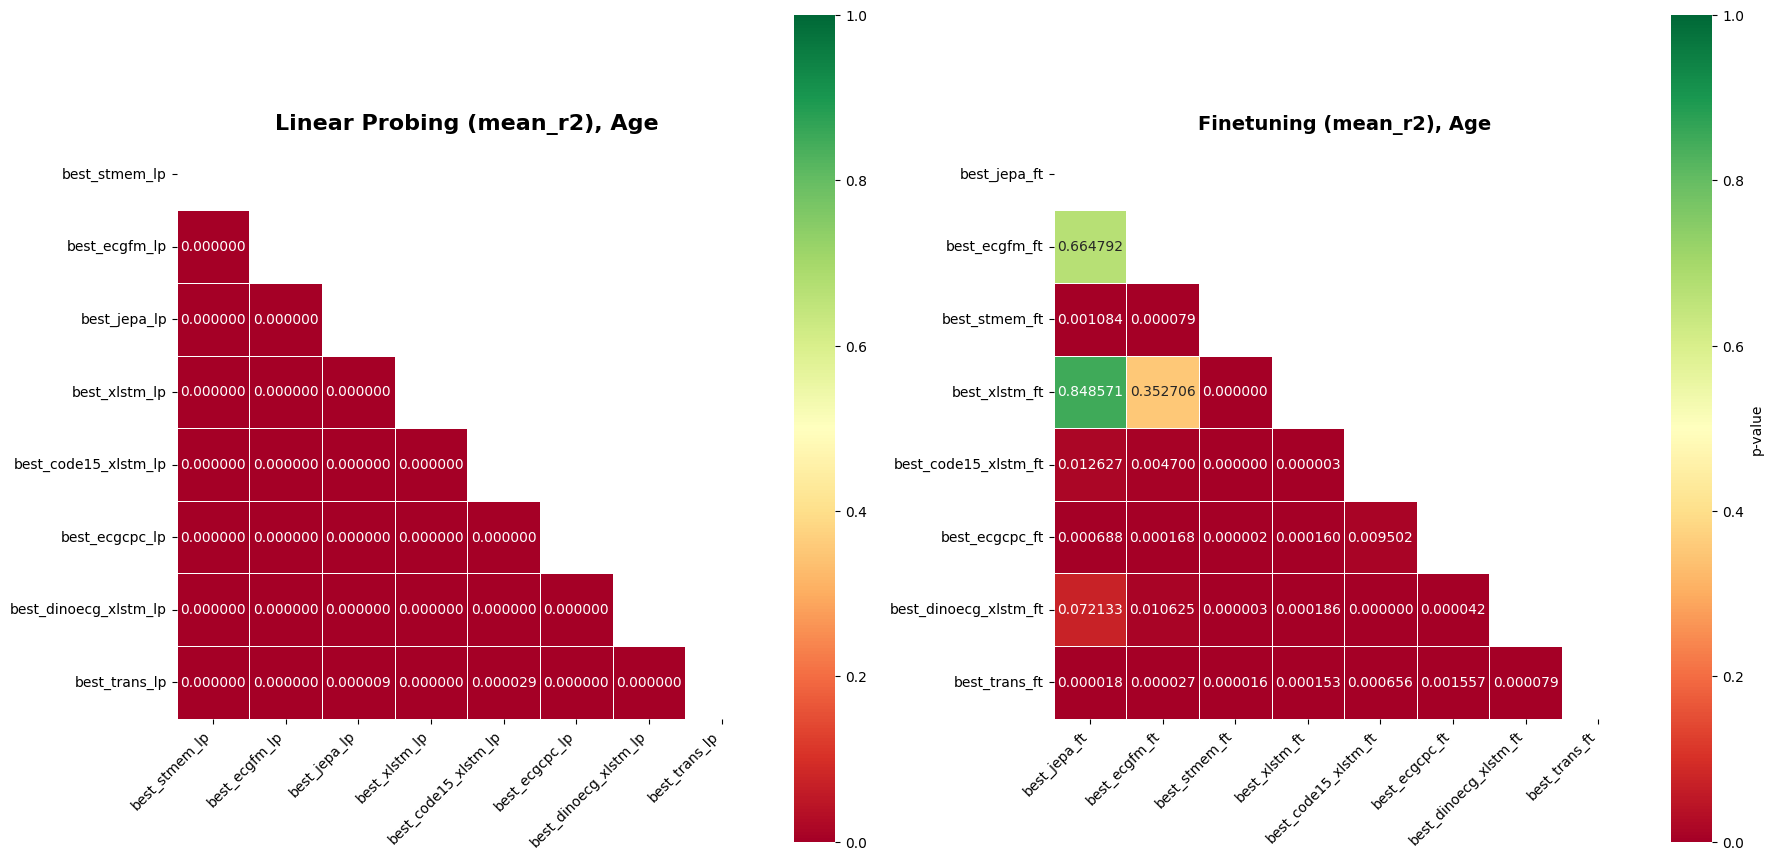

In [49]:
plot_pvalues_heatmap(
    age_df.set_index("group"),
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metric="mean_r2", 
    title="Age", 
    figsize=(18, 9)
)

# LAB tests

In [50]:
lab_test_records = get_records("train-lab", metrics=["test_auroc_avg", "test_f1_avg", "test_acc_avg", '_runtime'], regex="^best_")
formatted_df_lab_tests = get_dataframe_from_records(lab_test_records)

100%|██████████| 85/85 [00:38<00:00,  2.22it/s]


## Finetuning

In [51]:
lab_ft = formatted_df_lab_tests[formatted_df_lab_tests.index.isin(ft_groups)]
styled_lab_ft = lab_ft.style.apply(style_mean_column)
styled_lab_ft

,test_auroc_avg (mean ± std),test_f1_avg (mean ± std),test_acc_avg (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,0.733 ± 0.001,0.439 ± 0.002,0.443 ± 0.001,3426.992 ± 40.513
best_dinoecg_xlstm_ft,0.744 ± 0.001,0.449 ± 0.002,0.450 ± 0.002,3196.340 ± 76.188
best_ecgcpc_ft,0.739 ± 0.002,0.456 ± 0.003,0.457 ± 0.002,7185.188 ± 14.110
best_ecgfm_ft,0.714 ± 0.003,0.437 ± 0.003,0.440 ± 0.002,2005.857 ± 69.147
best_jepa_ft,0.735 ± 0.001,0.434 ± 0.001,0.440 ± 0.000,54315.083 ± 6558.821
best_stmem_ft,0.744 ± 0.002,0.457 ± 0.002,0.456 ± 0.002,53819.958 ± 4479.778
best_trans_ft,0.725 ± 0.001,0.443 ± 0.005,0.445 ± 0.004,2444.767 ± 238.973
best_xlstm_ft,0.747 ± 0.002,0.450 ± 0.002,0.451 ± 0.001,3425.334 ± 46.406


## linear probing

In [52]:
lab_lp = formatted_df_lab_tests[formatted_df_lab_tests.index.str.endswith("_lp")]
styled_lab_lp = lab_lp.style.apply(style_mean_column)
styled_lab_lp

,test_auroc_avg (mean ± std),test_f1_avg (mean ± std),test_acc_avg (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,0.715 ± 0.001,0.426 ± 0.000,0.433 ± 0.000,2577.530 ± 71.305
best_dinoecg_xlstm_lp,0.735 ± 0.001,0.437 ± 0.000,0.441 ± 0.000,2288.317 ± 52.775
best_ecgcpc_lp,0.713 ± 0.000,0.423 ± 0.001,0.428 ± 0.001,3538.470 ± 18.474
best_ecgfm_lp,0.711 ± 0.000,0.424 ± 0.000,0.430 ± 0.000,2212.457 ± 48.178
best_jepa_lp,0.722 ± 0.000,0.424 ± 0.000,0.432 ± 0.000,10821.596 ± 31.429
best_stmem_lp,0.708 ± 0.000,0.416 ± 0.000,0.424 ± 0.000,7830.652 ± 58.799
best_trans_lp,0.724 ± 0.001,0.431 ± 0.000,0.437 ± 0.000,2069.505 ± 32.188
best_xlstm_lp,0.733 ± 0.000,0.435 ± 0.001,0.439 ± 0.000,2506.129 ± 32.718


## latex table

In [53]:
print(df_to_latex_table_single_task(
    lab_test_records, rename_map_latex, 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metrics=[
        ("test_acc_avg", "Accuracy", 'max'),
        ("test_f1_avg", "F1 Score", 'max'),
        ("test_auroc_avg", "AUROC", 'max'),
    ],
    task_name='Blood test',
    caption= r"\textbf{Blood test.} Individual model performance for the Blood test task ((ab)normal classification of blood test results from MIMIC-IV-ECG). Each model is trained $5$ times and we report the mean$\pm$ standard deviation. Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:lab_test_results',
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|ccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{3}{c}{\textbf{Blood test}} \\
    & Accuracy& F1 Score& AUROC \\
    \midrule
    \multicolumn{4}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.425 $\pm$ 0.004 & 0.421 $\pm$ 0.003 & 0.683 $\pm$ 0.001 \\
    \midrule
    \multicolumn{4}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.424 $\pm$ 0.000 & 0.416 $\pm$ 0.000 & 0.708 $\pm$ 0.000 \\
   ECG-JEPA & 0.432 $\pm$ 0.000 & 0.424 $\pm$ 0.000 & 0.722 $\pm$ 0.000 \\
   ECGFounder & 0.430 $\pm$ 0.000 & 0.424 $\pm$ 0.000 & 0.711 $\pm$ 0.000 \\
   ECG-CPC & 0.428 $\pm$ 0.001 & 0.423 $\pm$ 0.001 & 0.713 $\pm$ 0.000 \\
   \textbf{SimDINOv2 Transf.} & 0.437 $\pm$ 0.000 & 0.431 $\pm$ 0.000 & 0.724 $\pm$ 0.001 \\
   \textbf{xECG (red. pretr.)} & 0.433 $\pm$ 0.000 & 0.426 $\pm$ 0.000 & 0.715 $\pm$ 0.001 \\
   \textbf{xECG (signal view)} & \textbf{0.441 $\pm$ 0.000} & \textbf

# Mortality prediction

In [54]:
mortality_test_records = get_records("train-mortality", metrics=["test_loss", "test_ci", '_runtime'], history=[('val_ci', 'max')], regex="^best_")
formatted_mortality_df = get_dataframe_from_records(mortality_test_records)

 25%|██▌       | 21/83 [00:41<02:01,  1.96s/it]

100%|██████████| 83/83 [02:40<00:00,  1.93s/it]

## Fine-tuning

In [55]:
mortality_ft = formatted_mortality_df[formatted_mortality_df.index.isin(ft_groups)]
styled_mortality_df = mortality_ft.style.apply(style_mean_column)
styled_mortality_df

,test_loss (mean ± std),test_ci (mean ± std),_runtime (mean ± std),val_ci (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,1.743 ± 0.002,0.694 ± 0.002,2123.918 ± 266.902,0.819 ± 0.004
best_dinoecg_xlstm_ft,1.739 ± 0.003,0.708 ± 0.001,1440.599 ± 109.722,0.834 ± 0.007
best_ecgcpc_ft,1.519 ± 0.004,0.677 ± 0.003,15666.078 ± 2520.785,0.805 ± 0.003
best_ecgfm_ft,1.770 ± 0.016,0.688 ± 0.002,3570.323 ± 967.786,0.820 ± 0.007
best_jepa_ft,1.450 ± 0.222,0.705 ± 0.002,32356.508 ± 20486.946,0.830 ± 0.005
best_stmem_ft,1.216 ± 0.009,0.693 ± 0.005,15726.945 ± 4788.128,0.776 ± 0.004
best_trans_ft,1.789 ± 0.003,0.701 ± 0.005,1924.050 ± 160.588,0.785 ± 0.008
best_xlstm_ft,1.778 ± 0.004,0.710 ± 0.002,3072.255 ± 310.722,0.818 ± 0.003


## Linear probing

In [56]:
mortality_lp = formatted_mortality_df[formatted_mortality_df.index.isin(lp_groups)]
styled_mortality_lp = mortality_lp.style.apply(style_mean_column)
styled_mortality_lp

,test_loss (mean ± std),test_ci (mean ± std),_runtime (mean ± std),val_ci (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,1.743 ± 0.001,0.692 ± 0.002,1342.797 ± 151.300,0.822 ± 0.004
best_dinoecg_xlstm_lp,1.739 ± 0.001,0.707 ± 0.002,1464.003 ± 11.607,0.834 ± 0.006
best_ecgcpc_lp,1.746 ± 0.000,0.665 ± 0.001,7826.535 ± 854.261,0.777 ± 0.011
best_ecgfm_lp,1.774 ± 0.018,0.683 ± 0.001,3209.680 ± 655.796,0.817 ± 0.003
best_jepa_lp,1.672 ± 0.083,0.706 ± 0.001,16444.765 ± 4752.299,0.830 ± 0.003
best_stmem_lp,1.735 ± 0.071,0.696 ± 0.003,14322.783 ± 4359.679,0.753 ± 0.004
best_trans_lp,1.772 ± 0.000,0.695 ± 0.001,1486.634 ± 13.129,0.781 ± 0.004
best_xlstm_lp,1.778 ± 0.001,0.704 ± 0.001,2031.110 ± 9.628,0.812 ± 0.008


## latex table

In [57]:
def format_df_difference(df):
    df['diff_ci'] = df['val_ci'] - df['test_ci']
    return df

print(df_to_latex_table_single_task(
    mortality_test_records, rename_map_latex, 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metrics=[
        ('val_ci', 'CI (CODE-15, Val)', 'max'),
        ("test_ci", "CI (MIMIC-IV-ECG, Test)", 'max'),
        ('diff_ci', 'CI difference', 'min'),
    ],
    task_name='Survival Analysis',
    caption= r"\textbf{Mortality.} Concordance Index (CI) for individual models for the Mortality task (survival analysis for mortality prediction, trained on CODE-15\% and evaluated on MIMIC-IV-ECG). Each model is trained $5$ times and we report the mean$\pm$ standard deviation. Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:mortality_results',
    format_dataframe=format_df_difference
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|ccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{3}{c}{\textbf{Survival Analysis}} \\
    & CI (CODE-15, Val)& CI (MIMIC-IV-ECG, Test)& CI difference \\
    \midrule
    \multicolumn{4}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.650 $\pm$ 0.017 & 0.626 $\pm$ 0.014 & 0.024 $\pm$ 0.017 \\
    \midrule
    \multicolumn{4}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.753 $\pm$ 0.004 & 0.696 $\pm$ 0.003 & \textbf{0.057 $\pm$ 0.004} \\
   ECG-JEPA & \textbf{0.830 $\pm$ 0.003} & \textbf{0.706 $\pm$ 0.001} & 0.125 $\pm$ 0.003 \\
   ECGFounder & 0.817 $\pm$ 0.003 & 0.683 $\pm$ 0.001 & 0.134 $\pm$ 0.003 \\
   ECG-CPC & 0.777 $\pm$ 0.011 & 0.665 $\pm$ 0.001 & 0.112 $\pm$ 0.012 \\
   \textbf{SimDINOv2 Transf.} & 0.781 $\pm$ 0.004 & 0.695 $\pm$ 0.001 & \underline{0.085 $\pm$ 0.005} \\
   \textbf{xECG (red. pretr.)} & 0.822 $\pm$ 0.004 & 0.692 $\pm$ 0.002 & 0.129 $\pm$ 

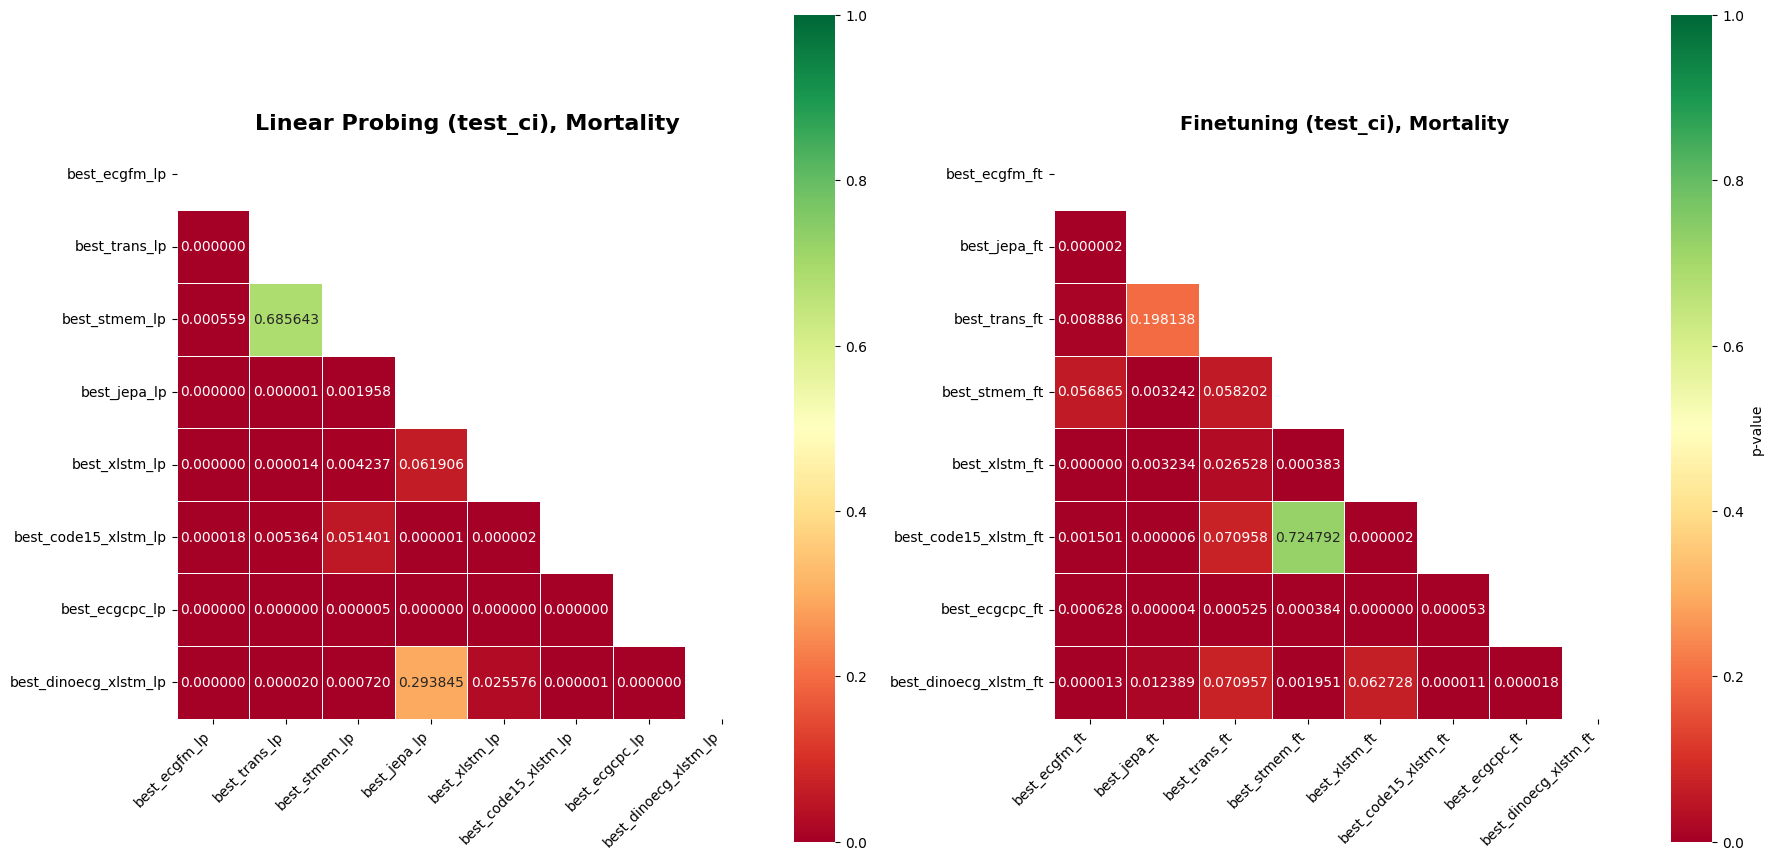

In [58]:
# p-values heatmap for ppg
plot_pvalues_heatmap(
    pd.DataFrame(mortality_test_records).set_index("group"), 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metric="test_ci", 
    title="Mortality", 
    figsize=(18, 9)
)

# Time analysis

/tmp/ipykernel_34493/4061463490.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df.index, rotation=45, horizontalalignment='right', fontsize=22)


<Figure size 1500x600 with 0 Axes>

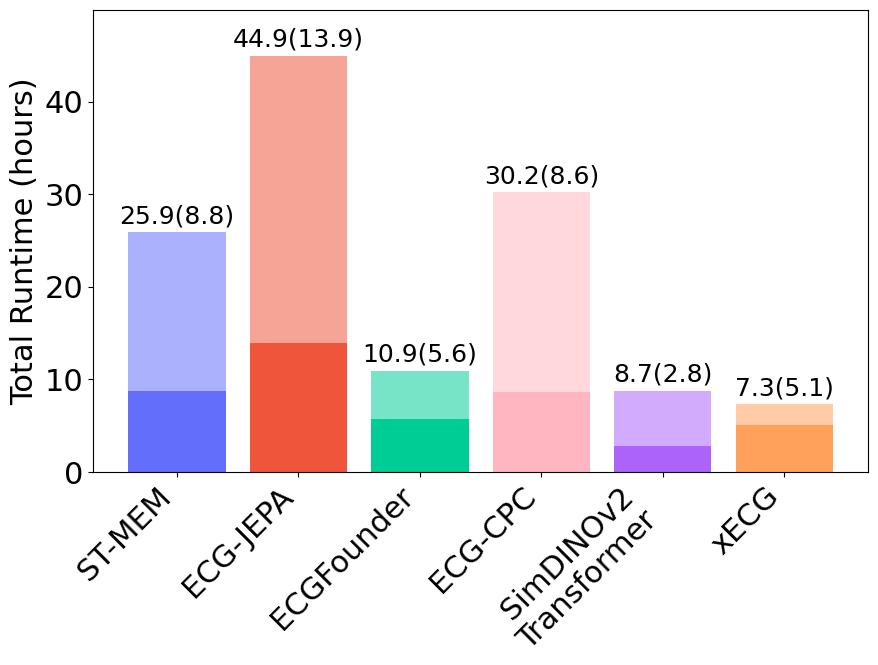

In [59]:
import seaborn as sns 
from matplotlib import pyplot as plt 
from plotly.colors import qualitative

rename_map_main = {
    "best_stmem_ft": "ST-MEM",
    "best_stmem_lp": "ST-MEM",
    "best_jepa_ft": "ECG-JEPA",
    "best_jepa_lp": "ECG-JEPA",
    "best_ecgfm_ft": "ECGFounder",
    "best_ecgfm_lp": "ECGFounder",
    "best_trans_ft": "SimDINOv2\nTransformer",
    "best_trans_lp": "SimDINOv2\nTransformer",
    "best_xlstm_ft": "xECG",
    "best_xlstm_lp": "xECG",
    "best_xlstm_sup": "Supervised\nxLSTM",
    "best_ecgcpc_ft": "ECG-CPC",
    "best_ecgcpc_lp": "ECG-CPC"
}

lp_groups_time_analysis = ['best_stmem_lp', 'best_jepa_lp', 'best_ecgfm_lp', 'best_ecgcpc_lp', 'best_xlstm_lp', 'best_trans_lp']
ft_groups_time_analysis = ['best_stmem_ft', 'best_jepa_ft', 'best_ecgfm_ft', 'best_ecgcpc_ft', 'best_xlstm_ft', 'best_trans_ft']

display_order = [ "ST-MEM", "ECG-JEPA", "ECGFounder", "ECG-CPC", "SimDINOv2\nTransformer", "xECG"]

def process_runtimes(records_list):
    """Aggregates runtimes across multiple datasets."""
    total_runtime = pd.Series(dtype=float)
    
    for records in records_list:
        df = pd.DataFrame(records)
        # Calculate mean runtime for this specific dataset/task per group
        means = df.groupby("group")['_runtime'].mean()
        # Add to cumulative total (handling missing keys with fill_value=0)
        total_runtime = total_runtime.add(means, fill_value=0)
        
    return total_runtime / 3600  # Convert to hours

# List of all your record lists
all_datasets = [ records_ptb_xl, records_cpsc, records_mit_cls, records_mit_r_peaks,  records_exe_r, records_sleep_apnea, records_ppg, records_age, lab_test_records ]
runtimes = process_runtimes(all_datasets)

# Helper to extract data subset
def get_subset(series, targets, suffix_len):
    subset = series[series.index.isin(targets)].copy()
    # Create a mapping for colors based on the original index before renaming
    # We assume 'colors_idxs' is defined globally as in your snippet
    color_map = {k: colors_idxs[k] for k in subset.index}
    
    # Rename to display names
    subset.index = subset.index.map(rename_map_main)
    
    # Create DF
    df = subset.to_frame(name='runtime')
    # Map colors: suffix_len handles removing last 2 chars if needed, 
    # though hex logic usually just appends. 
    # Based on your code: strip last 2, add '88' or 'FF'
    df['color_hex'] = [color_map[k] for k in subset.index.map({v: k for k, v in rename_map_main.items() if k in targets})] 
    return df

# Create FT and LP DataFrames
df_ft = pd.DataFrame({'runtime': runtimes[ft_groups_time_analysis]})
df_ft['display_name'] = df_ft.index.map(rename_map_main)
df_ft['base_color'] = [colors_idxs[i] for i in df_ft.index]

df_lp = pd.DataFrame({'runtime': runtimes[lp_groups_time_analysis]})
df_lp['display_name'] = df_lp.index.map(rename_map_main)
df_lp['base_color'] = [colors_idxs[i] for i in df_lp.index]

# Merge into one Main DataFrame keyed by Display Name
# This ensures alignment even if lists were different lengths
plot_df = pd.merge(
    df_ft.set_index('display_name')[['runtime', 'base_color']].rename(columns={'runtime': 'ft_runtime'}),
    df_lp.set_index('display_name')[['runtime']].rename(columns={'runtime': 'lp_runtime'}),
    left_index=True, 
    right_index=True
)

plot_df = plot_df.reindex(display_order)

# Generate final plot colors
# FT = Transparent ('88'), LP = Solid ('FF')
# Assumes base_color is #RRGGBB or #RRGGBBAA. Cutting [:-2] assumes it has alpha already
plot_df['ft_color'] = plot_df['base_color'].apply(lambda x: x[:-2] + '88')
plot_df['lp_color'] = plot_df['base_color'].apply(lambda x: x[:-2] + 'FF')

# --- 5. Plotting ---
plt.figure(figsize=(15, 6)) # Global figure (optional, often overwritten by subplots)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FT (Taller bars, usually)
ax.bar(plot_df.index, plot_df['ft_runtime'], color=plot_df['ft_color'], label='Fine-Tuning')
# Plot LP (Shorter bars, usually)
ax.bar(plot_df.index, plot_df['lp_runtime'], color=plot_df['lp_color'], label='Linear Probing')

# Styling
ax.set_xticklabels(plot_df.index, rotation=45, horizontalalignment='right', fontsize=22)
ax.set_ylabel('Total Runtime (hours)', fontsize=22)
ax.tick_params(axis='y', labelsize=22)
ax.set_ylim(0, plot_df['ft_runtime'].max() + 5)

# Annotations
for idx, row in enumerate(plot_df.itertuples()):
    ft_val = row.ft_runtime
    lp_val = row.lp_runtime
    
    # Use coordinate 'idx' for x-position because we are plotting based on the reindexed dataframe
    ax.annotate(
        f"{ft_val:.1f}({lp_val:.1f})", 
        (idx, max(ft_val, lp_val) + 0.5),
        ha="center", va="bottom", fontsize=18
    )

plt.savefig('figs/total_running_time.svg', bbox_inches='tight', dpi=300)
plt.show()

In [60]:
time_groups = ['time_xlstm_ft', 'time_xlstm_lp', 'time_ecgfm_ft', 'time_ecgfm_lp', 'time_jepa_ft', 'time_jepa_lp', 'time_stmem_ft', 'time_stmem_lp', 'time_trans_ft', 'time_trans_lp', 'time_ecgcpc_ft', 'time_ecgcpc_lp']
records_time_ptbxl = get_records("train-ptbxl-diagnosis_superclass-multilabel", metrics=['_runtime'], get_memory=True, pattern=(lambda run: run.group is not None and run.group.startswith("time_")), regex='^time_')
df_time_ptbxl = pd.DataFrame(records_time_ptbxl)
df_time_ptbxl = df_time_ptbxl[df_time_ptbxl['group'].isin(time_groups)]
df_time_ptbxl.head(20)

df_time_ptbxl['memory'] = df_time_ptbxl['memory2'] / (1024 * 1024 * 1024)  # Convert to GB
print(df_time_ptbxl)

100%|██████████| 13/13 [00:17<00:00,  1.33s/it]

             group     _runtime     memory       memory2
0    time_ecgfm_ft   501.421230   4.232300  4.544397e+09
1    time_ecgfm_lp   268.674076   1.538940  1.652425e+09
2     time_jepa_lp  1726.364747   4.802612  5.156766e+09
3     time_jepa_ft  4031.126119  34.130737  3.664760e+10
4    time_stmem_lp  1147.352642   4.177612  4.485677e+09
5    time_stmem_ft  2776.311824  28.435425  3.053230e+10
6    time_trans_lp   232.517489   1.745972  1.874723e+09
7    time_trans_ft   353.886232   4.249878  4.563272e+09
8    time_xlstm_lp   272.991870   2.144409  2.302542e+09
9    time_xlstm_ft   459.003388   4.380737  4.703781e+09
11  time_ecgcpc_ft  1750.583814  15.917847  1.709166e+10
12  time_ecgcpc_lp   744.103997   4.890503  5.251138e+09


/tmp/ipykernel_34493/1798108361.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df.index, rotation=45, horizontalalignment='right', fontsize=22)


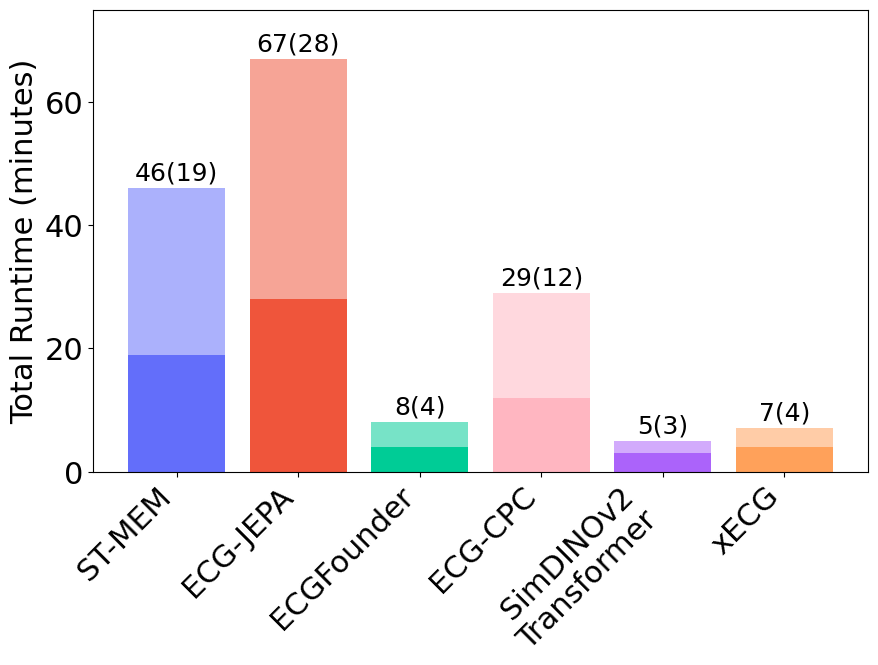

In [61]:
df = df_time_ptbxl.copy()
df['runtime'] = df['_runtime'] // 60  # Convert to minutes
df['group'] = df['group'].str.replace('time_', 'best_')
df = df.set_index('group')

# Extract FT and LP subsets
# We utilize intersection to safely handle missing keys
df_ft = df.loc[df.index.intersection(ft_groups)].rename(columns={'runtime': 'ft_runtime', 'memory': 'ft_memory'})
df_lp = df.loc[df.index.intersection(lp_groups)].rename(columns={'runtime': 'lp_runtime', 'memory': 'lp_memory'})

# Map to Display Names and assign Base Colors
# We get colors *before* renaming the index to ensure we match keys in 'colors_idxs'
df_ft['base_color'] = [colors_idxs[idx] for idx in df_ft.index]
df_ft['display_name'] = df_ft.index.map(rename_map_main)

# LP only needs the mapping for the merge key
df_lp['display_name'] = df_lp.index.map(rename_map_main)

# Merge into a unified plotting DataFrame
plot_df = pd.merge(
    df_ft[['display_name', 'ft_runtime', 'ft_memory', 'base_color']],
    df_lp[['display_name', 'lp_runtime', 'lp_memory']],
    on='display_name'
).set_index('display_name')

# Apply custom ordering
plot_df = plot_df.reindex(display_order)

# Generate specific colors (FT = Transparent '88', LP = Solid 'FF')
plot_df['color_ft'] = plot_df['base_color'].apply(lambda x: x[:-2] + '88')
plot_df['color_lp'] = plot_df['base_color'].apply(lambda x: x[:-2] + 'FF')

# --- 3. PLOTTING ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
ax.bar(plot_df.index, plot_df['ft_runtime'], color=plot_df['color_ft'], label='Fine-Tuning')
ax.bar(plot_df.index, plot_df['lp_runtime'], color=plot_df['color_lp'], label='Linear Probing')

# Styling
ax.set_xticklabels(plot_df.index, rotation=45, horizontalalignment='right', fontsize=22)
ax.set_ylabel('Total Runtime (minutes)', fontsize=22)
ax.tick_params(axis='both', labelsize=22)

# Dynamic Y-Limit (Max value + padding)
max_val = max(plot_df['ft_runtime'].max(), plot_df['lp_runtime'].max())
ax.set_ylim(0, max_val + 8)

# Annotations
for i, row in enumerate(plot_df.itertuples()):
    ft = row.ft_runtime
    lp = row.lp_runtime
    # Annotate with integer values
    ax.annotate(
        f"{int(ft)}({int(lp)})", 
        (i, max(ft, lp) + 0.5),  # Position slightly above the taller bar
        ha="center", va="bottom", fontsize=18
    )

# Save
plt.savefig('figs/runtime_comparison_ptbxl.svg', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_34493/3770133409.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=22)


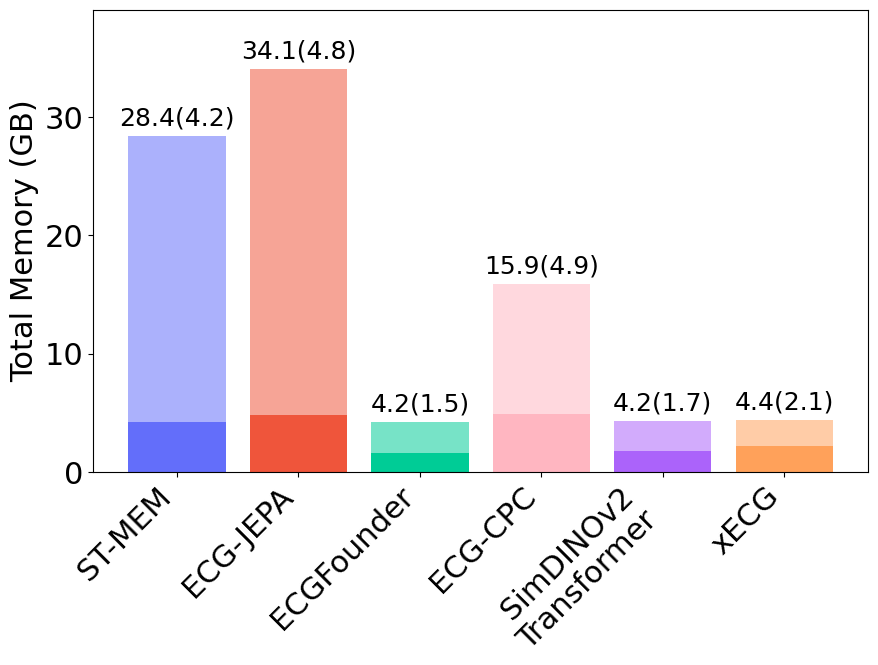

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(plot_df.index, plot_df['ft_memory'], color=plot_df['color_ft'], label='Fine-Tuning')
ax.bar(plot_df.index, plot_df['lp_memory'], color=plot_df['color_lp'], label='Linear Probing')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=22)
# ax.set_xlabel('Method', fontsize=22)
ax.set_ylabel('Total Memory (GB)', fontsize=22)
ax.tick_params(axis='both', labelsize=22)
# set max y to + 1
ax.set_ylim(0, plot_df['ft_memory'].max() + 5)

# add on top of the bar the number
for i, (ft, lp) in enumerate(zip(plot_df["ft_memory"], plot_df["lp_memory"])):
    ax.annotate(f"{ft:.1f}({lp:.1f})", 
                (i, max(ft, lp)+0.5),  # position above the taller bar
                ha="center", va="bottom", fontsize=18)
    
# save figure
plt.savefig('figs/memory_comparison_ptbxl.svg', bbox_inches='tight', dpi=300)

# RANKING

In [63]:

dfs = []
for i, records in enumerate([records_ptb_xl, records_cpsc, records_mit_cls, records_sleep_apnea, records_ppg, records_exe_r, records_mit_r_peaks, records_age, lab_test_records, mortality_test_records]):
    df = pd.DataFrame(records)
    if i == 7: df = add_mean_age(df) # for age prediction add the mean rsmape
    df = df.groupby("group").agg('mean')
    df = df[df.index.isin(ft_groups) | df.index.isin(lp_groups)]
    dfs.append(df)

In [72]:
categories = ['PTB-XL', 'CPSC2018', 'MIT-BIH', 'Sleep Apnea', 'PPG AF', r'Exercise<br>R-Peak', 'R-peak', 'Age', 'Blood Test', 'Survival']
categories_metric = ['PTB-XL / AUC', 'CPSC2018 / AUC', 'MIT-BIH / F1', 'Sleep Apnea / AUC', 'PPG / AUC', 'Exercise R-Peak / F1', 'R-Peaks / F1', 'Age / R^2', 'LAB test / AUC', 'Mortality / CI']

methods_main = ['xECG', 'ECG-CPC', 'ST-MEM', 'ECG-JEPA', 'ECG Founder']
groups_main_lp = ['best_xlstm_lp', 'best_ecgcpc_lp', 'best_stmem_lp', 'best_jepa_lp', 'best_ecgfm_lp' ]
groups_main_ft = ['best_xlstm_ft','best_ecgcpc_ft', 'best_stmem_ft', 'best_jepa_ft', 'best_ecgfm_ft' ]

methods_ablations = ['xECG', 'xECG (signal view)', 'xECG (reduced pretraining)', 'SimDINOv2 Transformer', 'Supervised xLSTM']
groups_abl_lp = ['best_xlstm_lp',  'best_dinoecg_xlstm_lp', 'best_code15_xlstm_lp', 'best_trans_lp']
groups_abl_ft = ['best_xlstm_ft', 'best_dinoecg_xlstm_ft', 'best_code15_xlstm_ft', 'best_trans_ft',  'best_xlstm_sup']

reindex_ft = [4, 3, 0, 1, 2]

def get_full_results(dfs, groups, methods):
    data = {
        'PTB-XL / AUC': [  dfs[0].loc[f'{group}']['test_auroc'] for group in groups],
        'CPSC2018 / AUC': [ dfs[1].loc[f'{group}']['test_auroc'] for group in groups],
        'MIT-BIH / F1': [ dfs[2].loc[f'{group}']['test_f1/mean'] for group in groups], 
        'Sleep Apnea / AUC': [ dfs[3].loc[f'{group}']['test_auc'] for group in groups ],
        'PPG / AUC': [  dfs[4].loc[f'{group}']['test_auroc'] for group in groups],
        'Exercise R-Peak / F1': [  dfs[5].loc[f'{group}']['test_f1_20'] for group in groups],
        'R-Peaks / F1': [  dfs[6].loc[f'{group}']['test_f1_20'] for group in groups],
        'Age / R^2': [  dfs[7].loc[f'{group}']['mean_r2'] for group in groups],   
        'LAB test / AUC': [  dfs[8].loc[f'{group}']['test_auroc_avg'] for group in groups],
        'Mortality / CI': [ dfs[9].loc[f'{group}']['test_ci'] for group in groups],
    }
    df = pd.DataFrame(data)
    # name index as method and reorder it according to methods
    df.index = methods
    df = df.reindex(methods)
    return df
        
df_main_ft = get_full_results(dfs, groups_main_ft, methods_main)
df_main_ft.to_csv("../results/scores_finetuning.csv")
df_main_ft.head(n=10)


,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise R-Peak / F1,R-Peaks / F1,Age / R^2,LAB test / AUC,Mortality / CI
xECG,0.927636,0.981308,0.677293,0.927839,0.883472,0.965102,0.923541,0.636357,0.747493,0.710135
ECG-CPC,0.928764,0.966472,0.466210,0.935022,0.832124,0.967477,0.878740,0.581042,0.739390,0.677355
ST-MEM,0.929916,0.958217,0.644152,0.700258,0.642692,0.983765,0.938170,0.691434,0.744403,0.693160
ECG-JEPA,0.923336,0.965220,0.583076,0.690438,0.818351,0.865988,0.910261,0.634749,0.735094,0.704892
ECG Founder,0.930447,0.969354,0.207231,0.778393,0.845594,0.081819,0.036652,0.630484,0.714474,0.687694


In [73]:
df_abl_ft = get_full_results(dfs, groups_abl_ft, methods_ablations)
df_abl_ft.to_csv("../results/scores_ablations_ft.csv")
df_abl_ft.head(n=10)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise R-Peak / F1,R-Peaks / F1,Age / R^2,LAB test / AUC,Mortality / CI
xECG,0.927636,0.981308,0.677293,0.927839,0.883472,0.965102,0.923541,0.636357,0.747493,0.710135
xECG (signal view),0.923808,0.981438,0.587818,0.848669,0.879858,0.960691,0.913284,0.653399,0.744386,0.707624
xECG (reduced pretraining),0.920755,0.976973,0.481287,0.874788,0.875427,0.962123,0.895025,0.603012,0.733019,0.693982
SimDINOv2 Transformer,0.924652,0.965467,0.425415,0.680796,0.779656,0.618493,0.906680,0.529230,0.725261,0.700722
Supervised xLSTM,0.890728,0.951107,0.402199,0.834288,0.876326,0.966273,0.888322,0.571893,0.683108,0.626128


In [75]:
df_abl_lp = get_full_results(dfs, groups_abl_lp, methods_ablations[:-1])
df_abl_lp.to_csv("../results/scores_ablations_lp.csv")
df_abl_lp.head(n=10)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise R-Peak / F1,R-Peaks / F1,Age / R^2,LAB test / AUC,Mortality / CI
xECG,0.915361,0.967798,0.673956,0.879130,0.750782,0.892065,0.590708,0.608502,0.732535,0.703769
xECG (signal view),0.909149,0.966252,0.560088,0.861430,0.765697,0.871915,0.611735,0.623150,0.735400,0.706589
xECG (reduced pretraining),0.909255,0.963848,0.448105,0.796271,0.714632,0.936156,0.726427,0.560927,0.714512,0.692093
SimDINOv2 Transformer,0.913967,0.950829,0.395488,0.644381,0.655769,0.322274,0.504284,0.535692,0.724285,0.695453


In [76]:
df_main_lp = get_full_results(dfs, groups_main_lp, methods_main)
df_main_lp.to_csv("../results/scores_linear_probing.csv")
df_main_lp.head(n=10)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise R-Peak / F1,R-Peaks / F1,Age / R^2,LAB test / AUC,Mortality / CI
xECG,0.915361,0.967798,0.673956,0.879130,0.750782,0.892065,0.590708,0.608502,0.732535,0.703769
ECG-CPC,0.889592,0.951233,0.380535,0.734442,0.638776,0.860712,0.475381,0.244822,0.712585,0.664729
ST-MEM,0.867034,0.922097,0.436191,0.598744,0.653246,0.632102,0.565592,0.410452,0.708151,0.696118
ECG-JEPA,0.902226,0.961038,0.496206,0.666892,0.476946,0.526243,0.444333,0.569293,0.721784,0.705503
ECG Founder,0.917335,0.961727,0.206484,0.776873,0.640672,0.083212,0.036579,0.487384,0.711333,0.683029


In [77]:
# add color to each method for consistency
from plotly.colors import qualitative

colors = {
    "ST-MEM": "#636EFA",
    "ECG-JEPA": "#EF553B",
    "ECG Founder": "#00CC96",
    "ECG-CPC": "#FFB6C1",
    "xECG": "#FFA15A",
    "SimDINOv2 Transformer": "#8F7AE5",
    "Supervised xLSTM": "#4FB6C2",
    "xECG (signal view)": "#E89B3F",
    "xECG (reduced pretraining)": "#5FBF8F"
}

df_main_ft["color"] = [colors[idx] for idx in df_main_ft.index]
df_main_lp["color"] = [colors[idx] for idx in df_main_lp.index]
df_abl_lp["color"] = [colors[idx] for idx in df_abl_lp.index]
df_abl_ft["color"] = [colors[idx] for idx in df_abl_ft.index]

# add some alpha for better visibility
pastel_colors = [f"{color}C0" for color in colors.values()]  #
df_main_ft["pastel_color"] = [pastel_colors[list(colors.keys()).index(idx)] for idx in df_main_ft.index]
df_main_lp["pastel_color"] = [pastel_colors[list(colors.keys()).index(idx)] for idx in df_main_lp.index]
df_abl_lp["pastel_color"] = [pastel_colors[list(colors.keys()).index(idx)] for idx in df_abl_lp.index]
df_abl_ft["pastel_color"] = [pastel_colors[list(colors.keys()).index(idx)] for idx in df_abl_ft.index]

df_main_ft.head(n=100)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise R-Peak / F1,R-Peaks / F1,Age / R^2,LAB test / AUC,Mortality / CI,color,pastel_color
xECG,0.927636,0.981308,0.677293,0.927839,0.883472,0.965102,0.923541,0.636357,0.747493,0.710135,#FFA15A,#FFA15AC0
ECG-CPC,0.928764,0.966472,0.466210,0.935022,0.832124,0.967477,0.878740,0.581042,0.739390,0.677355,#FFB6C1,#FFB6C1C0
ST-MEM,0.929916,0.958217,0.644152,0.700258,0.642692,0.983765,0.938170,0.691434,0.744403,0.693160,#636EFA,#636EFAC0
ECG-JEPA,0.923336,0.965220,0.583076,0.690438,0.818351,0.865988,0.910261,0.634749,0.735094,0.704892,#EF553B,#EF553BC0
ECG Founder,0.930447,0.969354,0.207231,0.778393,0.845594,0.081819,0.036652,0.630484,0.714474,0.687694,#00CC96,#00CC96C0


In [78]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio

def plot_radar_plots(df_ft, df_lp, categories, title='radar_chart_methods'):
    pio.templates.default = "plotly"

    categories_closed = categories + [categories[0]]

    fig = go.Figure()

    min_v = 0.
    max_v = 1.

    rows = 2
    cols = 6 

    # --- FIX 1: UPDATE SPECS ---
    # Both rows now use 'colspan': 2 so all plots get equal width (1/3 of total).
    # We use 'None' to create empty spaces for centering.
    fig = make_subplots(
        rows=rows, cols=cols,
        specs=[
            [None, {'type': 'polar', 'colspan': 2}, None, {'type': 'polar', 'colspan': 2}, None, None],
            [{'type': 'polar', 'colspan': 2}, None, {'type': 'polar', 'colspan': 2}, None, {'type': 'polar', 'colspan': 2}, None]
        ],
        subplot_titles=df_ft.index.tolist(),
        vertical_spacing=0.15,
        horizontal_spacing=0.15  # Reduced slightly to allow max size for all
    )

    # --- FIX 2: REMOVE MANUAL DOMAIN OVERRIDES ---
    # Delete or comment these out. Let the grid handle the sizing.
    # fig.layout.polar1.domain.x = [0.19, 0.45] 
    # fig.layout.polar2.domain.x = [0.53, 0.85]

    # --- FIX 3: UPDATE POSITIONS ---
    # Row 1 plots are now at column indices 2 and 4 (to be centered relative to the 3 below)
    positions = [
        [1, 2], [1, 4],          
        [2, 1], [2, 3], [2, 5]   
    ]

    for i, (idx, row) in enumerate(df_ft.iterrows()):
        current_row = positions[i][0]
        current_col = positions[i][1]

        values = row.tolist()[:-2] + [row.tolist()[0]] 
        
        fig.add_trace(
            go.Scatterpolar(
                r=values,
                theta=categories_closed,
                fill='toself',
                name=f"<b>{idx}</b>",
                line=dict(width=2, color=row['color']),
                hoverinfo='skip',
                marker=dict(symbol="diamond", size=8, color=row['color']),
            ),
            row=current_row, col=current_col
        )

        if i < len(df_lp):
            values_lp = df_lp.iloc[i].tolist()[:-2] + [df_lp.iloc[i].tolist()[0]]
            values_lp = [float(value) for value in values_lp]
            
            fig.add_trace(
                go.Scatterpolar(
                    r=values_lp,
                    theta=categories_closed,
                    fill='toself',
                    name=f"<b>{idx}</b>",
                    line=dict(width=2, color=row['color']),
                    hoverinfo='skip',
                    marker=dict(symbol="circle", size=8, color=row['color']),
                ),
                row=current_row, col=current_col
            )

        polar_key = f'polar{i + 1}' if i == 0 else f'polar{i + 1}'
        # Plotly naming convention: polar, polar2, polar3...
        # However, make_subplots usually handles the key mapping internally.
        # To strictly update the specific polar object created by make_subplots:
        
        fig.update_layout({
            polar_key: dict(
                angularaxis=dict(rotation=30),
                radialaxis=dict(
                    visible=True, 
                    range=[min_v, max_v], 
                    showticklabels=True, 
                    showline=True,
                    showgrid=True,
                    angle=102,
                    ticks="outside",
                    tickcolor="white",
                    linecolor='white',
                    ticklen=4,
                    tickangle=102,
                    tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1],
                    ticktext=["0", "0.2", "0.4", "0.6", "0.8", "1"],
                    tickfont=dict(size=10),
                )
            )
        })

        # Update subplot title text
        if i < len(fig.layout.annotations):
            fig.layout.annotations[i].text = f"<b>{idx}</b>"


    fig.update_layout(
        font=dict(family="Arial", size=12),
        showlegend=False,
        margin=dict(l=60, r=60, t=40, b=20),
    )

    fig.update_annotations(
        font=dict(size=15, family="Arial"),
        showarrow=False,
        yshift=20,
    )

    # --- FIX 4: OPTIONAL ADJUSTMENT ---
    # Since we aligned the grid correctly, you might not need manual X adjustments 
    # for titles anymore. If they look off, uncomment and tweak these values slightly.
    # fig.layout.annotations[0].update(x=...) 

    fig.write_image(f"figs/{title}.svg", width=900, height=500)
    fig.show()

In [80]:
plot_radar_plots(df_main_ft, df_main_lp, categories, title='radar_chart_main')

In [81]:
plot_radar_plots(df_abl_ft, df_abl_lp, categories, title='radar_chart_ablations')

In [82]:
df_raw_score = df_main_ft.copy().drop(['pastel_color', 'color'], axis=1).mean(axis=1)
df_raw_score_lp = df_main_lp.copy().drop(['pastel_color', 'color'], axis=1).mean(axis=1)

df_raw_score = df_raw_score.to_frame(name='raw_score')
df_raw_score_lp = df_raw_score_lp.to_frame(name='raw_score_lp')

df_main = df_raw_score.merge(df_raw_score_lp, left_index=True, right_index=True, how='left')
df_main['pastel_color'] = df_main_ft['pastel_color']
df_main = df_main.sort_values(by='raw_score', ascending=False)
df_main

,raw_score,raw_score_lp,pastel_color
xECG,0.838017,0.771461,#FFA15AC0
ECG-CPC,0.797260,0.655281,#FFB6C1C0
ST-MEM,0.792617,0.648973,#636EFAC0
ECG-JEPA,0.783141,0.647046,#EF553BC0
ECG Founder,0.588214,0.550463,#00CC96C0


In [83]:
df_raw_score_abl = df_abl_ft.copy().drop(['pastel_color', 'color'], axis=1).mean(axis=1)
df_raw_score_lp_abl = df_abl_lp.copy().drop(['pastel_color', 'color'], axis=1).mean(axis=1)

df_raw_score_abl = df_raw_score_abl.to_frame(name='raw_score')
df_raw_score_lp_abl = df_raw_score_lp_abl.to_frame(name='raw_score_lp')

df_abl = df_raw_score_abl.merge(df_raw_score_lp_abl, left_index=True, right_index=True, how='left')
df_abl['pastel_color'] = df_abl_ft['pastel_color']
df_abl = df_abl.sort_values(by='raw_score', ascending=False)
df_abl

,raw_score,raw_score_lp,pastel_color
xECG,0.838017,0.771461,#FFA15AC0
xECG (signal view),0.820097,0.761141,#E89B3FC0
xECG (reduced pretraining),0.801639,0.746223,#5FBF8FC0
Supervised xLSTM,0.769037,NaN,#4FB6C2C0
SimDINOv2 Transformer,0.725637,0.634242,#8F7AE5C0


In [84]:

def plot_radar_plots_overlap_xecg(df, categories, title='radar_chart_methods'):
    pio.templates.default = "plotly"  # Set default template to white background

    categories_closed = categories + [categories[0]]

    fig = go.Figure()
    # Plot one radar chart for each method on separate axes (subplots)

    min_v = 0. # df_raw.min().min()
    max_v = 1.# df_raw.max().max()
    print(f"Min value: {min_v}, Max value: {max_v}")

    if len(df) == 5:
        rows = 2
        cols = 2  # Usiamo 6 colonne per gestire meglio gli spazi (2x3 e 3x2)

        fig = make_subplots(
            rows=rows, cols=cols,
            specs=[[{'type': 'polar'}, {'type': 'polar'}],
                [{'type': 'polar'}, {'type': 'polar'}]],
            subplot_titles=df.index.tolist()[1:],
            vertical_spacing=0.15,
            horizontal_spacing=0.
        )
        positions = [(1, 1), (1, 2), (2, 1), (2, 2)]
    elif len(df) == 4:
        rows = 1
        cols = 3
        fig = make_subplots(
            rows=rows, cols=cols,
            specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]],
            subplot_titles=df.index.tolist()[1:],
            vertical_spacing=0.15,
            horizontal_spacing=0.15
        )
        positions = [(1, 1), (1, 2), (1, 3)]


    xecg_row = df.values[0]
    values_xecg = xecg_row.tolist()[:-2] + [xecg_row.tolist()[0]]  # close the loop
    for i, (idx, row) in enumerate(df.iterrows()):
        if i == 0: continue
        current_row, current_col = positions[i -1]

        trace = fig.add_trace(
            go.Scatterpolar(
                r=values_xecg,
                theta=categories_closed,
                fill='toself',
                name=idx,
                line=dict(width=2, color=row['color']),
                hoverinfo='skip',
                marker=dict(
                    symbol="diamond",   # <-- change marker shape here
                    size=8,            # marker size
                    color=row['color']  # marker color
                ),
            ),
            row=current_row, col=current_col
        )

        values = row.tolist()[:-2] + [row.tolist()[0]]  # close the loop
        fig.add_trace(
            go.Scatterpolar(
                r=values,
                theta=categories_closed,
                fill='toself',
                name=idx,
                line=dict(width=2, color=row['color']),
                hoverinfo='skip',
                marker=dict(
                    symbol="circle",   # <-- change marker shape here
                    size=8,            # marker size
                    color=row['color']  # marker color
                ),
            ),
            row=current_row, 
            col=current_col
        )

        # Update polar layout for each subplot
        # Se polar_id è 1, la chiave è 'polar', se è > 1 è 'polar2', 'polar3', ecc.
        polar_key = f'polar{i}'
        fig.update_layout({
            polar_key: dict(
                angularaxis=dict(rotation=30),  # keep your rotation
                radialaxis=dict(
                    visible=True, 
                    range=[min_v, max_v], 
                    showticklabels=True, 
                    showline=True,
                    showgrid=True,
                    angle=102,
                    ticks="outside",
                    tickcolor="white",
                    linecolor='white',
                    ticklen=4,
                    tickangle=102,
                    # tickvals=[0, 0.3, 0.7, 1],        # positions on the axis
                    # ticktext=["0", "0.2", "0.4", "0.6", "0.8", "1"],  # what to display
                    tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1],        # positions on the axis
                    ticktext=["0", "0.2", "0.4", "0.6", "0.8", "1"],  # what to display
                    tickfont=dict(
                        size=10,       # font size of tick labels
                    ),
                )
            )
        })

        fig.layout.annotations[i - 1].text = f"<b>{idx}</b>"


    # Optional: adjust overall layout for better spacing
    fig.update_layout(
        # width=25,   # 88mm in pixels (88mm * 2.835 pixels/mm)
        # height=200,   # Maintain aspect ratio (2:3 -> height = width * 2/3)
        font=dict(family="Arial", size=12),  # Sans-serif font, 6pt (between 5-7pt range)
        showlegend=False,  # Hide legend since each subplot is labeled
        margin=dict(l=60, r=60, t=40, b=20), # Tight margins for Nature format
        # padding=dict(t=10, b=10, l=10, r=10)
    )

    fig.update_annotations(
        font=dict(size=15, family="Arial"),
        showarrow=False,
        yshift=20,  # Adjust vertical position of titles
    )

    # set the center of the titles to be aligned with the center of the radar charts
    # fig.layout.annotations[0].update(x=0.3)
    # fig.layout.annotations[1].update(x=0.7)

    # fig.tight_layout()
    # save pdf
    # plt.savefig("figs/radar_chart_methods.svg", bbox_inches='tight')
    if len(df) == 5:
        fig.write_image(f"figs/{title}.svg", width=900, height=500)
    else:
        fig.write_image(f"figs/{title}.svg", width=900, height=270)
    fig.show()

plot_radar_plots_overlap_xecg(df_abl_ft, categories, title='radar_chart_ablations_xecg')
plot_radar_plots_overlap_xecg(df_abl_lp, categories, title='radar_chart_ablations_xecg_lp')

Min value: 0.0, Max value: 1.0


Min value: 0.0, Max value: 1.0


/tmp/ipykernel_34493/3079938018.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df.index, fontsize=24)
/tmp/ipykernel_34493/3079938018.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)


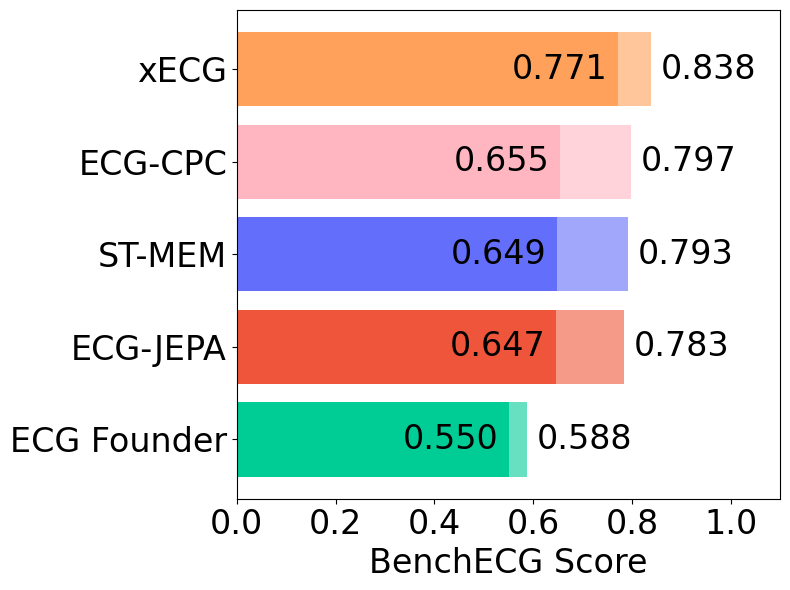

In [85]:
# plot combined bench score on index
from matplotlib import pyplot as plt

def plot_benchecg_score(df, title='bench_ecg_scores'):
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(df.index, df["raw_score_lp"], color=df["pastel_color"].str[:-2] + 'FF')
    bars = ax.barh(df.index, df["raw_score"], color=df["pastel_color"].str[:-2] + '99')

    # sns.set_style("white")
    # 
    # 
    # _context("poster")

    ax.set_yticklabels(df.index, fontsize=24)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)

    # Add labels to bars
    for i, (value, label) in enumerate(zip(df["raw_score"], df.index)):
        ax.text(value + 0.02, i, f"{value:.3f}", va='center', ha='left', fontsize=24, color='black')

    # Add labels to bars
    for i, (value, label) in enumerate(zip(df["raw_score_lp"], df.index)):
        if value:
            ax.text(value - 0.215, i, f"{value:.3f}", va='center', ha='left', fontsize=24, color='black')


    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])                  # positions of the ticks
    ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=24)

    ax.set_xlabel('BenchECG Score', fontsize=24)
    #ax.set_ylabel('Method', fontsize=12)
    # ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, 1.1])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig(f"figs/{title}.svg", dpi=300)

plot_benchecg_score(df_main)


In [ ]:
reference_metrics = ['test_auroc', 'test_auroc', 'test_f1/mean', 'test_auc', 'test_auroc', 'test_f1_20', 'test_f1_20', 'mean_r2', 'test_auroc_avg', 'test_ci']
record_list = [records_ptb_xl, records_cpsc, records_mit_cls, records_sleep_apnea, records_ppg, records_exe_r, records_mit_r_peaks, records_age, lab_test_records, mortality_test_records]
def get_dfs_list(group):
    dfs_full = []
    for i, records in enumerate(record_list):
        df = pd.DataFrame(records)
        if i == 7: 
            df = add_mean_age(df) # for age prediction add the mean rsmape
        # df = df.groupby("group").agg('mean')
        df = df[df['group'].isin(group)]
        df = df[['group', reference_metrics[i]]]
        df = df.rename(columns={reference_metrics[i]: 'reference_metric'})
        # make group index
        df = df.set_index('group')
        dfs_full.append(df)
    return dfs_full

full_runs_ft = get_dfs_list(ft_groups)
full_runs_lp = get_dfs_list(lp_groups)

In [87]:
import pandas as pd
from scipy.stats import ttest_ind
from pprint import pprint


def get_rank(df, metric, runs = [], mode='max', alpha=0.05):
    """
    Assigns ranks to groups based on their metric values with t-test based ties.

    Parameters
    ----------
    df : pd.DataFrame
        Multi-indexed dataframe where level 0 is group and rows are runs.
    metric : str
        Column name with the metric to compare.
    mode : str, 'max' or 'min'
        Whether higher or lower values are better.
    alpha : float
        Significance threshold for the t-test.

    Returns
    -------
    pd.DataFrame
        DataFrame with group, mean, and assigned rank (competition style).
    """

    if runs:
        df = df[df.index.isin(runs)]
        
    groups = df.index.unique()
    means = df.groupby(level=0)[metric].mean()

    # sort groups by mean
    if mode == 'max':
        means = means.sort_values(ascending=False)
    else:
        means = means.sort_values(ascending=True)

    # pairwise p-values
    pvals = pd.DataFrame(index=groups, columns=groups, dtype=float)
    for g1 in groups:
        for g2 in groups:
            if g1 == g2:
                pvals.loc[g1, g2] = 1.0
            else:
                s1 = df.loc[g1, metric]
                s2 = df.loc[g2, metric]
                _, p = ttest_ind(s1, s2, equal_var=False)
                pvals.loc[g1, g2] = p

    # assign ranks
    ranks = {}
    current_rank = 1
    i = 0
    sorted_groups = means.index.tolist()

    print()
    print(metric)
    pprint(pvals)
    # for g in groups:
    #     if g == best_group_name:
    #         bold.append(g)
    #         continue
        
    #     # Welch's t-test (equal_var=False)
    #     g_samples = df.loc[g, metric]
    #     try:
    #         _, p = ttest_ind(best_samples, g_samples, equal_var=False)
    #         if p > 0.05:
    #             bold.append(g)
    #     except Exception:
    #         # Fallback if sample size is too small or variance is 0
    #         continue

    while i < len(sorted_groups):
        g = sorted_groups[i]
        # group of equivalent methods (by t-test)
        group = [g]
        j = i + 1
        while j < len(sorted_groups):
            g2 = sorted_groups[j]
            if pvals.loc[g, g2] > alpha:
                group.append(g2)
                j += 1
            else:
                break
        for gg in group:
            ranks[gg] = current_rank
        current_rank += len(group)
        i = j

    result = pd.DataFrame({
        "group": means.index,
        "mean": means.values,
        "rank": [ranks[g] for g in means.index]
    })

    return result

In [88]:
full_runs_lp_ranked = [get_rank(task, 'reference_metric', runs=groups_main_lp) for task in full_runs_lp]


reference_metric
group           best_ecgfm_lp  best_jepa_lp  best_stmem_lp  best_xlstm_lp  \
group                                                                       
best_ecgfm_lp    1.000000e+00  1.464722e-11   6.399858e-14   1.391481e-05   
best_jepa_lp     1.464722e-11  1.000000e+00   5.667623e-14   4.485112e-09   
best_stmem_lp    6.399858e-14  5.667623e-14   1.000000e+00   4.972157e-11   
best_xlstm_lp    1.391481e-05  4.485112e-09   4.972157e-11   1.000000e+00   
best_ecgcpc_lp   1.029968e-10  1.787589e-09   8.426498e-12   8.279572e-09   

group           best_ecgcpc_lp  
group                           
best_ecgfm_lp     1.029968e-10  
best_jepa_lp      1.787589e-09  
best_stmem_lp     8.426498e-12  
best_xlstm_lp     8.279572e-09  
best_ecgcpc_lp    1.000000e+00  

reference_metric
group           best_ecgfm_lp  best_jepa_lp  best_stmem_lp  best_xlstm_lp  \
group                                                                       
best_ecgfm_lp    1.000000e+00  3.402700

In [89]:
full_runs_ft_ranked = [get_rank(task, 'reference_metric', runs=groups_main_ft) for task in full_runs_ft]
full_runs_lp_ranked = [get_rank(task, 'reference_metric', runs=groups_main_lp) for task in full_runs_lp]

full_runs_ft_ranked_abl = [get_rank(task, 'reference_metric', runs=groups_abl_ft) for task in full_runs_ft]
full_runs_lp_ranked_abl = [get_rank(task, 'reference_metric', runs=groups_abl_lp) for task in full_runs_lp]


print(full_runs_lp_ranked[0])
print()
print([e.loc[e.group == "best_xlstm_lp"] for e in full_runs_lp_ranked])
print()
print([e.loc[e.group == "best_jepa_lp"] for e in full_runs_lp_ranked])


reference_metric
group           best_ecgfm_ft  best_jepa_ft  best_stmem_ft  best_xlstm_ft  \
group                                                                       
best_ecgfm_ft    1.000000e+00  1.925735e-08       0.233606       0.000453   
best_jepa_ft     1.925735e-08  1.000000e+00       0.000021       0.000139   
best_stmem_ft    2.336055e-01  2.105743e-05       1.000000       0.001984   
best_xlstm_ft    4.530707e-04  1.387073e-04       0.001984       1.000000   
best_ecgcpc_ft   3.736505e-02  5.083122e-04       0.128915       0.135130   

group           best_ecgcpc_ft  
group                           
best_ecgfm_ft         0.037365  
best_jepa_ft          0.000508  
best_stmem_ft         0.128915  
best_xlstm_ft         0.135130  
best_ecgcpc_ft        1.000000  

reference_metric
group           best_ecgfm_ft  best_jepa_ft  best_stmem_ft  best_xlstm_ft  \
group                                                                       
best_ecgfm_ft    1.000000e+00  1.320236

In [90]:
# concatenate
full_runs_ft_ranked_cat = pd.concat(full_runs_ft_ranked).groupby('group').agg({'mean': 'mean', 'rank': 'mean'}).sort_values(by='rank')
full_runs_lp_ranked_cat = pd.concat(full_runs_lp_ranked).groupby('group').agg({'mean': 'mean', 'rank': 'mean'}).sort_values(by='rank')

full_runs_ft_ranked_abl_cat = pd.concat(full_runs_ft_ranked_abl).groupby('group').agg({'mean': 'mean', 'rank': 'mean'}).sort_values(by='rank')
full_runs_lp_ranked_abl_cat = pd.concat(full_runs_lp_ranked_abl).groupby('group').agg({'mean': 'mean', 'rank': 'mean'}).sort_values(by='rank')

# concatenate pastel colors
full_runs_ft_ranked_cat['pastel_color'] = full_runs_ft_ranked_cat.index.map(colors_idxs)
full_runs_lp_ranked_cat['pastel_color'] = full_runs_lp_ranked_cat.index.map(colors_idxs)

full_runs_ft_ranked_abl_cat['pastel_color'] = full_runs_ft_ranked_abl_cat.index.map(colors_idxs)
full_runs_lp_ranked_abl_cat['pastel_color'] = full_runs_lp_ranked_abl_cat.index.map(colors_idxs)

rename_map_rank = {
    'best_stmem_ft': 'ST-MEM',
    'best_jepa_ft': 'ECG-JEPA',
    'best_ecgfm_ft': 'ECG-Founder',
    'best_ecgcpc_ft': 'ECG-CPC',
    'best_xlstm_ft': 'xECG',
    'best_stmem_lp': 'ST-MEM',
    'best_jepa_lp': 'ECG-JEPA',
    'best_ecgfm_lp': 'ECG-Founder',
    'best_ecgcpc_lp': 'ECG-CPC',
    'best_xlstm_lp': 'xECG',
    'best_code15_xlstm_ft': 'xECG (red. pretr.)',
    'best_code15_xlstm_lp': 'xECG (red. pretr.)',
    'best_ecgdino_xlstm_ft': 'xECG (signal view)',
    'best_ecgdino_xlstm_lp': 'xECG (singal view)',
}

# map index to method
full_runs_ft_ranked_cat.index = full_runs_ft_ranked_cat.index.map(rename_map_rank)
full_runs_lp_ranked_cat.index = full_runs_lp_ranked_cat.index.map(rename_map_rank)

full_runs_lp_ranked_abl_cat.index = full_runs_lp_ranked_abl_cat.index.map(rename_map_rank)
full_runs_lp_ranked_abl_cat.index = full_runs_lp_ranked_abl_cat.index.map(rename_map_rank)



print(full_runs_ft_ranked_cat)
print(full_runs_lp_ranked_cat)

                 mean  rank pastel_color
group                                   
xECG         0.838017   1.5    #FFA15AC0
ST-MEM       0.792617   2.4    #636EFAC0
ECG-CPC      0.797260   3.2    #FFB6C1C0
ECG-Founder  0.588214   3.3    #00CC96C0
ECG-JEPA     0.783141   3.3    #EF553BC0
                 mean  rank pastel_color
group                                   
xECG         0.771461   1.1    #FFA15AC0
ECG-JEPA     0.647046   3.0    #EF553BC0
ECG-Founder  0.550463   3.3    #00CC96C0
ECG-CPC      0.655281   3.3    #FFB6C1C0
ST-MEM       0.648973   3.7    #636EFAC0


/tmp/ipykernel_34493/1931210178.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df_ranked_sorted.index, fontsize=24)
/tmp/ipykernel_34493/1931210178.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_34493/1931210178.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df_ranked_sorted.index, fontsize=24)
/tmp/ipykernel_34493/1931210178.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)


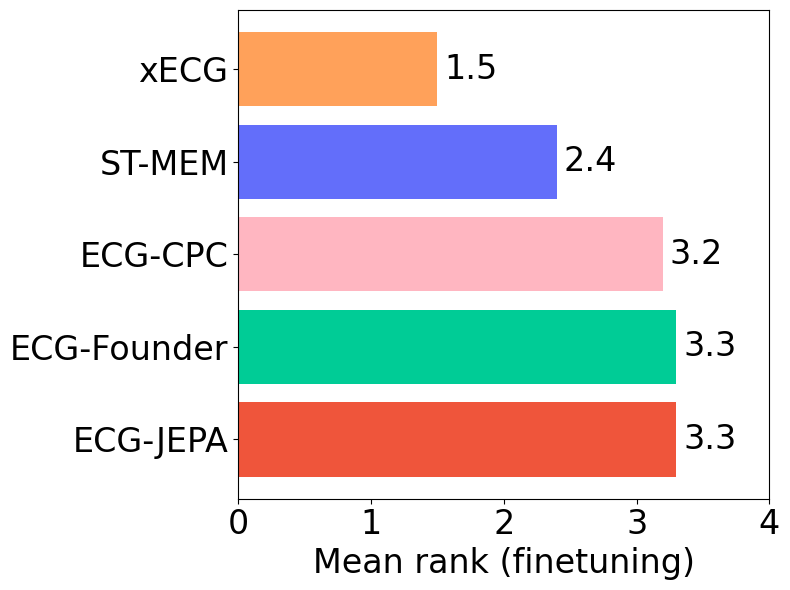

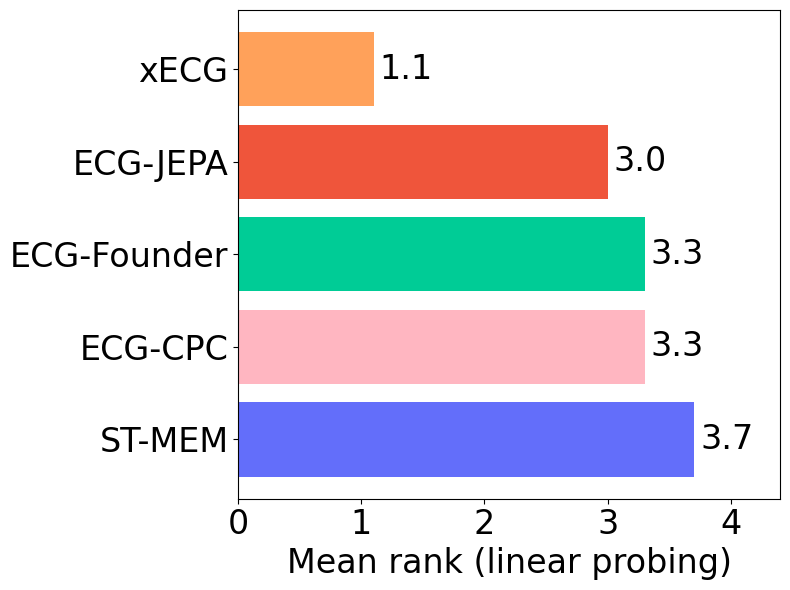

In [91]:
import matplotlib.pyplot as plt

def plot_bench_rank(df, name='mean_rank_methods.png', title=''):
    df_ranked_sorted = df.copy().drop(columns=["pastel_color"])
    df_ranked_sorted = df_ranked_sorted.sort_values(by="rank", ascending=True)

    df_ranked_sorted["pastel_color"] = df["pastel_color"]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw horizontal bars
    bars = ax.barh(df_ranked_sorted.index, df_ranked_sorted["rank"], color=df_ranked_sorted["pastel_color"].str[:-2] + 'FF')
    ax.set_yticklabels(df_ranked_sorted.index, fontsize=24)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)

    # Add labels to bars
    for i, (value, label) in enumerate(zip(df_ranked_sorted["rank"], df_ranked_sorted.index)):
        ax.text(value + 0.05, i, f"{value:.1f}", va='center', ha='left', fontsize=24, color='black')
    
    ax.set_xticks([0, 1, 2, 3, 4, 5])                  # positions of the ticks
    ax.set_xticklabels([0, 1, 2, 3, 4, 5], fontsize=24)

    # Format plo
    ax.set_xlabel(title, fontsize=24)
    #ax.set_ylabel('Method', fontsize=12)
    # ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, df_ranked_sorted["rank"].max() + 0.7])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig(name, dpi=300)

plot_bench_rank(full_runs_ft_ranked_cat, "figs/mean_rank_methods.svg", title='Mean rank (finetuning)')
plot_bench_rank(full_runs_lp_ranked_cat, "figs/mean_rank_methods_lp.svg", title='Mean rank (linear probing)')

In [92]:
dfs_bench_score_ft = []

def get_metric_by_task(task):
    if task == categories[0] or task == categories[1] or task == categories[4]: # ptbxl or cpsc ppg
        return 'test_auroc'
    if task == categories[2]: # mit-bih
        return 'test_f1/mean'
    if task == categories[3]: # sleep apnea
        return 'test_auc'
    if task == categories[5] or task == categories[6]: # exe and rpeak
        return 'test_f1_20'
    if task == categories[7]: # age
        return 'mean_r2'
    if task == categories[8]: # lab
        return 'test_auroc_avg'
    if task == categories[9]: # mortality
        return 'test_ci'

for i, records in enumerate([records_ptb_xl, records_cpsc, records_mit_cls, records_sleep_apnea, records_ppg, records_exe_r, records_mit_r_peaks, records_age, lab_test_records, mortality_test_records]):
    df = pd.DataFrame(records)
    if i == 7: df = add_mean_age(df) # for age prediction add the mean rsmape
    # df = df.groupby("group").agg('mean')
    df = df[df['group'].isin(ft_groups) | df['group'].isin(lp_groups)]
    df['task'] = categories[i]
    
    df['task_score'] = df[get_metric_by_task(categories[i])]
    dfs_bench_score_ft.append(df)



df_bench_score = pd.concat(dfs_bench_score_ft)
df_bench_score_ft = df_bench_score[df_bench_score['group'].isin(ft_groups)]
df_bench_score_lp = df_bench_score[df_bench_score['group'].isin(lp_groups)]

print(df_bench_score_ft[(df_bench_score_ft['group'] == 'best_xlstm_ft') & (df_bench_score_ft['task'] == 'Mortality')])


Empty DataFrame
Columns: [group, test_acc, test_f1, test_auroc, test_auprc, _runtime, task, task_score, test_sensitivity/mean, test_ppv/mean, test_specificity/mean, test_f1/mean, test_auc, test_f1_150, test_f1_20, test_avg_distance, test_avg_distance_rp, test_f1_10, test_f1_5, ptbxl/test_rsmape/dataloader_idx_0, ptbxl/test_mae/dataloader_idx_0, ptbxl/test_r2/dataloader_idx_0, ptbxl/test_pearson/dataloader_idx_0, mimic/test_rsmape/dataloader_idx_1, mimic/test_mae/dataloader_idx_1, mimic/test_r2/dataloader_idx_1, mimic/test_pearson/dataloader_idx_1, cpsc/test_rsmape/dataloader_idx_2, cpsc/test_mae/dataloader_idx_2, cpsc/test_r2/dataloader_idx_2, cpsc/test_pearson/dataloader_idx_2, valid_mae, valid_r2, valid_pearson, mean_rsmape, mean_mae, mean_r2, mean_rho, val_test_diff_mae, test_auroc_avg, test_f1_avg, test_acc_avg, test_loss, test_ci, val_ci]
Index: []

[0 rows x 45 columns]


Empty DataFrame
Columns: [task, task_score, group, pos]
Index: []
task      group        
Survival  best_trans_ft    4
dtype: int64
                                       group  mean_over_runs  std_over_runs
group                                                                      
best_xlstm_ft                  best_xlstm_ft        0.838017       0.003332
best_dinoecg_xlstm_ft  best_dinoecg_xlstm_ft        0.820097       0.004184
best_code15_xlstm_ft    best_code15_xlstm_ft        0.801639       0.002431
best_ecgcpc_ft                best_ecgcpc_ft        0.797260       0.004342
best_stmem_ft                  best_stmem_ft        0.792617       0.004896
best_jepa_ft                    best_jepa_ft        0.783141       0.002848
best_xlstm_sup                best_xlstm_sup        0.769037       0.002178
best_trans_ft                  best_trans_ft        0.726042       0.006697
best_ecgfm_ft                  best_ecgfm_ft        0.588214       0.007755
Empty DataFrame
Columns: [task, 

/tmp/ipykernel_34493/3138098757.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(summary.index, fontsize=20)
/tmp/ipykernel_34493/3138098757.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=20)
/tmp/ipykernel_34493/3138098757.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(summary.index, fontsize=20)
/tmp/ipykernel_34493/3138098757.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=20)


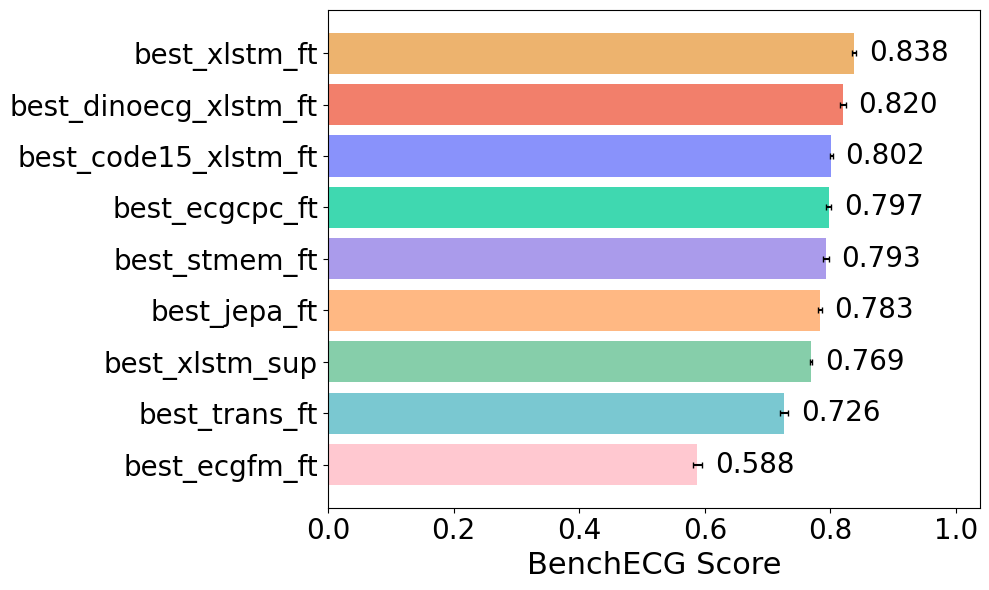

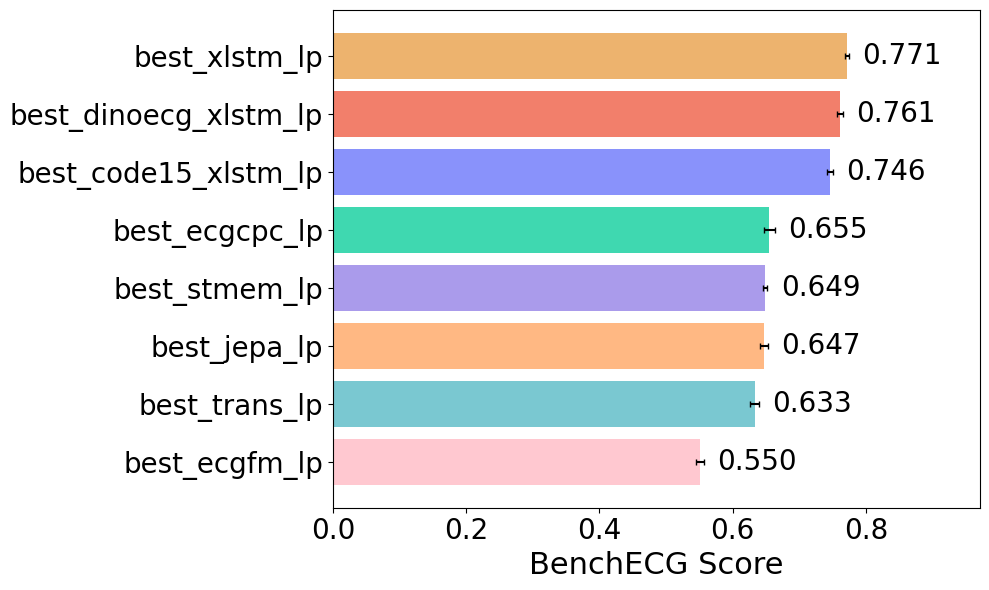

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from plotly.colors import qualitative
from matplotlib.ticker import MultipleLocator

def plot_bench_score(df, name='mean_score_methods.png'):
    df = df[['task', 'task_score', 'group']].copy()

    # Step 1: add run index inside each (task, group)
    df = df.sort_values(by=['group', 'task']) 
    df["pos"] = df.groupby(["task", "group"]).cumcount()

    print(df[df["pos"] >= 5])
    df = df[df["pos"] < 5]

    _5runs = df.groupby(["task", "group"]).size()
    print(_5runs[_5runs < 5])


    # Step 2: average across tasks, for each (group, pos)
    per_pos = (
        df.groupby(["group", "pos"])["task_score"]
        .mean()
        .reset_index()
    )

    # print(per_pos)

    # Step 3: now aggregate across positions -> mean of means, std of means
    summary = (
        per_pos.groupby("group")["task_score"]
        .agg(mean_over_runs="mean", std_over_runs="std")
        .reset_index()
    )

    # add the color column back for plotting
    summary["pastel_color"] = pastel_colors[:len(summary)]
    summary.index = summary['group']

    summary = summary.sort_values(by="mean_over_runs", ascending=False)

    print(summary[['group', 'mean_over_runs', 'std_over_runs']])



    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw horizontal bars
    bars = ax.barh(summary.index, summary["mean_over_runs"], color=summary["pastel_color"])
    # add std line
    ax.errorbar(summary["mean_over_runs"], summary.index, xerr=summary["std_over_runs"], fmt='none', c='black', capsize=2)

    ax.set_yticklabels(summary.index, fontsize=20)
    ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=20)

    # Add labels to bars
    for i, (value, std, label) in enumerate(zip(summary["mean_over_runs"], summary["std_over_runs"], summary.index)):
        ax.text(value + std + 0.02, i, f"{value:.3f}", va='center', ha='left', fontsize=20, color='black')

    # Format plot
    ax.set_xlabel('BenchECG Score', fontsize=22)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, summary["mean_over_runs"].max() + 0.2])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig(name, dpi=300)

plot_bench_score(df_bench_score_ft, name='figs/mean_score_methods.svg')
plot_bench_score(df_bench_score_lp, name='figs/mean_score_methods_lp.svg')

In [94]:
df = df_bench_score_ft[['task', 'task_score', 'group']].copy()
df_lp = df_bench_score_lp[['task', 'task_score', 'group']].copy()

# Step 1: add run index inside each (task, group)
df = df.sort_values(by=['group', 'task']) 
df["pos"] = df.groupby(["task", "group"]).cumcount()

df_lp = df_lp.sort_values(by=['group', 'task'])
df_lp["pos"] = df_lp.groupby(["task", "group"]).cumcount()


print(df[df["pos"] >= 5])
df = df[df["pos"] < 5]
print(df_lp[df_lp["pos"] >= 5])
df_lp = df_lp[df_lp["pos"] < 5]

# Step 2: average across tasks, for each (group, pos)
per_pos = (
    df.groupby(["group", "pos"])["task_score"]
    .mean()
    .reset_index()
)
per_pos_lp = (
    df_lp.groupby(["group", "pos"])["task_score"]
    .mean()
    .reset_index()
)

Empty DataFrame
Columns: [task, task_score, group, pos]
Index: []
Empty DataFrame
Columns: [task, task_score, group, pos]
Index: []


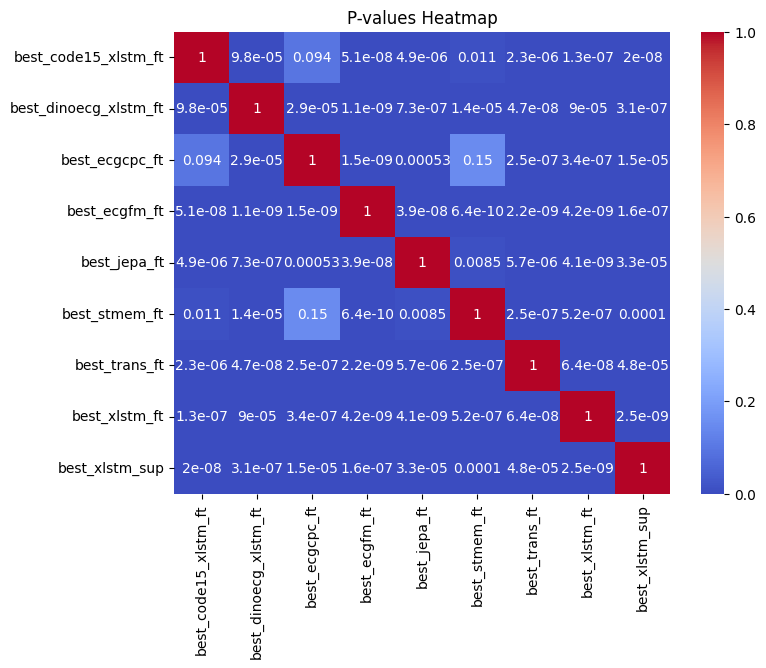

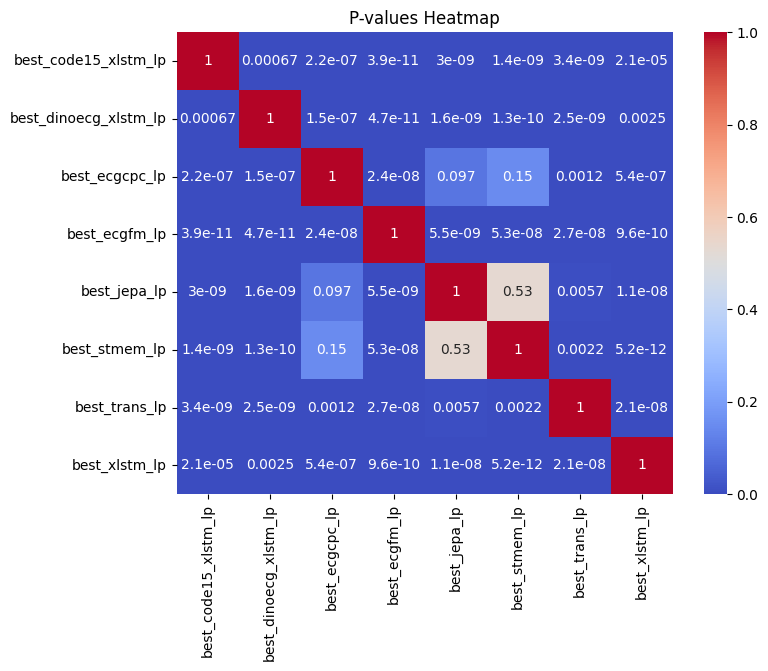

In [95]:
# plot p-values heatmap for each task
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pval_heatmap(df, name='pval_heatmap.png'):
    groups = df['group'].unique()
    pvals = pd.DataFrame(index=groups, columns=groups, dtype=float)

    for g1 in groups:
        for g2 in groups:
            if g1 == g2:
                pvals.loc[g1, g2] = 1.0
            else:
                s1 = df[df['group'] == g1]['task_score']
                s2 = df[df['group'] == g2]['task_score']
                _, p = ttest_ind(s1, s2, equal_var=False)
                pvals.loc[g1, g2] = p

    plt.figure(figsize=(8, 6))
    sns.heatmap(pvals.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
    plt.title(f'P-values Heatmap')
    # plt.savefig(name, dpi=300)
    plt.show()

plot_pval_heatmap(per_pos)
plot_pval_heatmap(per_pos_lp)

In [110]:
def save_records(records, groups, filename=''):
    df = pd.DataFrame(records)
    df = df[df.group.isin(groups)]
    df = df.sort_values('group')
    df.to_csv(f'../results/{filename}.csv')
    return df

save_records(records_ptb_xl, groups = ft_groups + lp_groups, filename='ptb_xl')
save_records(records_cpsc, groups = ft_groups + lp_groups, filename='cpsc2018')
save_records(records_mit_cls, groups = ft_groups + lp_groups, filename='mit_cls')
save_records(records_sleep_apnea, groups = ft_groups + lp_groups, filename='sleep_apnea')
save_records(records_exe_r, groups = ft_groups + lp_groups, filename='exercise')
save_records(records_mit_r_peaks, groups = ft_groups + lp_groups, filename='mit_rpeaks')
save_records(records_age, groups = ft_groups + lp_groups, filename='age')
save_records(lab_test_records, groups = ft_groups + lp_groups, filename='lab_mimic')
save_records(mortality_test_records, groups = ft_groups + lp_groups, filename='survival')


,group,test_loss,test_ci,_runtime,val_ci
51,best_code15_xlstm_ft,1.742664,0.692959,2024.705156,0.818948
53,best_code15_xlstm_ft,1.745841,0.696428,2454.531917,0.814085
54,best_code15_xlstm_ft,1.742979,0.691830,2351.658670,0.816148
46,best_code15_xlstm_ft,1.741701,0.694583,1959.632720,0.823047
52,best_code15_xlstm_ft,1.742062,0.694110,1829.059527,0.824533
...,...,...,...,...,...
32,best_xlstm_sup,1.799154,0.643087,1843.023328,0.646617
33,best_xlstm_sup,1.816759,0.605075,1597.610895,0.642612
34,best_xlstm_sup,1.804023,0.620320,1595.537894,0.628318
75,best_xlstm_sup,1.774245,0.634446,1101.428614,0.665340


In [ ]:


dfs = []
for i, records in enumerate([records_ptb_xl, records_cpsc, records_mit_cls, records_sleep_apnea, records_ppg, records_exe_r, records_mit_r_peaks, records_age, lab_test_records, mortality_test_records]):
    df = pd.DataFrame(records)
    if i == 7: df = add_mean_age(df) # for age prediction add the mean rsmape
    df = df.groupby("group").agg('mean')
    df = df[df.index.isin(ft_groups) | df.index.isin(lp_groups)]
    dfs.append(df)


categories = ['PTB-XL', 'CPSC2018', 'MIT-BIH', 'Sleep Apnea', 'PPG AF', r'Exercise<br>R-Peak', 'R-peak', 'Age', 'Blood Test', 'Survival']
categories_metric = ['PTB-XL / AUC', 'CPSC2018 / AUC', 'MIT-BIH / F1', 'Sleep Apnea / AUC', 'PPG / AUC', 'Exercise R-Peak / F1', 'R-Peaks / F1', 'Age / R^2', 'LAB test / AUC', 'Mortality / CI']

methods_main = ['xECG', 'ECG-CPC', 'ST-MEM', 'ECG-JEPA', 'ECG Founder']
groups_main_lp = ['best_xlstm_lp', 'best_ecgcpc_lp', 'best_stmem_lp', 'best_jepa_lp', 'best_ecgfm_lp' ]
groups_main_ft = ['best_xlstm_ft','best_ecgcpc_ft', 'best_stmem_ft', 'best_jepa_ft', 'best_ecgfm_ft' ]

methods_ablations = ['xECG', 'xECG (signal view)', 'xECG (reduced pretraining)', 'SimDINOv2 Transformer', 'Supervised xLSTM']
groups_abl_lp = ['best_xlstm_lp',  'best_dinoecg_xlstm_lp', 'best_code15_xlstm_lp', 'best_trans_lp']
groups_abl_ft = ['best_xlstm_ft', 'best_dinoecg_xlstm_ft', 'best_code15_xlstm_ft', 'best_trans_ft',  'best_xlstm_sup']

reindex_ft = [4, 3, 0, 1, 2]

def get_full_results(dfs, groups, methods):
    data = {
        'PTB-XL / AUC': [  dfs[0].loc[f'{group}']['test_auroc'] for group in groups],
        'CPSC2018 / AUC': [ dfs[1].loc[f'{group}']['test_auroc'] for group in groups],
        'MIT-BIH / F1': [ dfs[2].loc[f'{group}']['test_f1/mean'] for group in groups], 
        'Sleep Apnea / AUC': [ dfs[3].loc[f'{group}']['test_auc'] for group in groups ],
        'PPG / AUC': [  dfs[4].loc[f'{group}']['test_auroc'] for group in groups],
        'Exercise R-Peak / F1': [  dfs[5].loc[f'{group}']['test_f1_20'] for group in groups],
        'R-Peaks / F1': [  dfs[6].loc[f'{group}']['test_f1_20'] for group in groups],
        'Age / R^2': [  dfs[7].loc[f'{group}']['mean_r2'] for group in groups],   
        'LAB test / AUC': [  dfs[8].loc[f'{group}']['test_auroc_avg'] for group in groups],
        'Mortality / CI': [ dfs[9].loc[f'{group}']['test_ci'] for group in groups],
    }
    df = pd.DataFrame(data)
    # name index as method and reorder it according to methods
    df.index = methods
    df = df.reindex(methods)
    return df
        
df_main_ft = get_full_results(dfs, groups_main_ft, methods_main)
df_main_ft.to_csv("../results/scores_finetuning.csv")
df_main_ft.head(n=10)


,group,test_acc,test_f1,test_auroc,test_auprc,_runtime
0,best_ecgfm_ft,0.891265,0.735110,0.930292,0.822745,798.589181
1,best_ecgfm_lp,0.882712,0.699584,0.917287,0.798030,370.733926
2,best_ecgfm_lp_10,0.868426,0.621271,0.890274,0.749364,180.630623
3,best_ecgfm_lp_1,0.854868,0.637052,0.873554,0.702016,179.620647
4,best_jepa_lp_10,0.792266,0.640878,0.878362,0.713792,508.180456
...,...,...,...,...,...,...
134,best_agegender_xlstm_lp,0.880255,0.707580,0.919023,0.801316,420.000000
135,best_agegender_xlstm_lp,0.879800,0.704122,0.918534,0.799094,419.000000
136,best_agegender_xlstm_lp,0.878981,0.697581,0.918612,0.799151,289.000000
137,best_agegender_xlstm_lp,0.876979,0.693345,0.915348,0.791468,290.000000
